In [1]:
from IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import codedmask

import darksun as ds


#SAVEFIG_PATH = "/home/edoardo/Desktop/mask_summer_2021_infdet"
SAVEFIG_PATH = "/home/edoardo/Desktop/mask_NTHT_infdet"
FRMT = "png"

def savefig(figname: str) -> str:
    """Defines dirpath location to save a Figure."""
    return f'{SAVEFIG_PATH}/{figname}.{FRMT}'

def is_img(name: str) -> str | None:
    """Checks if a Figure has been already saved."""
    filepath: str = savefig(name)
    if Path(filepath).is_file():
        return None
    return filepath

In [2]:
skyfield = "GalacticCenter"

#mask_FITS = "wfm_mask_summer2021.fits"
#data_FITS = "galctr_rxte-sax_mask_summer2021_infdet_2-50keV_1ks"

mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

#skyfield = "IROSDummy"
#data_FITS = "catalog_withCXB_1Crab_infdet_2-50keV_1ks"

N_TEST = "testing"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
sdlB = ds.get_data(filepaths[cam_b][dataset])
catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


In [3]:
pd.DataFrame(
    {
        log_camA.name: log_camA.log['ID'],
        f"{log_camA.name} SNR": log_camA.log['snr'],
        log_camB.name: log_camB.log['ID'],
        f"{log_camB.name} SNR": log_camB.log['snr'],
        "Same Source": np.array(log_camA.log['ID']) == np.array(log_camB.log['ID']),
    }
)

,CAM1A,CAM1A SNR,CAM1B,CAM1B SNR,Same Source
0,scox1,749.152433,scox1,565.983350,True
1,gx5-1,77.078738,gx5-1,83.246663,True
2,gx349+2,60.073518,gx349+2,57.463985,True
3,gx17+2,51.405976,gx17+2,52.442591,True
4,gx9+1,42.160327,gx9+1,39.627443,True
5,gx340+0,34.460475,gx340+0,34.159797,True
6,gx13+1,26.216588,gx13+1,27.271012,True
7,groj1655-40,21.718901,groj1655-40,22.762414,True
8,gx3+1,25.354110,gx3+1,25.691279,True
9,x1820-303,24.151237,x1820-303,24.851519,True


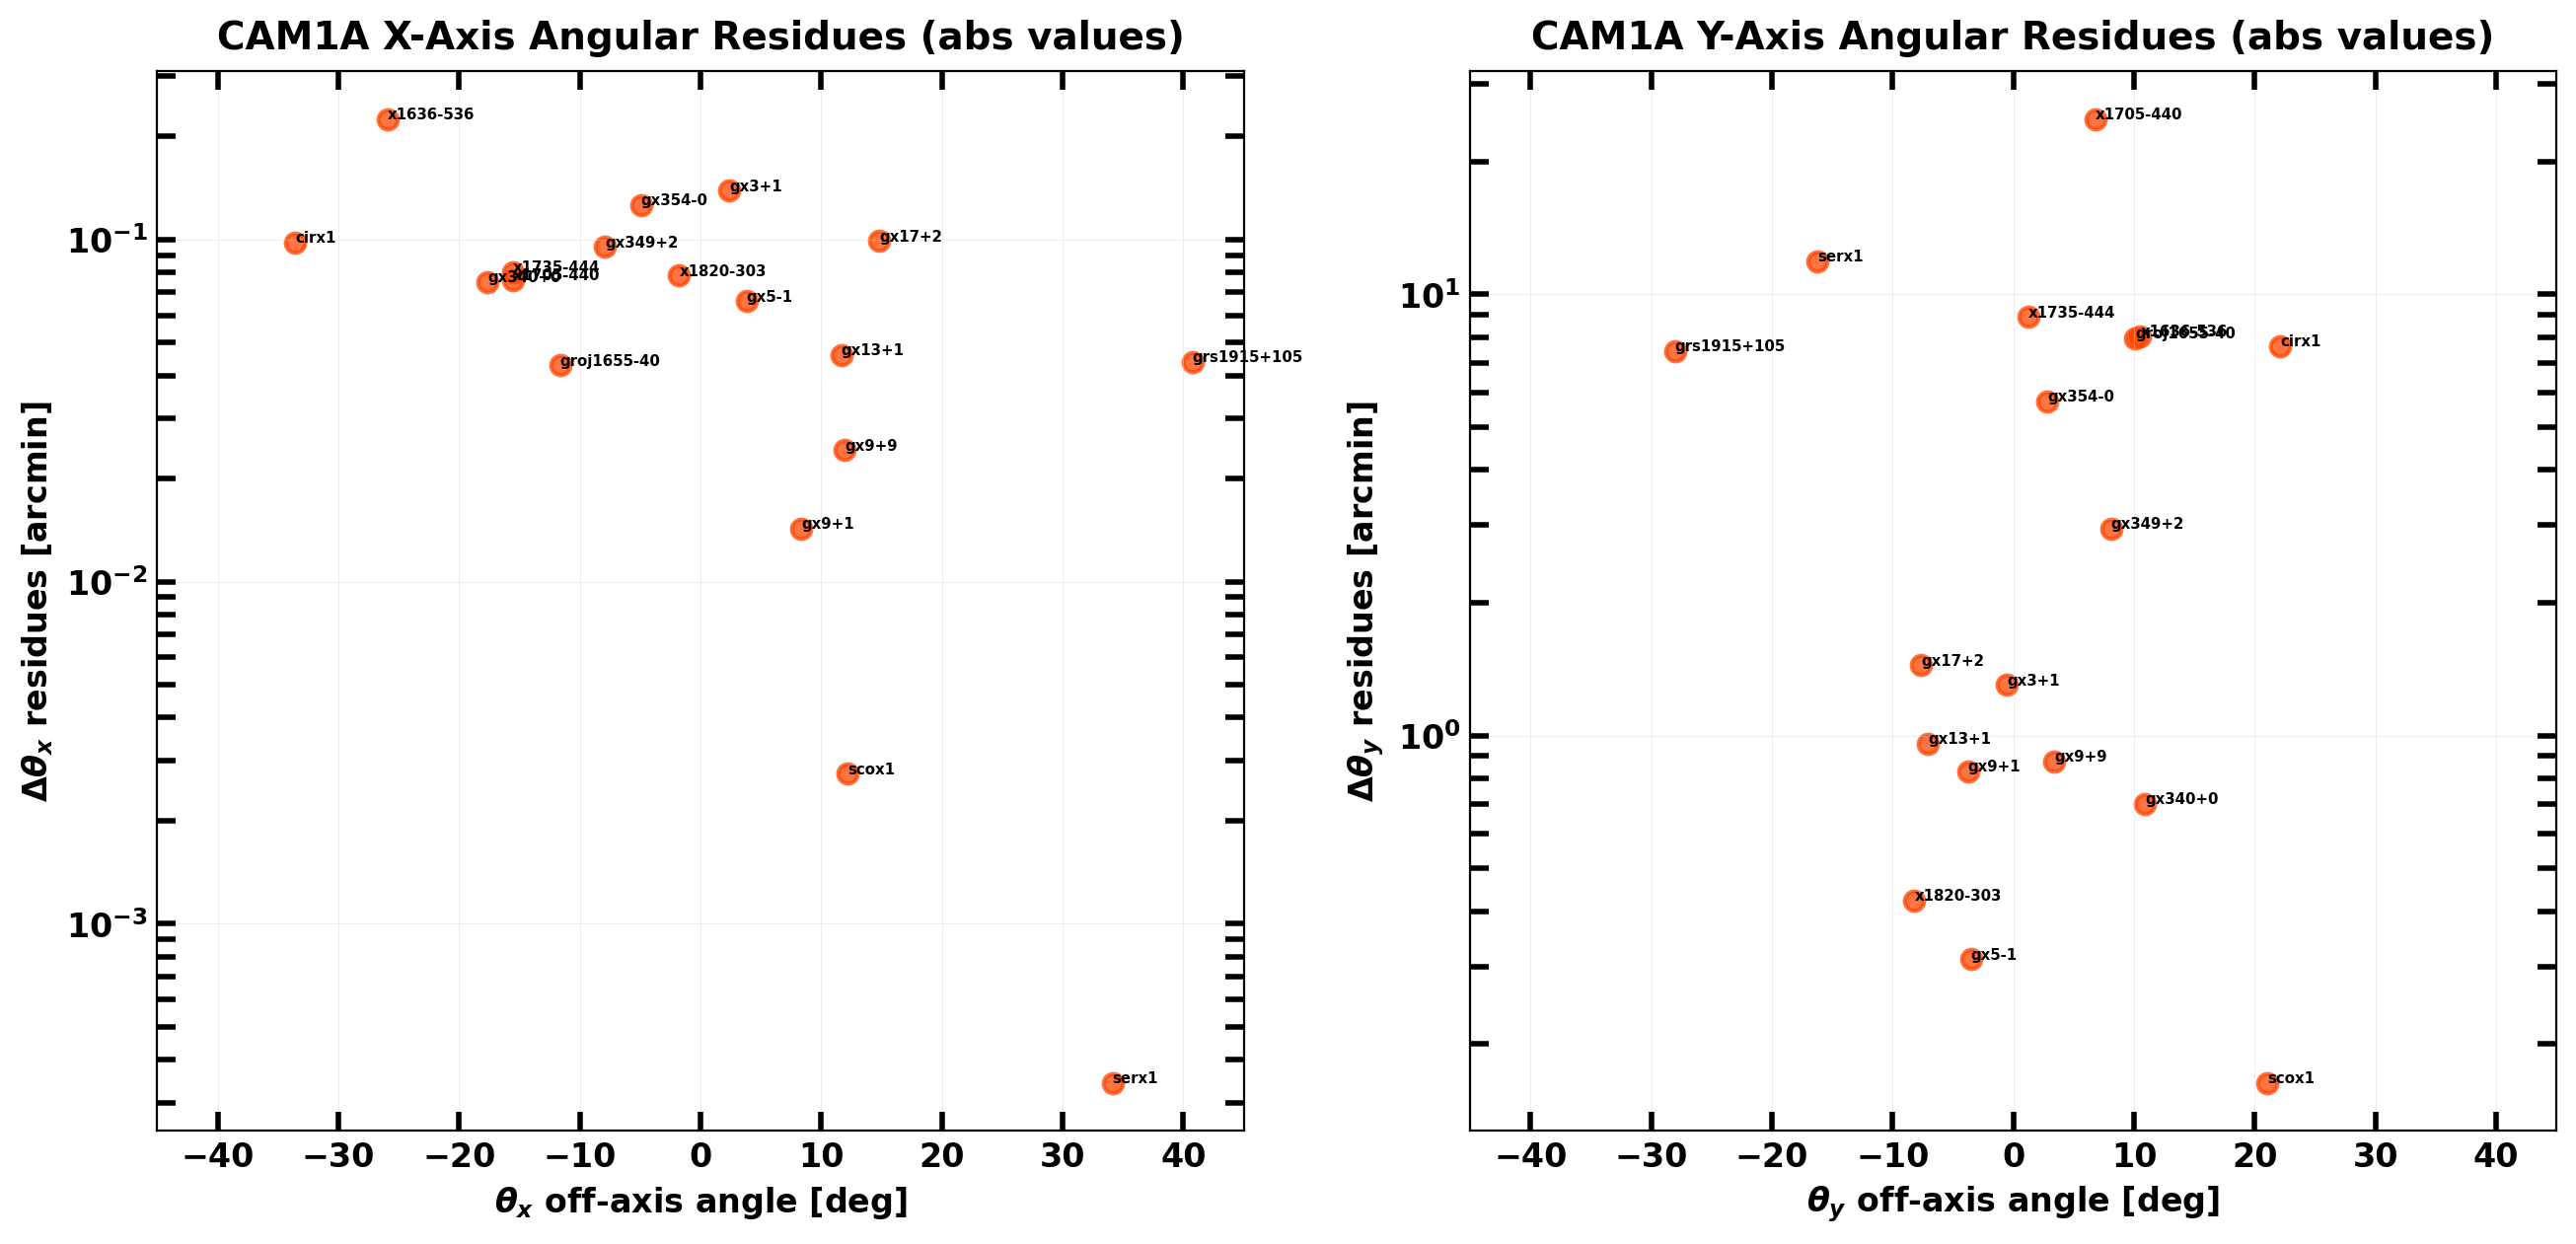

In [4]:
from typing import NamedTuple

from bloodmoon.mask import CodedMaskCamera
from bloodmoon.types import CoordEquatorial
from bloodmoon.coords import equatorial2shift, shift2angle

from darksun.types import Tag
from darksun.data import Log, DataLoader, CatalogueLoader

class CoordAngular(NamedTuple):
    """
    Local frame coded-mask camera angular coordinates.

    Args:
        theta_x (float): Angular coord along x-axis [deg]
        theta_y (float): Angular coord along y-axis [deg]
    """
    theta_x: float
    theta_y: float

def extract_catalogue_equatorial_coords(
    log: Log,
    catalogue: CatalogueLoader,
) -> tuple[tuple[str, CoordEquatorial]]:
    """
    """
    sources, ras, decs = [], [], []
    for s_id in log.log['ID']:
        if s_id in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == s_id)]
            sources.append(s_id)
            ras.append(source['RA'])
            decs.append(source['DEC'])
        else:
            print(f'Source {s_id.upper()} not in catalogue...')
            sources.append(s_id)
            ras.append(-999)
            decs.append(-999)
    return tuple(
        (name, CoordEquatorial(ra, dec)) for name, ra, dec in zip(sources, ras, decs)
    )

def extract_catalogue_angular_coords(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[tuple[str, CoordAngular]]:
    """
    """
    sources, thetas_x, thetas_y = [], [], []
    for s_id in log.log['ID']:
        if s_id in catalogue.DLdata['ID']:
            source = catalogue.DLdata[(catalogue.DLdata['ID'] == s_id)]
            sources.append(s_id)
            sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
            thetas_x.append(shift2angle(camera, sx))
            thetas_y.append(shift2angle(camera, sy))
        else:
            print(f'Source {s_id.upper()} not in catalogue...')
            sources.append(s_id)
            thetas_x.append(-999)
            thetas_y.append(-999)
    return tuple(
        (name, CoordAngular(tx, ty)) for name, tx, ty in zip(sources, thetas_x, thetas_y)
    )


_, cat_theta = zip(
    *extract_catalogue_angular_coords(log=log_camA, catalogue=catalogueA, sdl=sdlA, camera=wfm)
)
cat_thetax, cat_thetay = zip(*cat_theta)

tagsx = tuple(
    Tag(n, r, t) for n, r, t in zip(
        log_camA.log['ID'], 60 * np.abs(np.array(log_camA.log['angle_x']) - np.array(cat_thetax)), cat_thetax,
    )
)
dmapx = ds.map4biplot(
    arrs=60 * np.abs(np.array(log_camA.log['angle_x']) - np.array(cat_thetax)),
    title=f'{log_camA.name} X-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{x}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{x}}$ residues [arcmin]',
    x=np.array(cat_thetax),
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tagsx,
)
tagsy = tuple(
    Tag(n, r, t) for n, r, t in zip(
        log_camA.log['ID'], 60 * np.abs(np.array(log_camA.log['angle_y']) - np.array(cat_thetay)), cat_thetay,
    )
)
dmapy = ds.map4biplot(
    arrs=60 * np.abs(np.array(log_camA.log['angle_y']) - np.array(cat_thetay)),
    title=f'{log_camA.name} Y-Axis Angular Residues (abs values)',
    xlabel='$\\theta_{{y}}$ off-axis angle [deg]',
    ylabel='$\\Delta\\theta_{{y}}$ residues [arcmin]',
    x=np.array(cat_thetay),
    style='scatter',
    color='OrangeRed',
    xlim=(-45, 45),
    yscale='log',
    tags=tagsy,
)
ds.biplot(dmapx, dmapy, is_img('theta_res'))

In [5]:
from typing import Any
from numpy.typing import NDArray
from pandas import DataFrame

def dict2df(data: dict[str, dict[str, Any]]) -> DataFrame:
    """
    Converts input data in a Pandas dataframe.

    Args:
        data (dict): Input data.
    
    Returns:
        output (DataFrame): Output dataframe.
    """
    df = DataFrame({
        (cam, param): values
        for cam, cam_data in data.items() 
        for param, values in cam_data.items()
    })
    return df


def get_angularcoords_residues(
    log: Log,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> tuple[NDArray, NDArray]:
    """
    """
    _, cat_theta = zip(
        *extract_catalogue_angular_coords(log=log, catalogue=catalogue, sdl=sdl, camera=camera)
    )
    cat_thetax, cat_thetay = zip(*cat_theta)
    resx = 60 * np.abs(np.array(log.log['angle_x']) - np.array(cat_thetax))
    resy = 60 * np.abs(np.array(log.log['angle_y']) - np.array(cat_thetay))
    return resx, resy

resxA, resyA = get_angularcoords_residues(log=log_camA, catalogue=catalogueA, sdl=sdlA, camera=wfm)
resxB, resyB = get_angularcoords_residues(log=log_camB, catalogue=catalogueB, sdl=sdlB, camera=wfm)

dmap = {
    log_camA.name: {
        'ID': log_camA.log['ID'],
        'SNR': log_camA.log['snr'],
        'DthetaX [arcmin]': resxA,
        'DthetaY [arcmin]': resyA,
    },
    log_camB.name: {
        'ID': log_camB.log['ID'],
        'SNR': log_camB.log['snr'],
        'DthetaX [arcmin]': resxB,
        'DthetaY [arcmin]': resyB,
    },
    "Same Source": {
        'Check': np.array(log_camA.log['ID']) == np.array(log_camB.log['ID']),
    },
}

dict2df(dmap)

CAM1A                                                      CAM1B  \
             ID         SNR DthetaX [arcmin] DthetaY [arcmin]           ID   
0         scox1  749.152433         0.002744         0.163509        scox1   
1         gx5-1   77.078738         0.066082         0.311430        gx5-1   
2       gx349+2   60.073518         0.095211         2.949510      gx349+2   
3        gx17+2   51.405976         0.099070         1.444516       gx17+2   
4         gx9+1   42.160327         0.014285         0.830454        gx9+1   
5       gx340+0   34.460475         0.075157         0.700358      gx340+0   
6        gx13+1   26.216588         0.045963         0.960187       gx13+1   
7   groj1655-40   21.718901         0.042847         7.954401  groj1655-40   
8         gx3+1   25.354110         0.138712         1.303131        gx3+1   
9     x1820-303   24.151237         0.078448         0.422850    x1820-303   
10        gx9+9   23.242839         0.024212         0.873846        gx9+9   
11        cirx1   28.255730         0.097921         7.628400        cirx1   
12    x1705-440   15.817441         0.076055        24.972303    x1705-440   
13    x1735-444   13.674555         0.080159         8.881801    x1735-444   
14      gx354-0    7.914503         0.125894         5.724205      gx354-0   
15  grs1915+105   17.350415         0.043818         7.442089  grs1915+105   
16    x1636-536    7.536065         0.224942         8.030969    x1636-536   
17        serx1    7.316130         0.000343        11.888819        serx1   

                                                 Same Source  
           SNR DthetaX [arcmin] DthetaY [arcmin]       Check  
0   565.983350         0.004379         0.034327        True  
1    83.246663         0.070784         1.588430        True  
2    57.463985         0.032499         3.871042        True  
3    52.442591         0.107039         1.398757        True  
4    39.627443         0.044641         0.238942        True  
5    34.159797         0.070941         4.402602        True  
6    27.271012         0.200775         0.014057        True  
7    22.762414         0.303974         2.001615        True  
8    25.691279         0.090580        10.658936        True  
9    24.851519         0.001515         0.149853        True  
10   20.047986         0.037696         0.228175        True  
11   27.301582         0.058214         0.164690        True  
12   15.501846         0.082371         8.105167        True  
13   12.887717         0.207254         7.665750        True  
14    6.191127         0.513707        18.788322        True  
15   14.395916         0.031886         3.125991        True  
16    5.153759         0.216590         6.222714        True  
17    7.299518         0.107531        10.434358        True

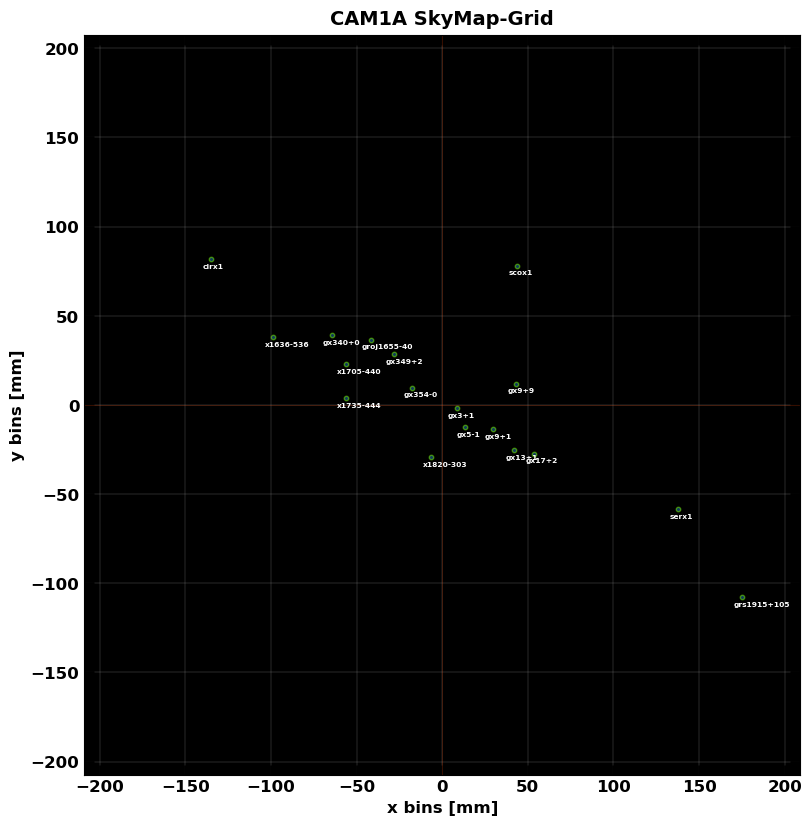

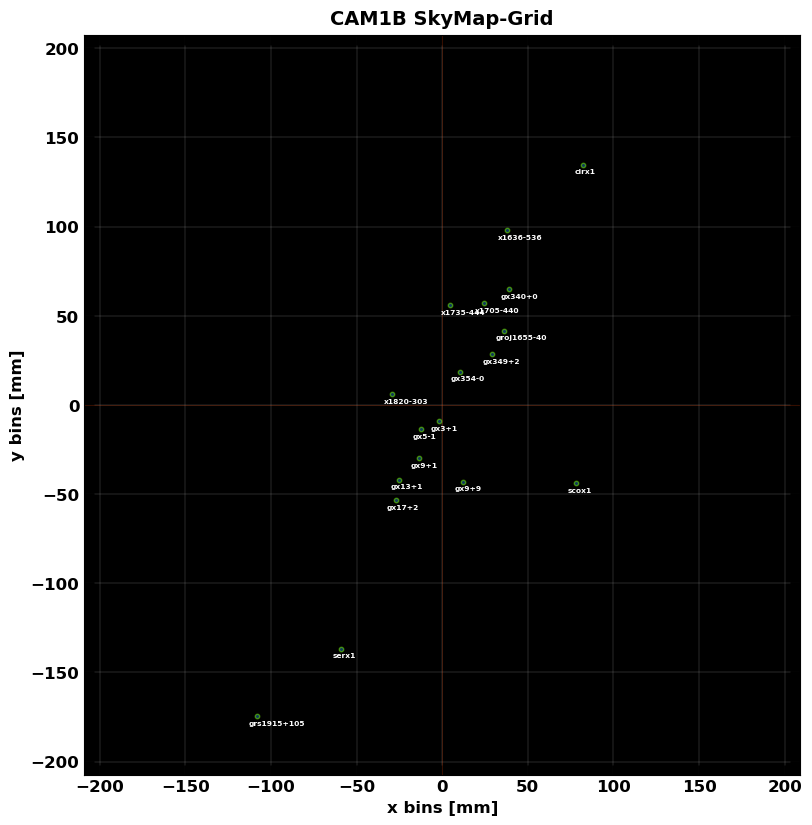

In [6]:
ds.skyfield_map(log_camA, wfm, save_to=is_img(f'skymap_grid_{log_camA.name}'))
ds.skyfield_map(log_camB, wfm, save_to=is_img(f'skymap_grid_{log_camB.name}'))

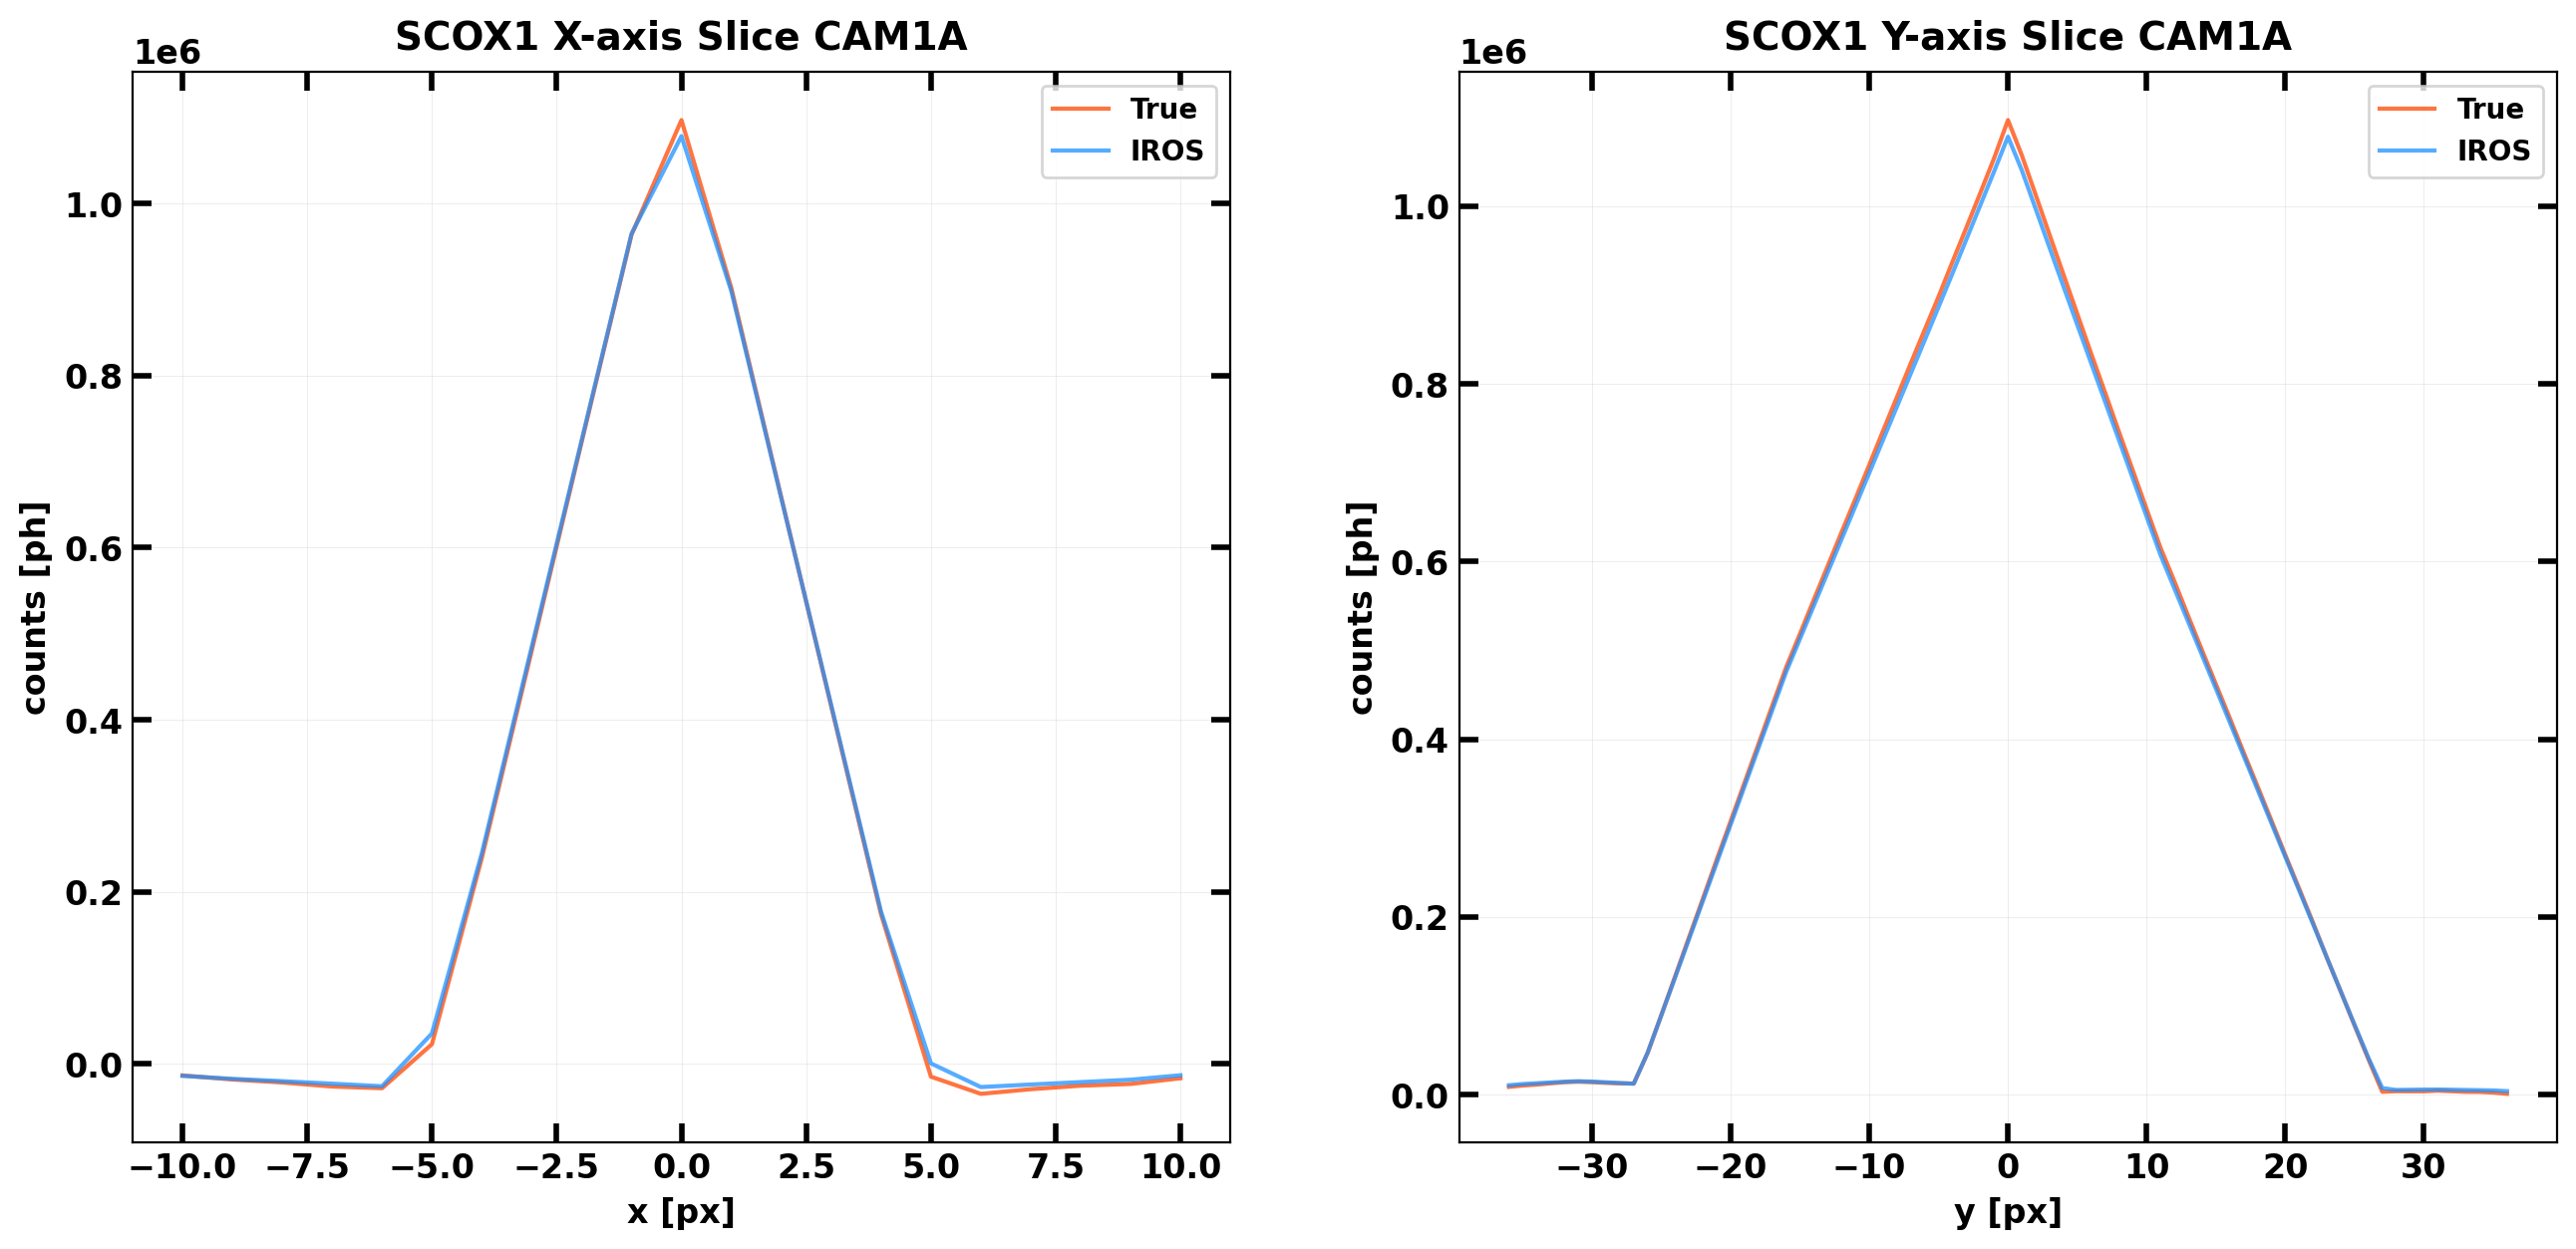

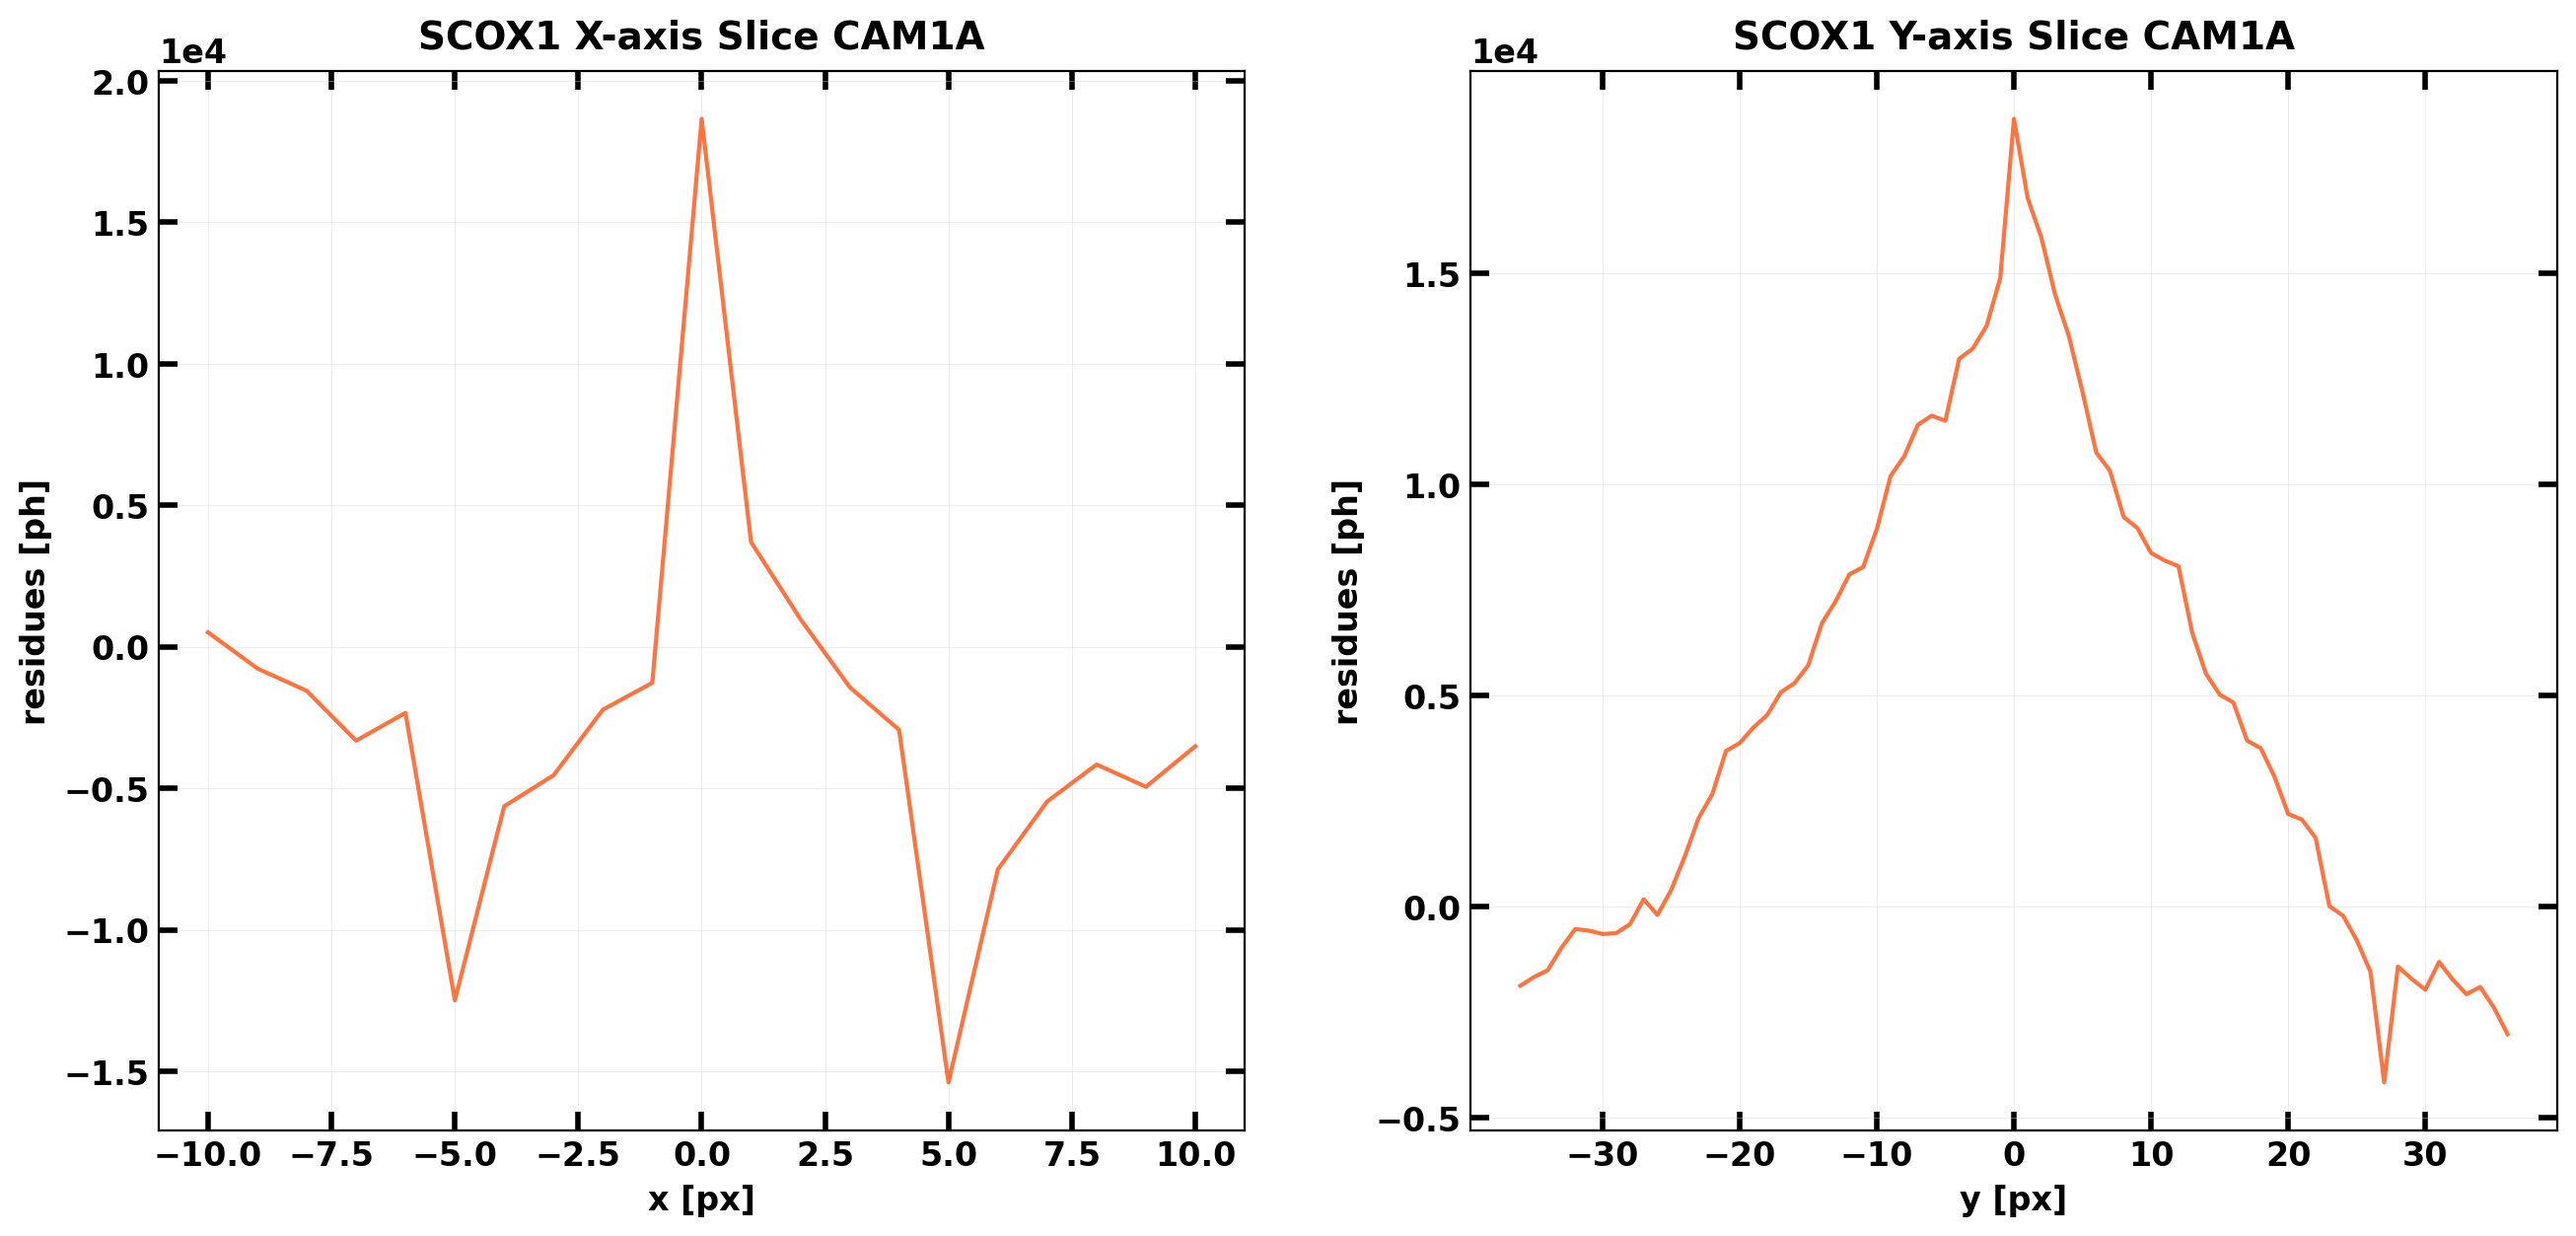

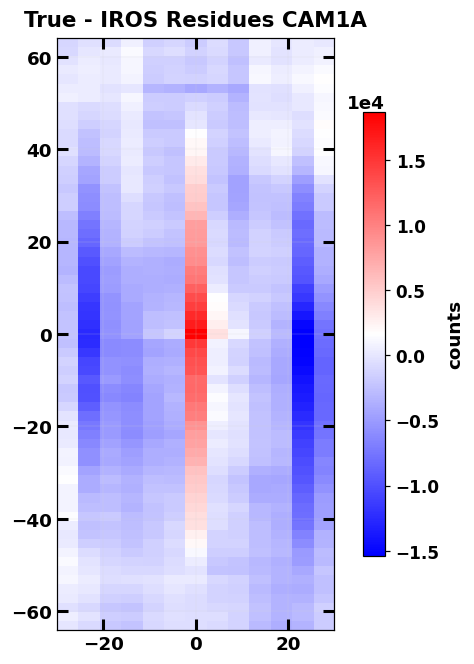

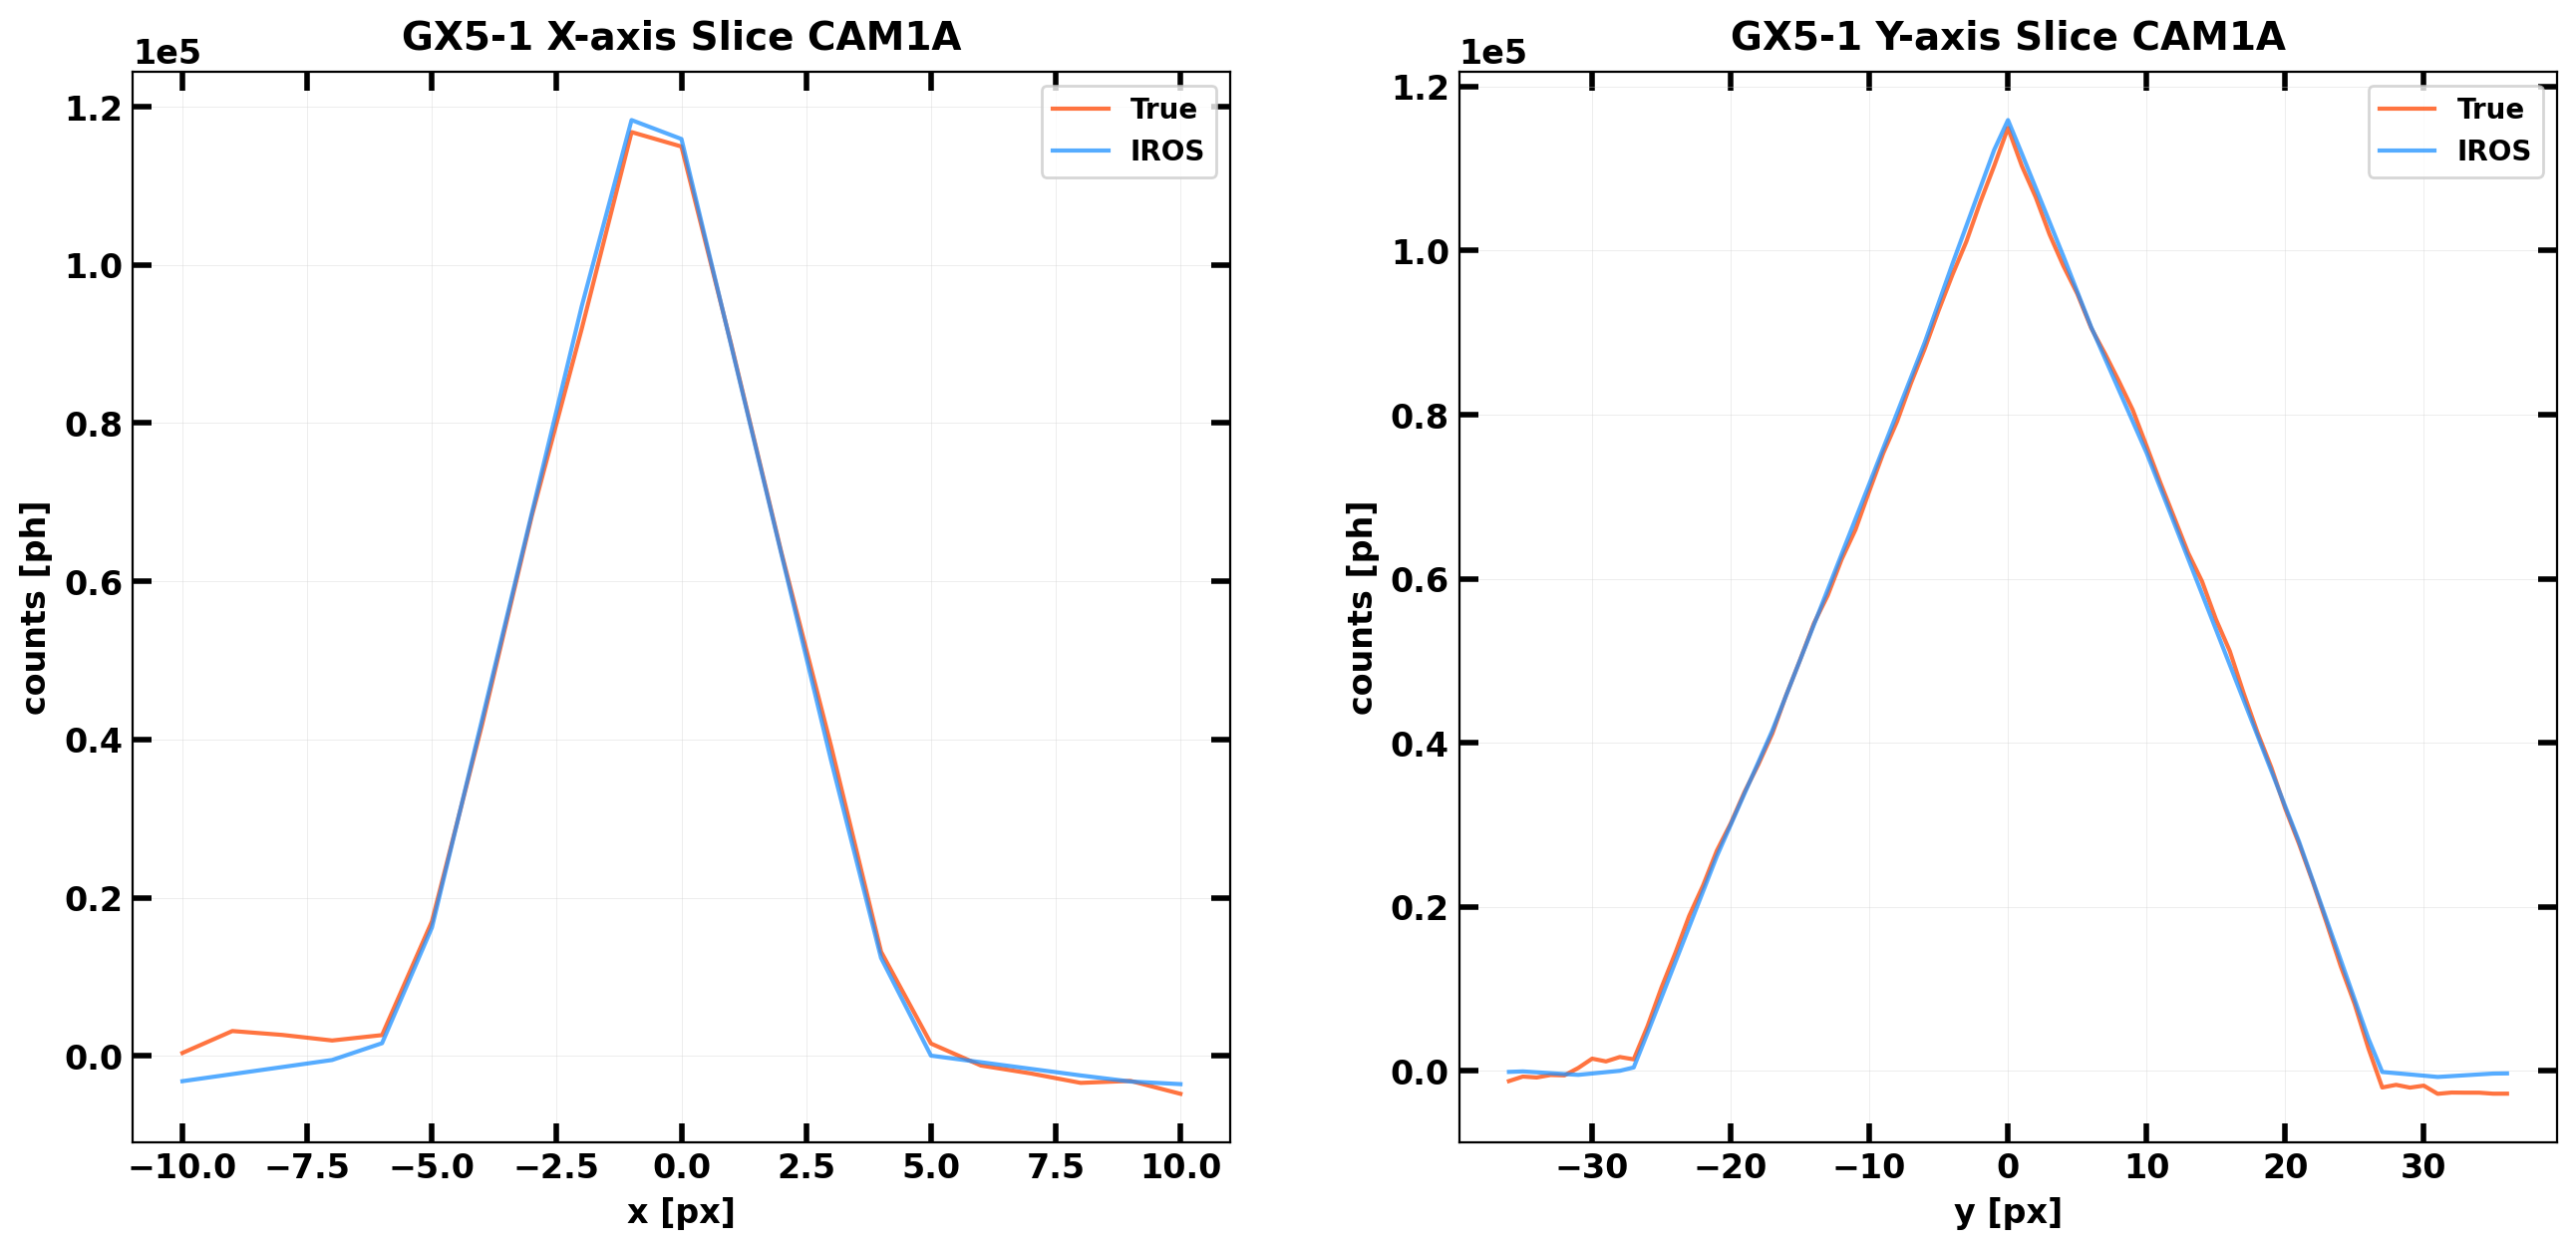

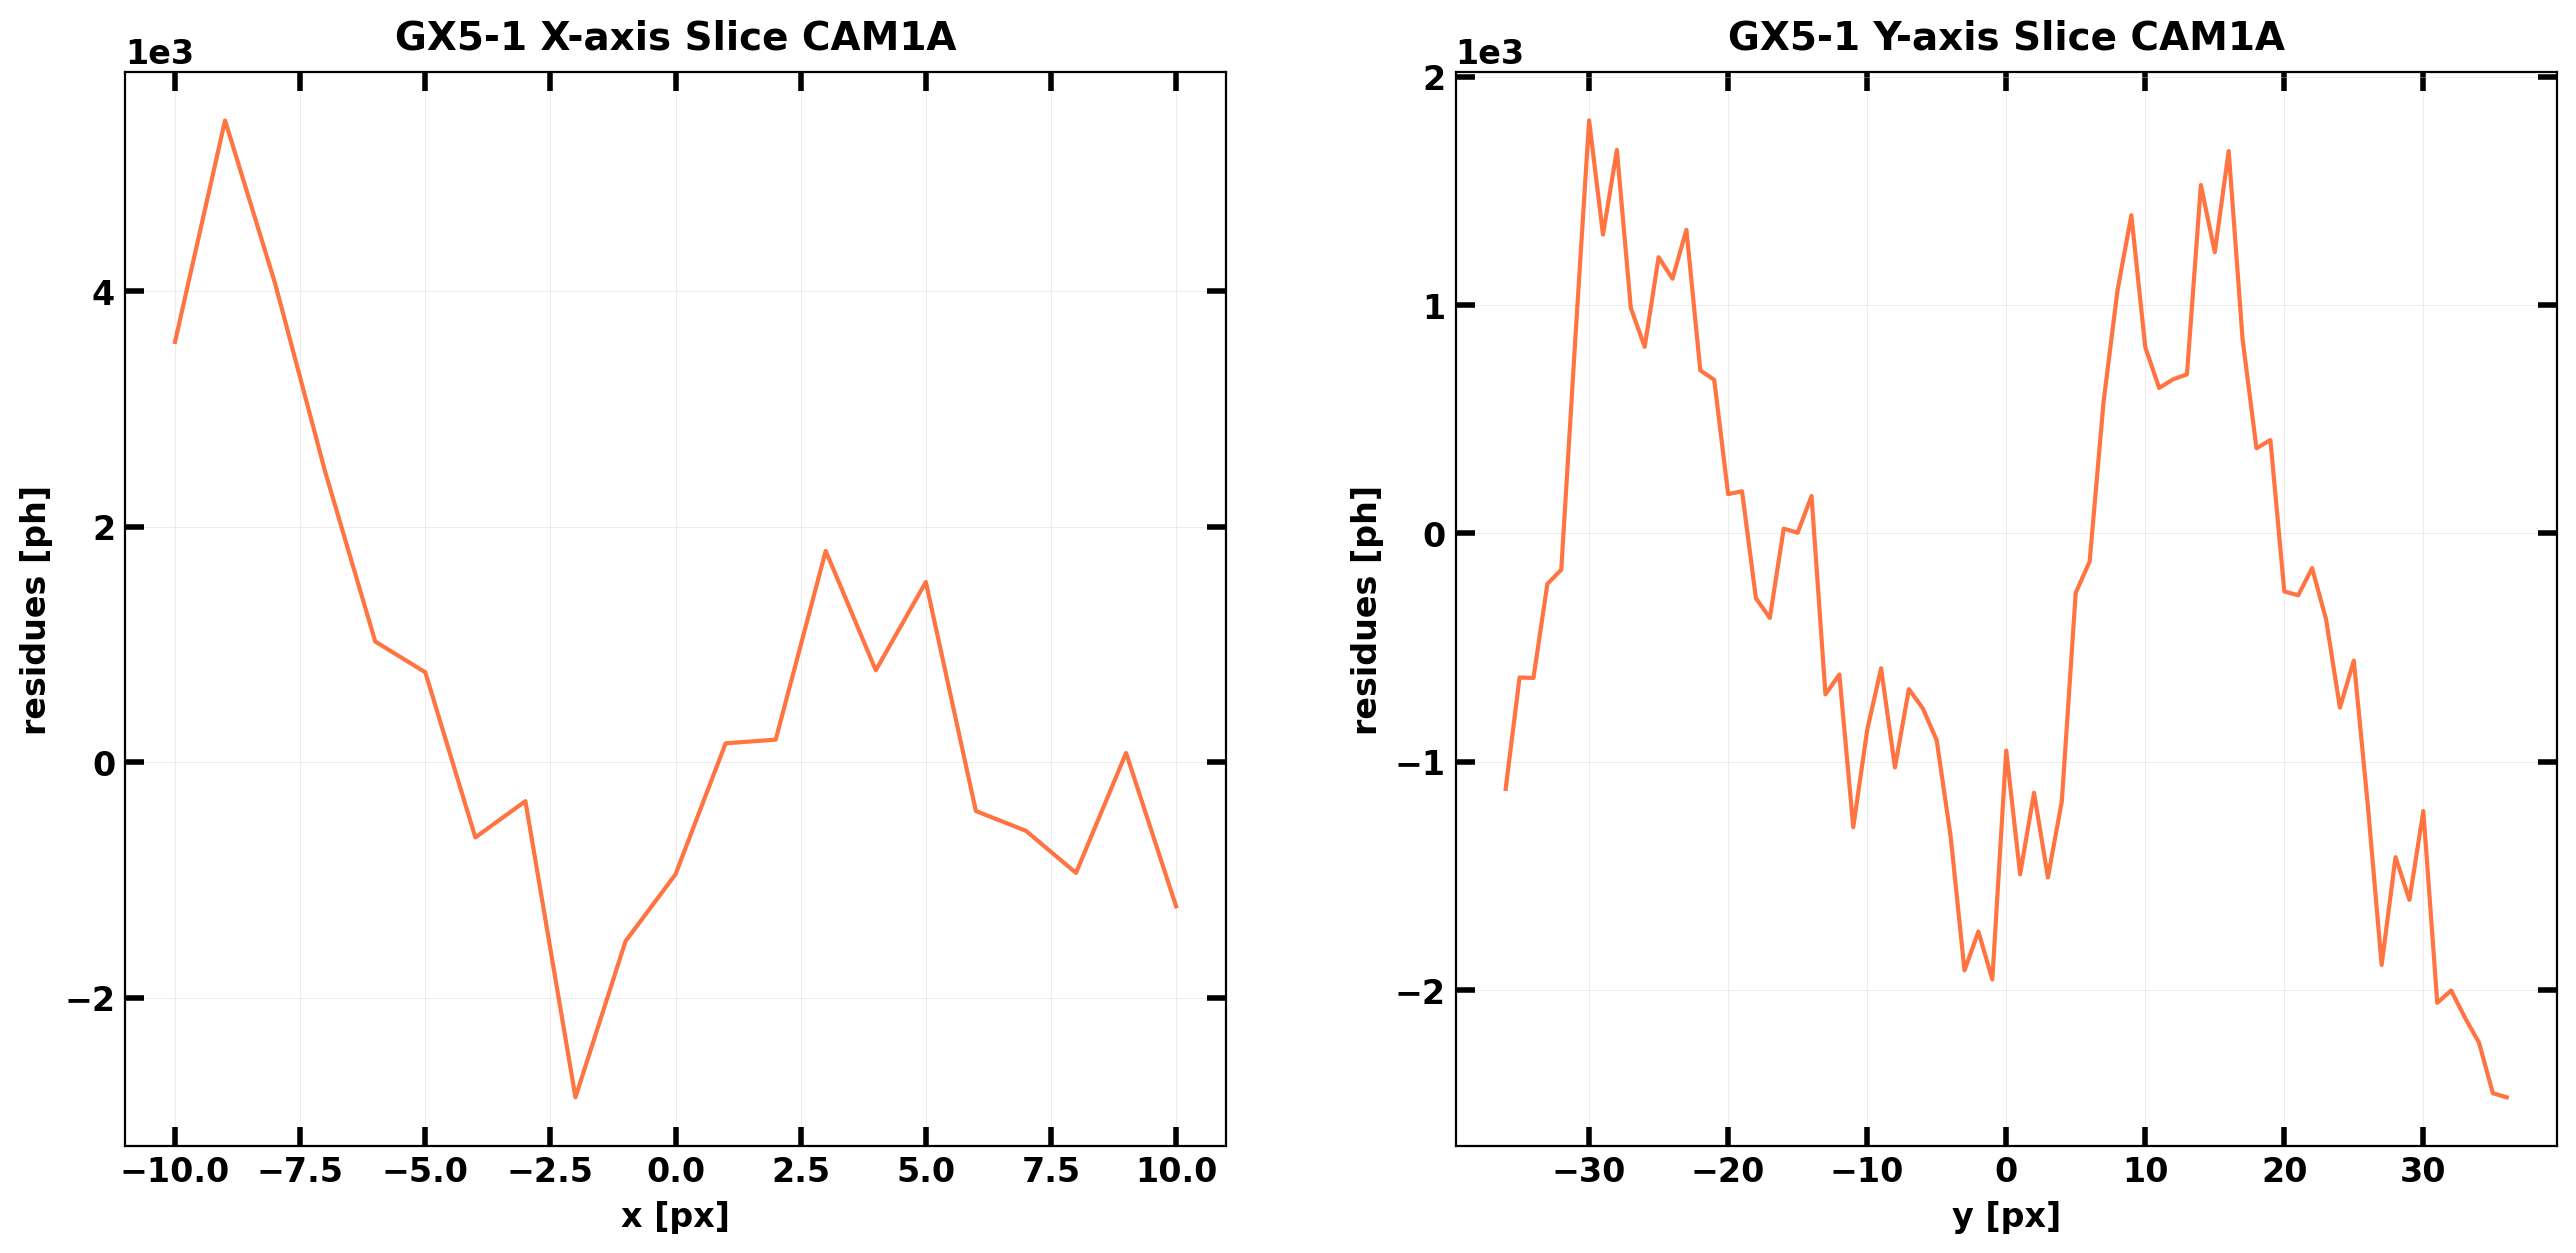

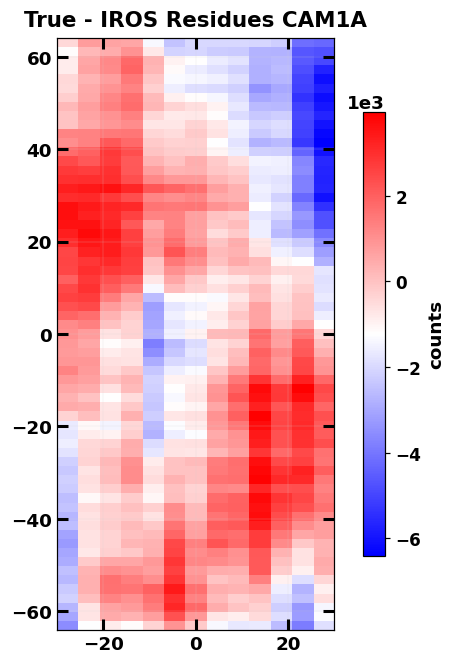

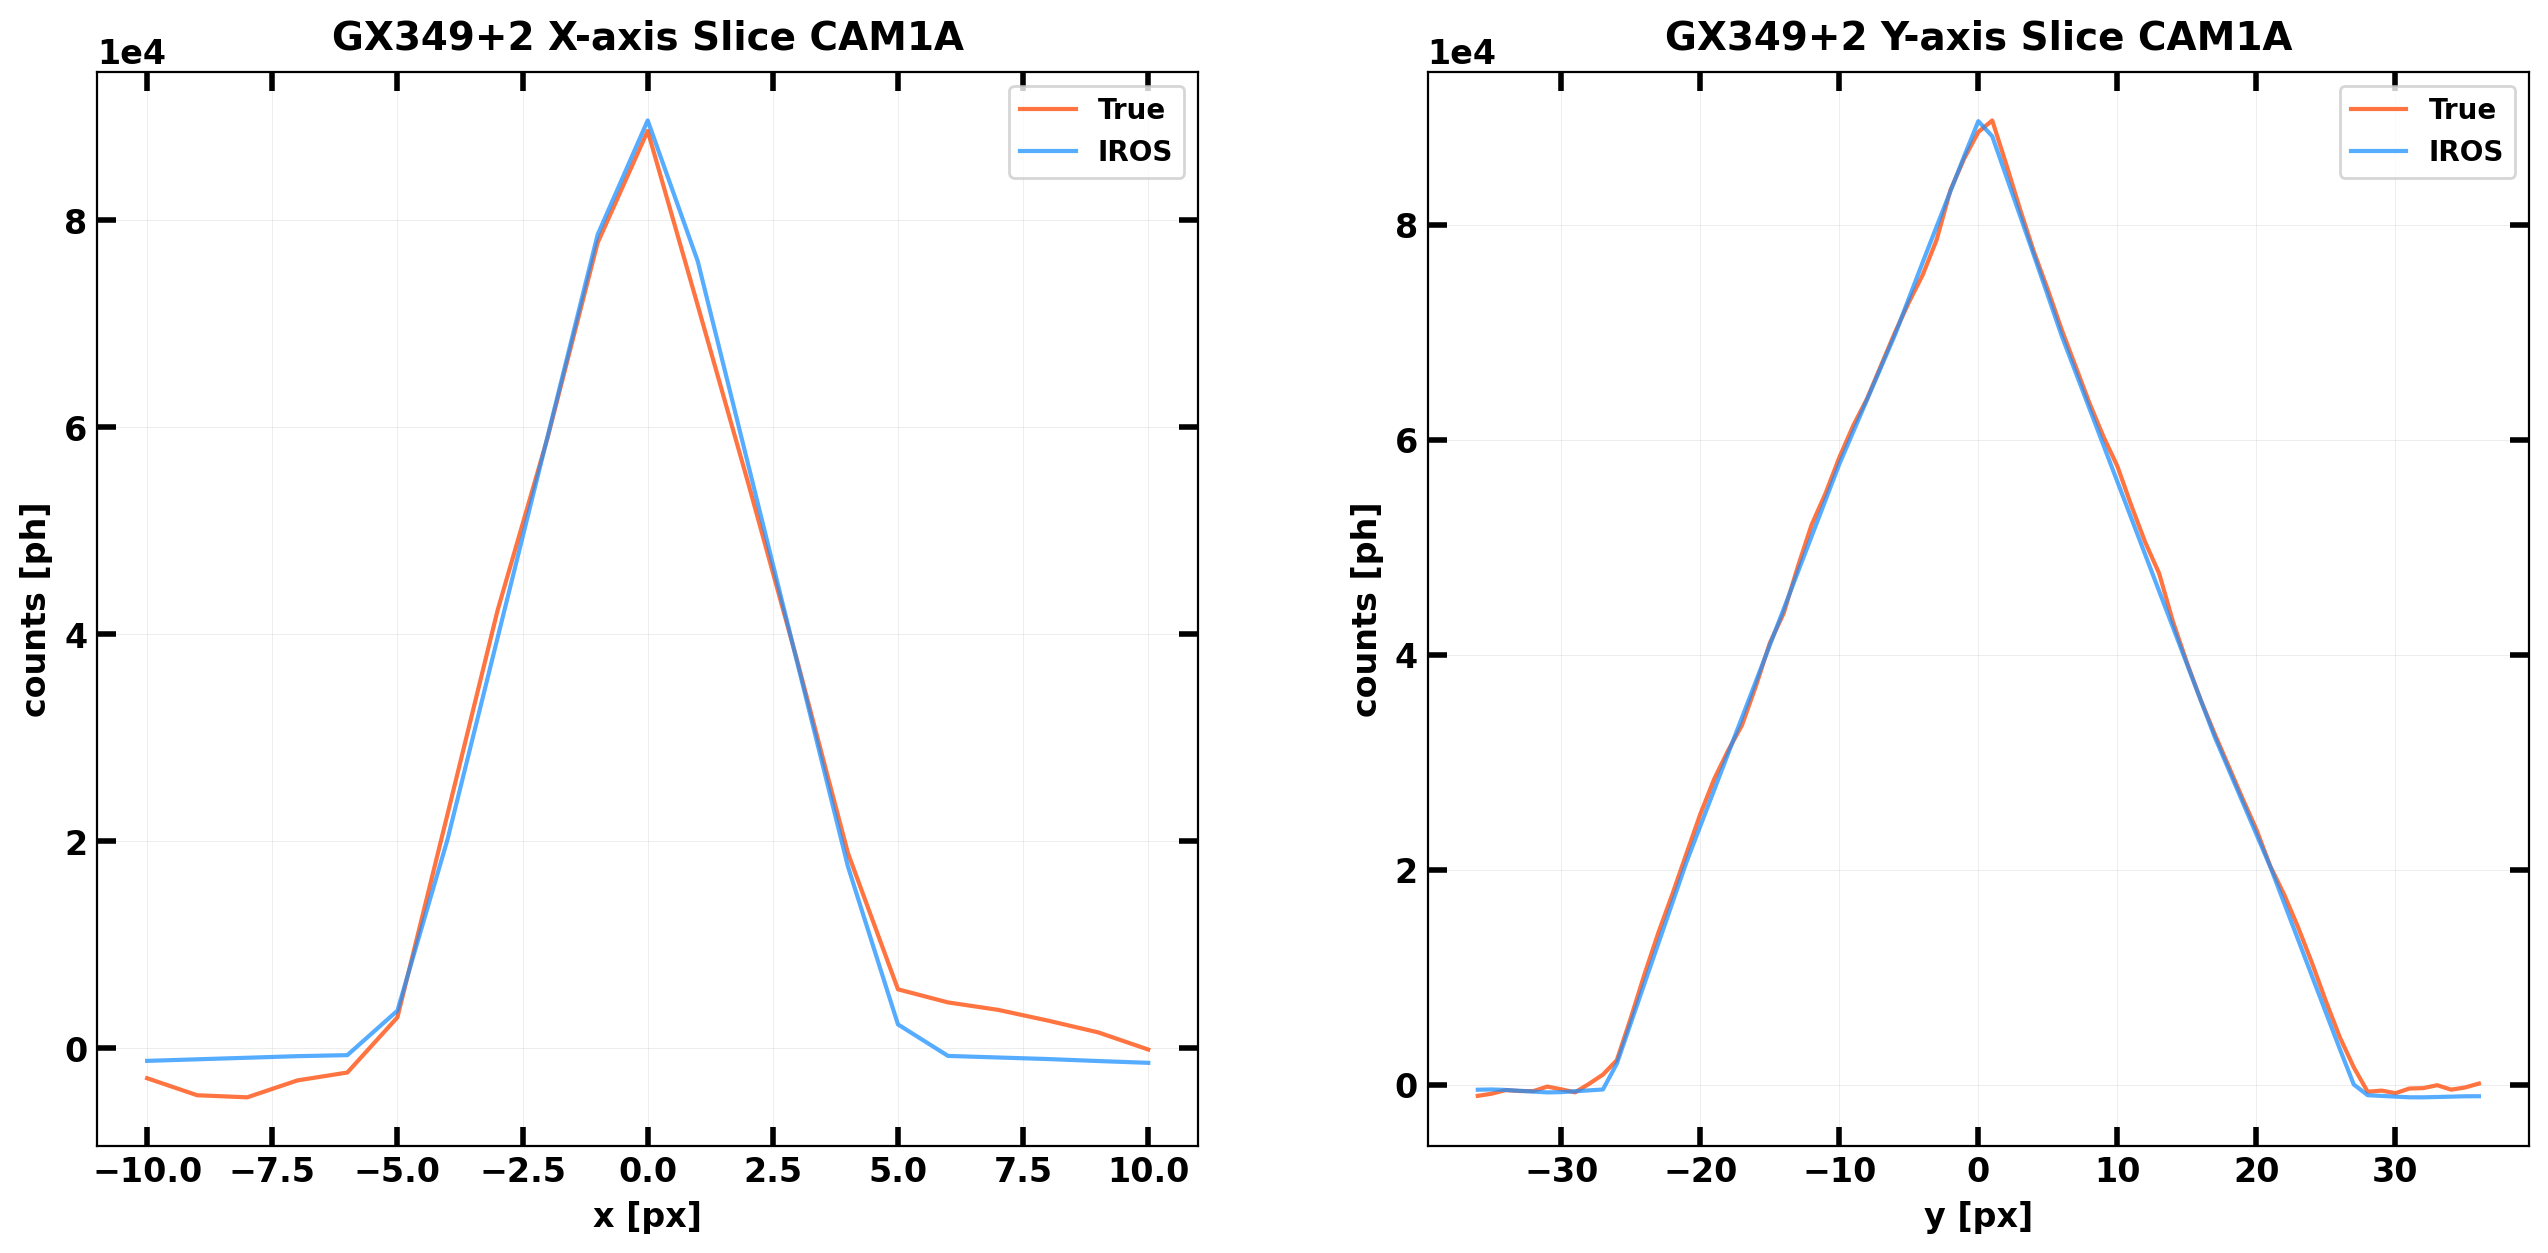

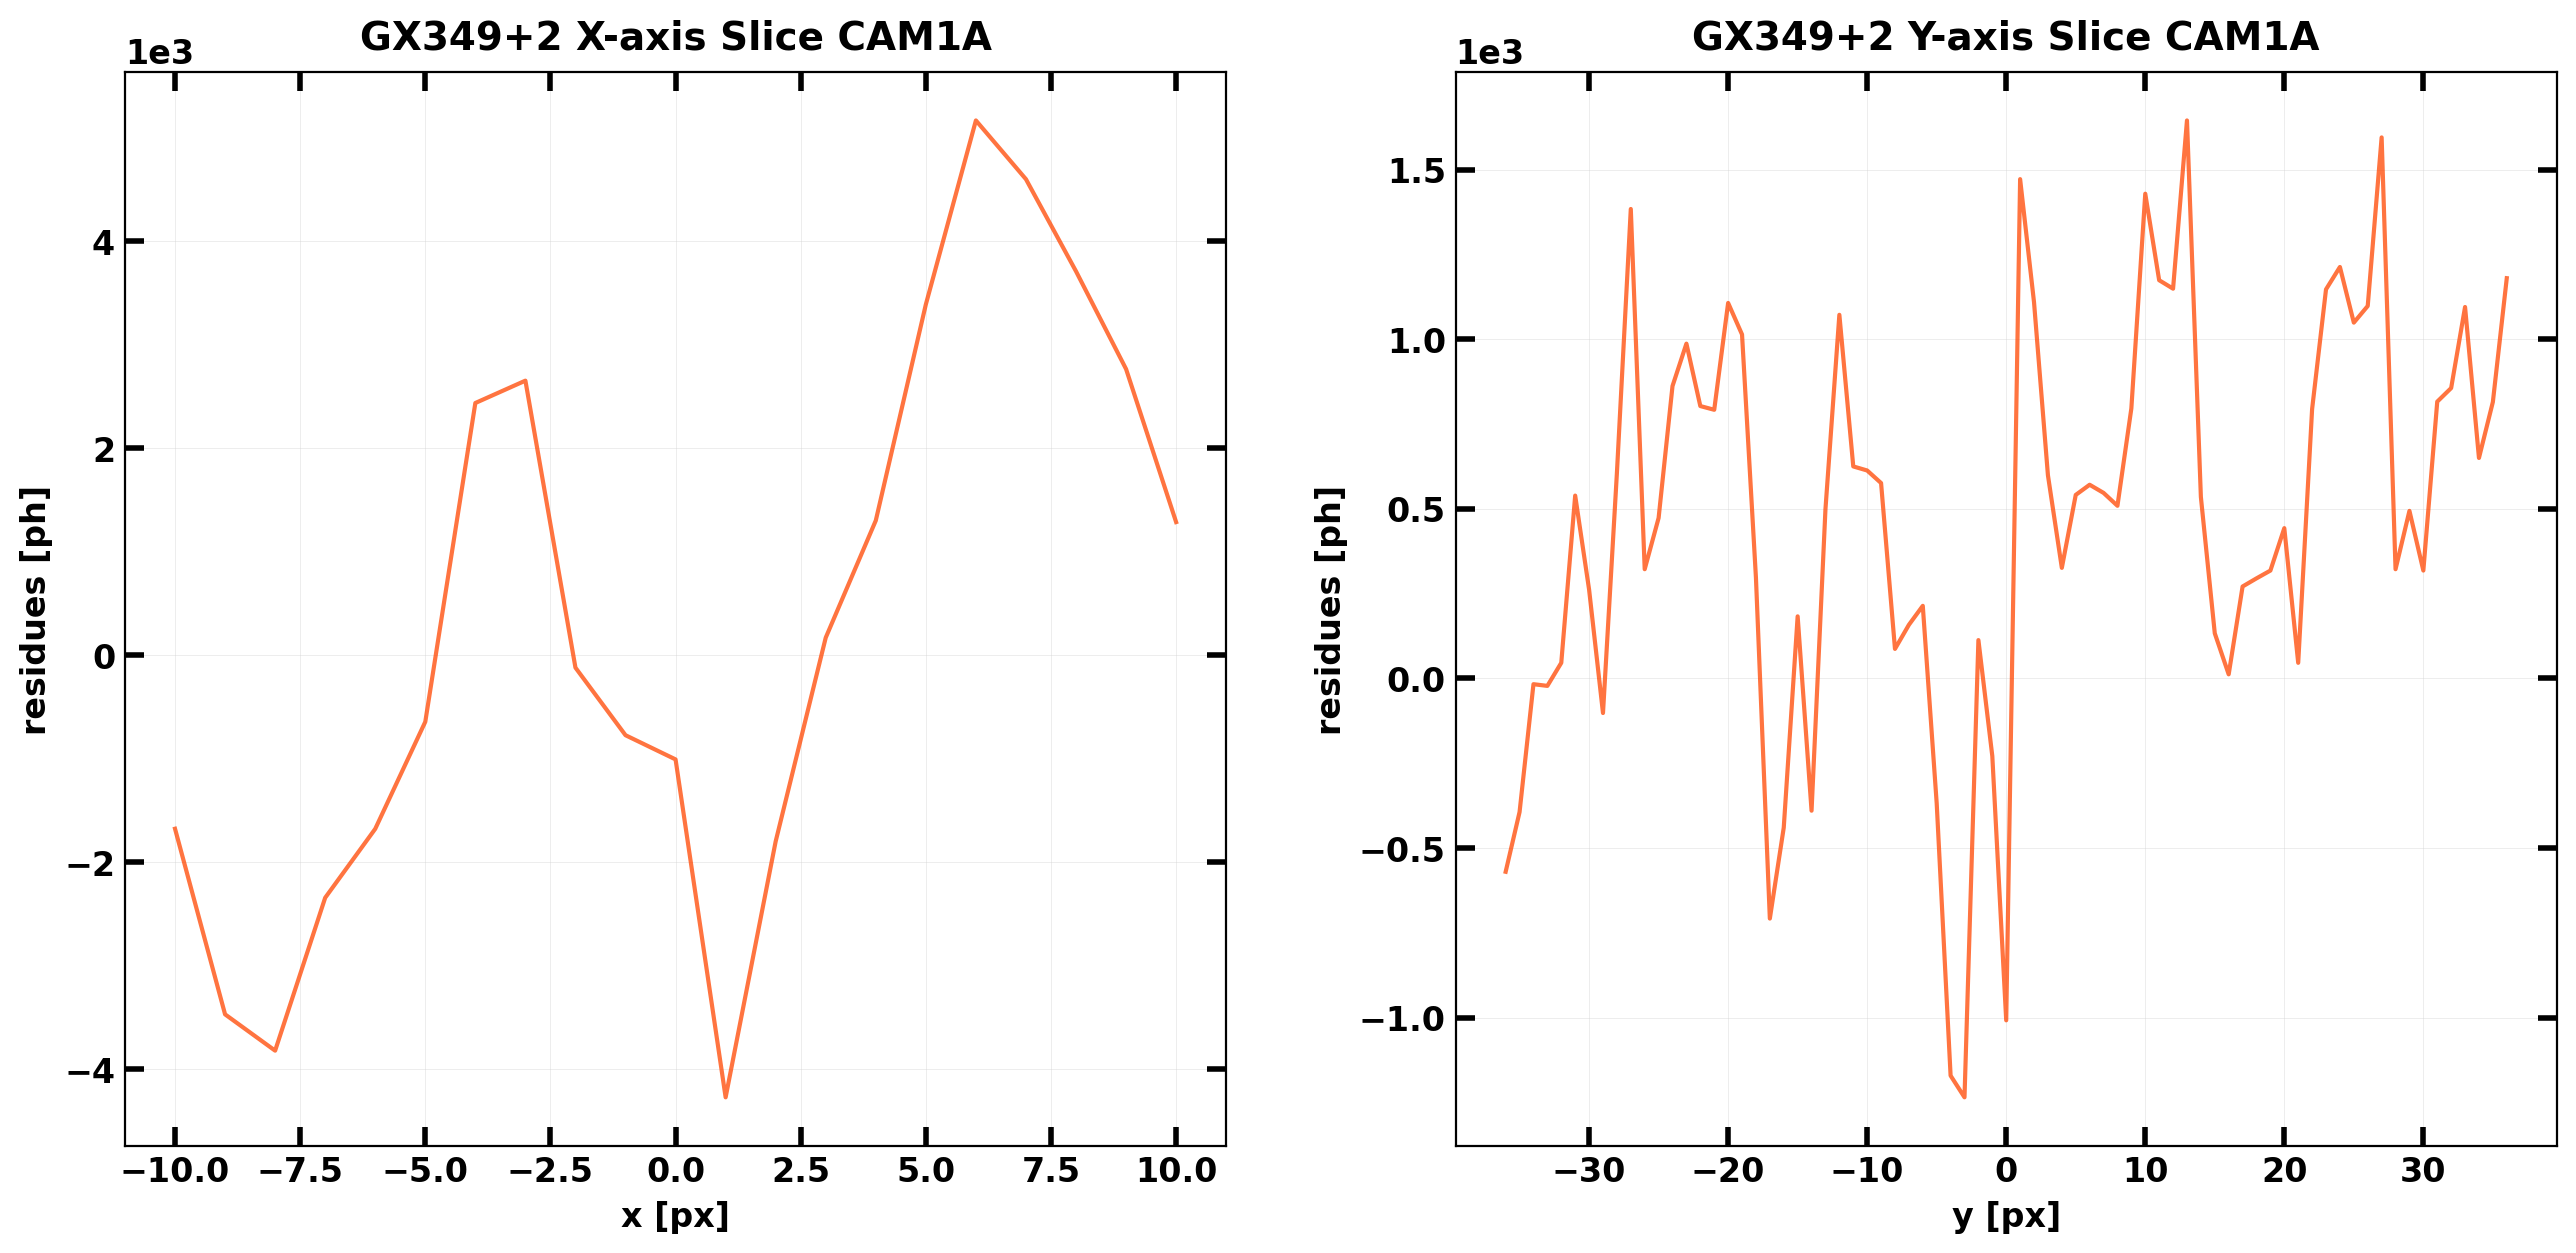

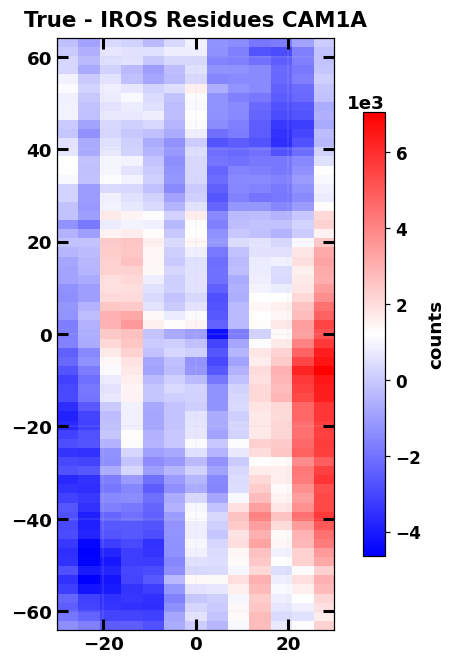

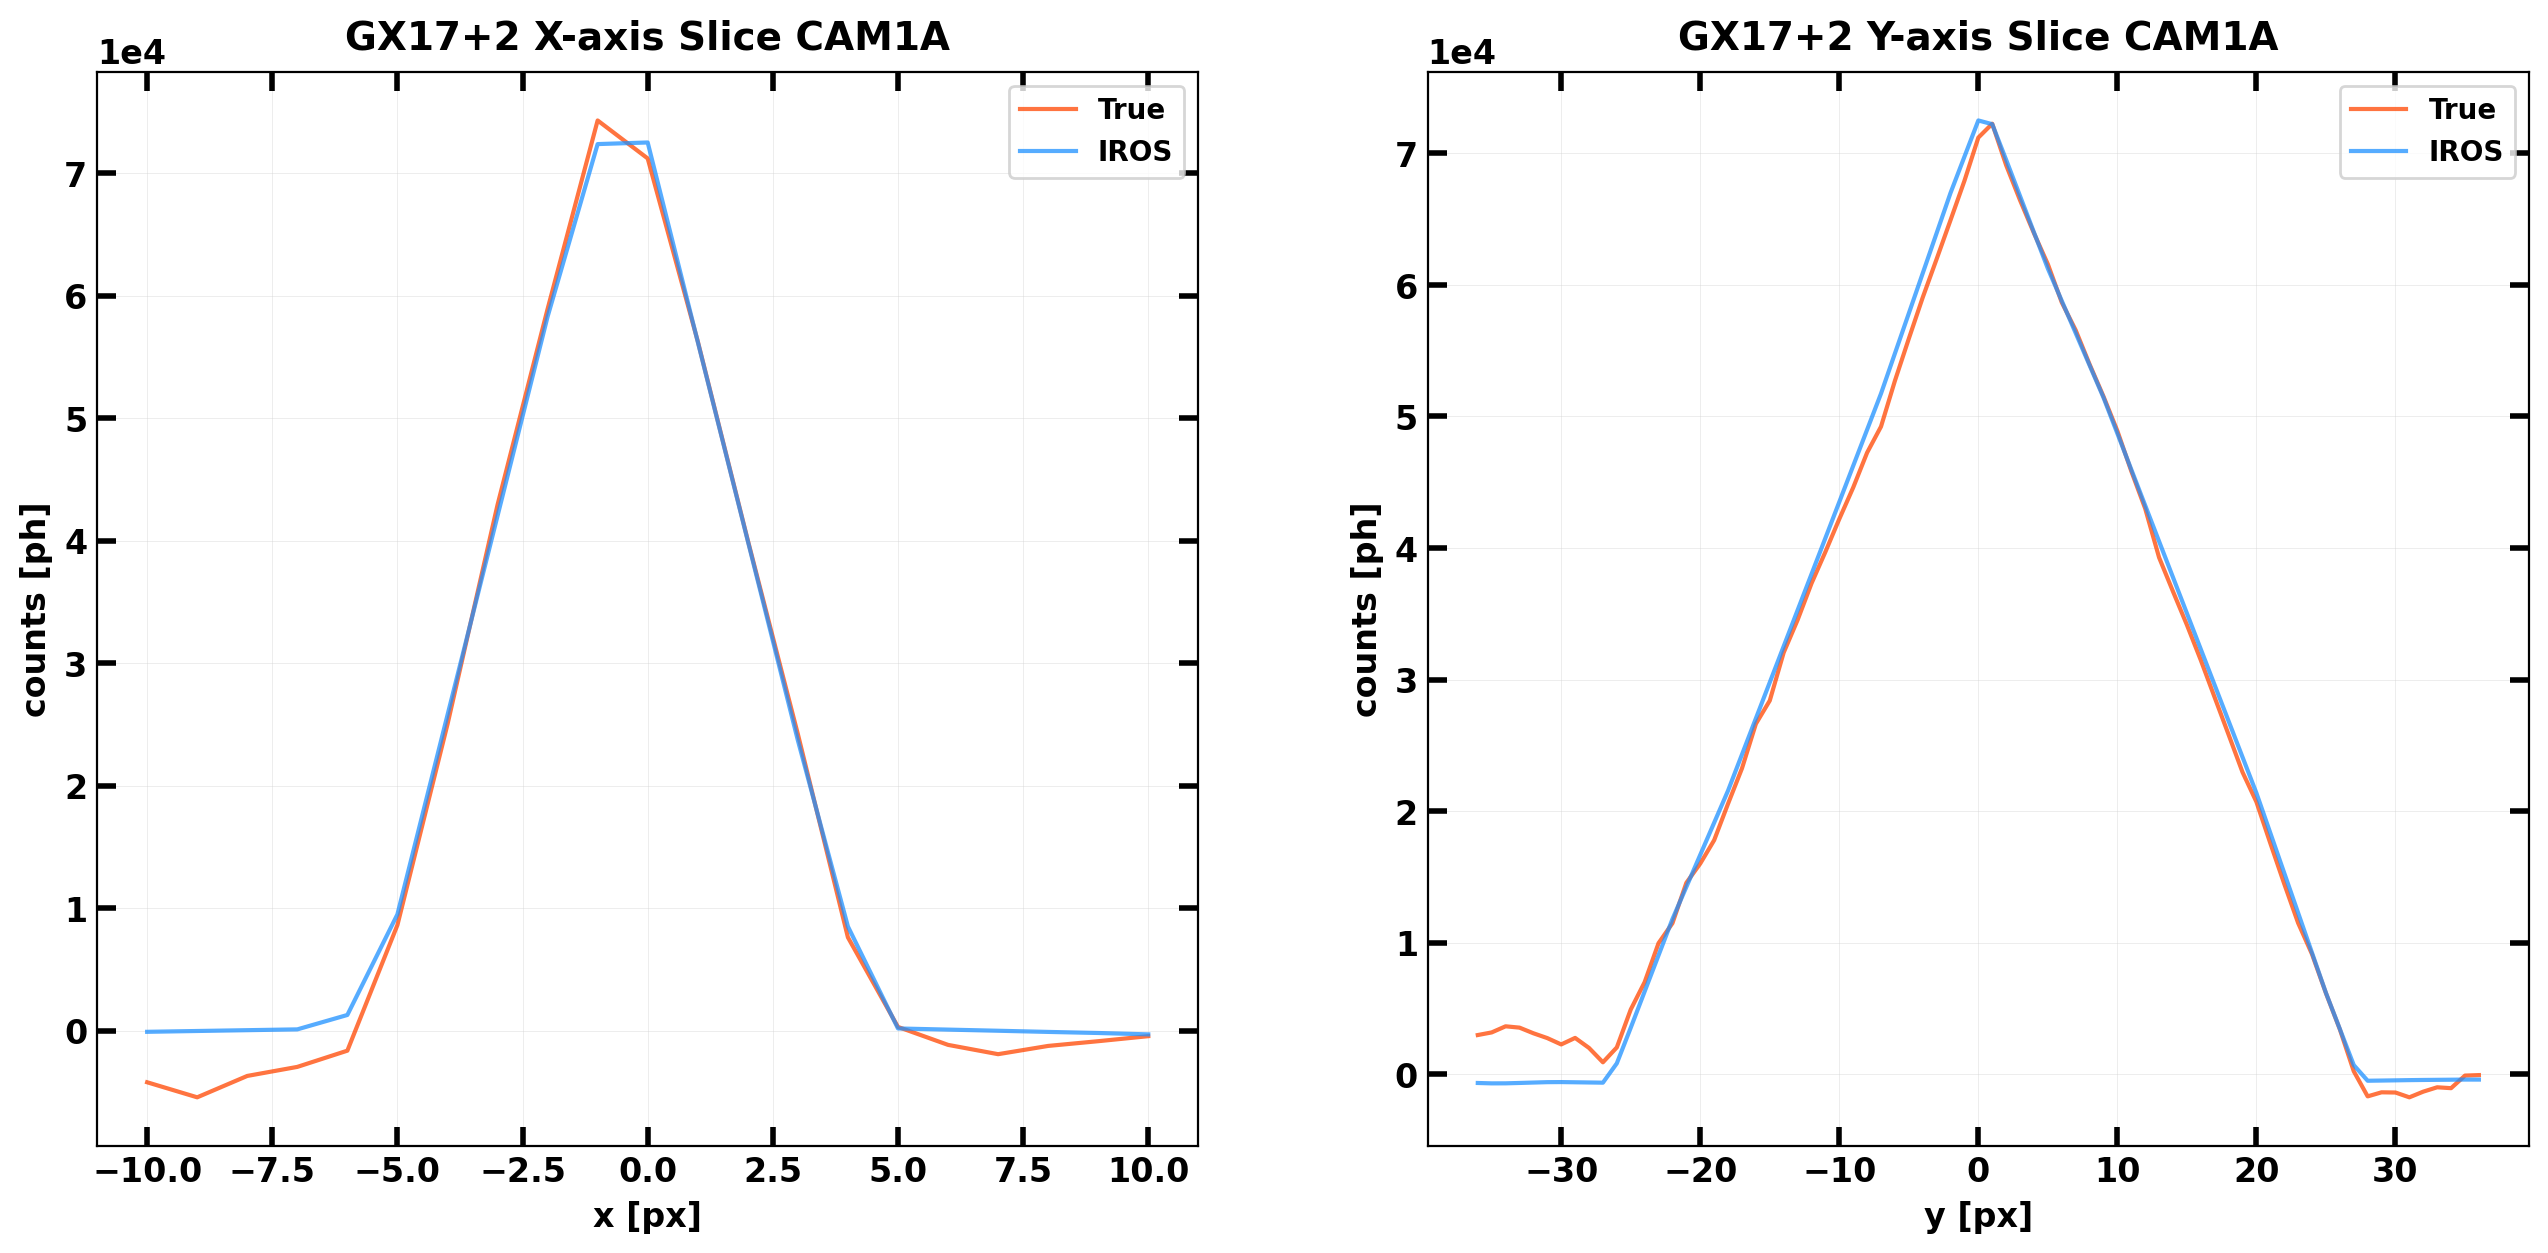

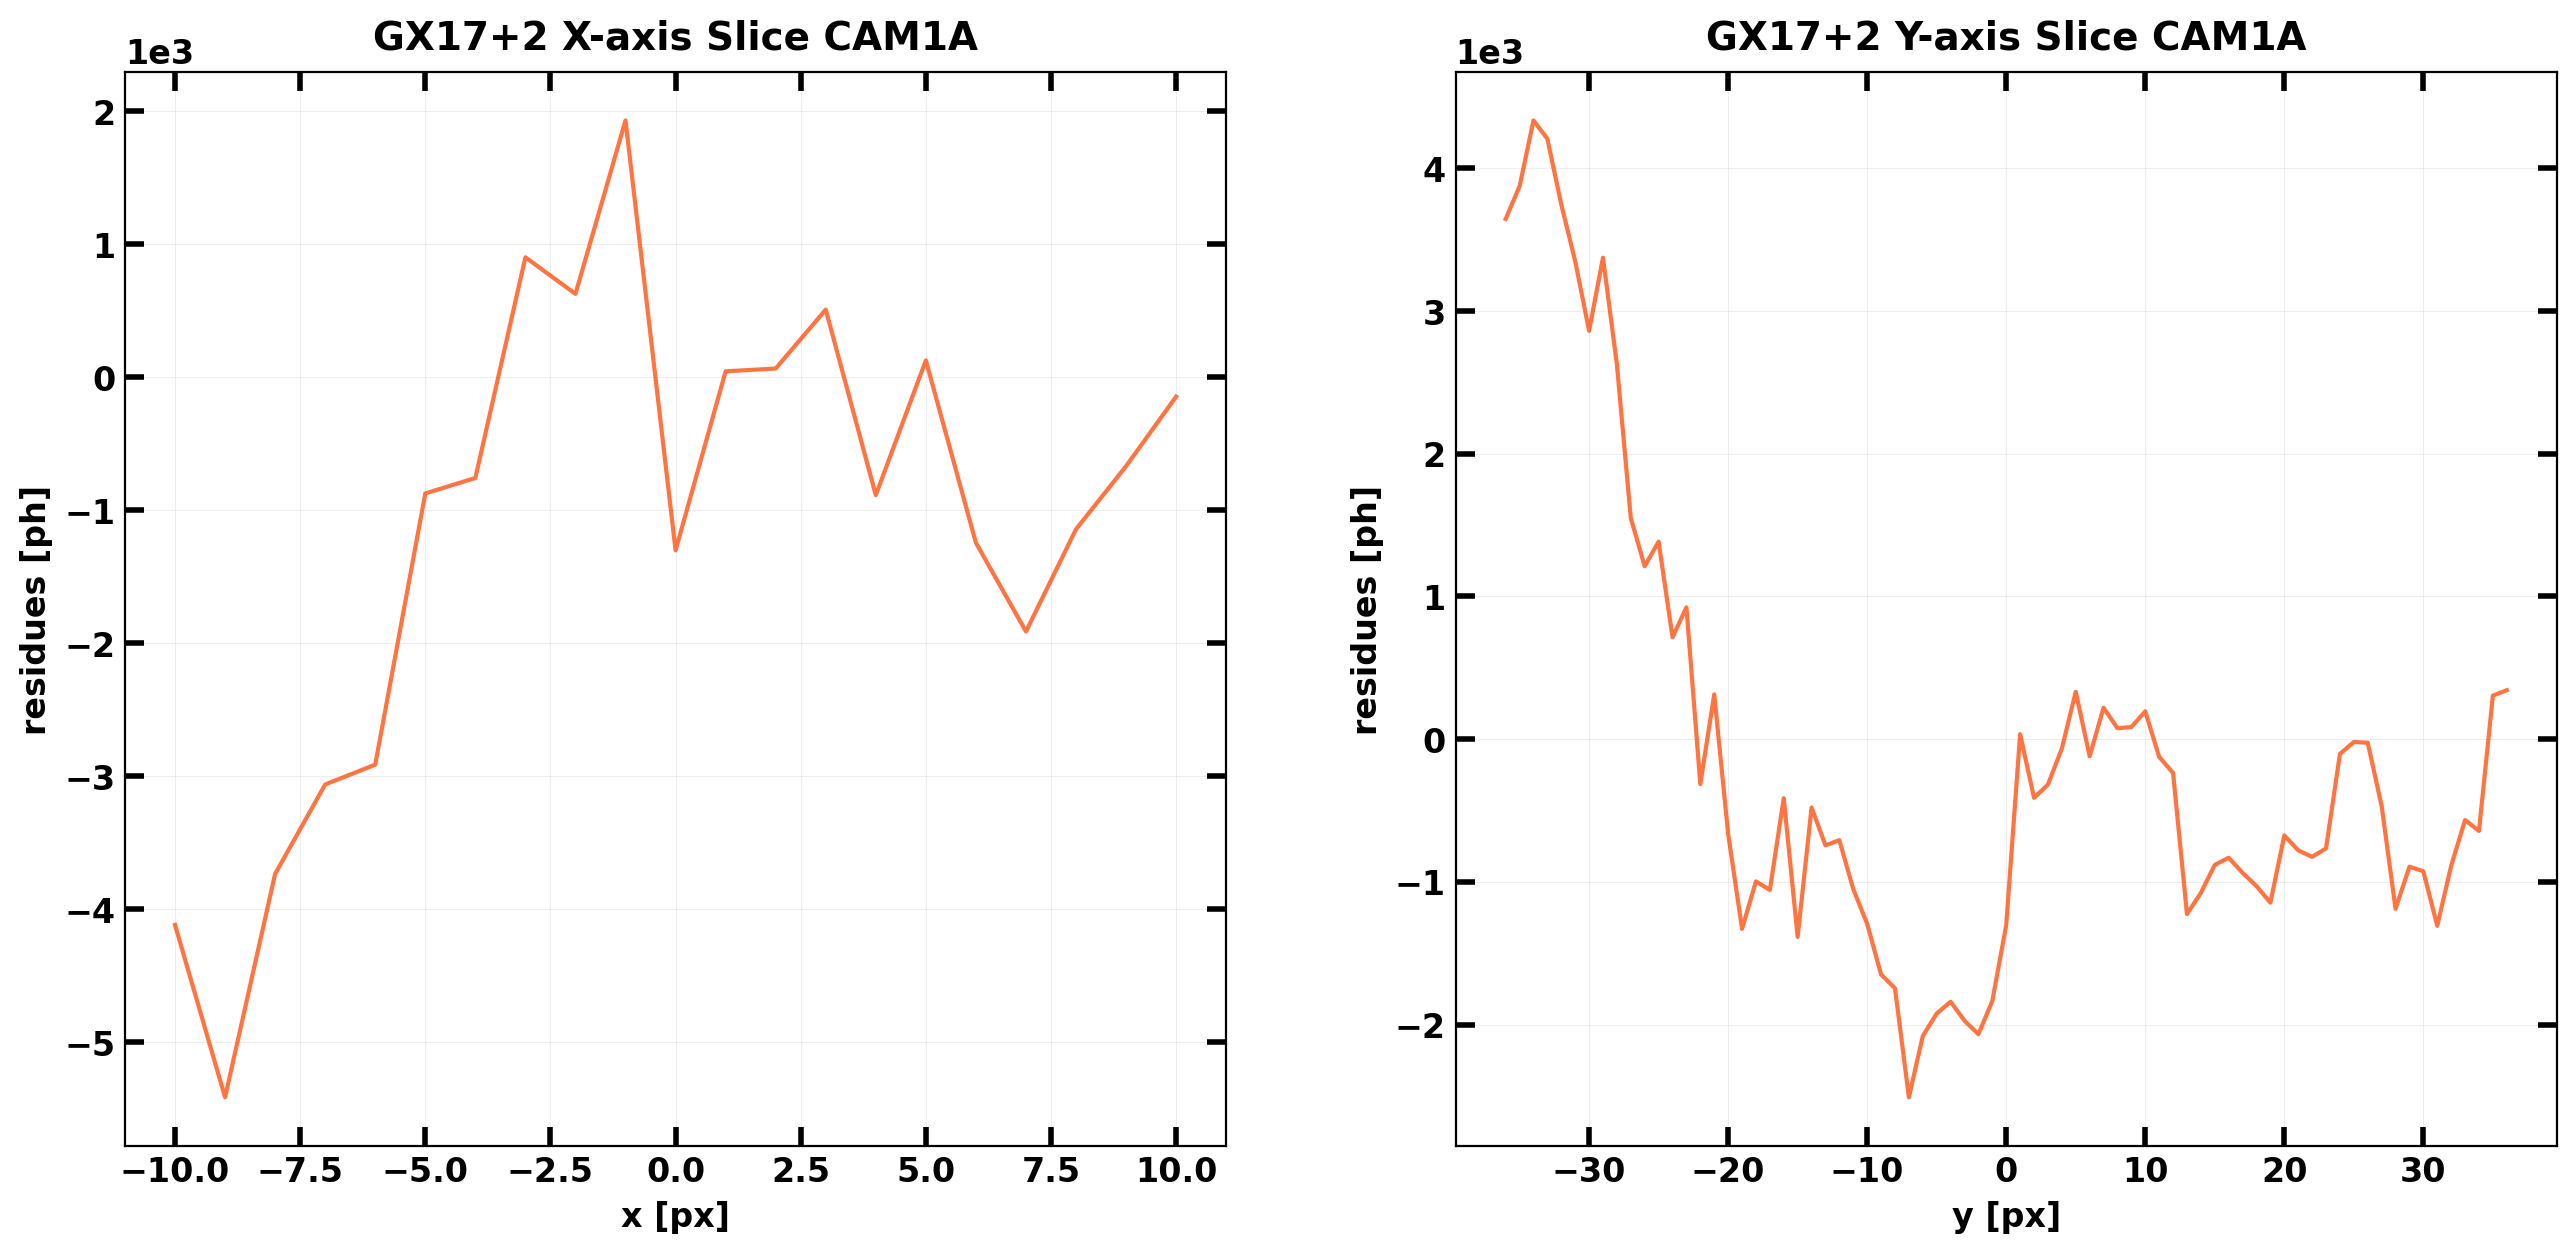

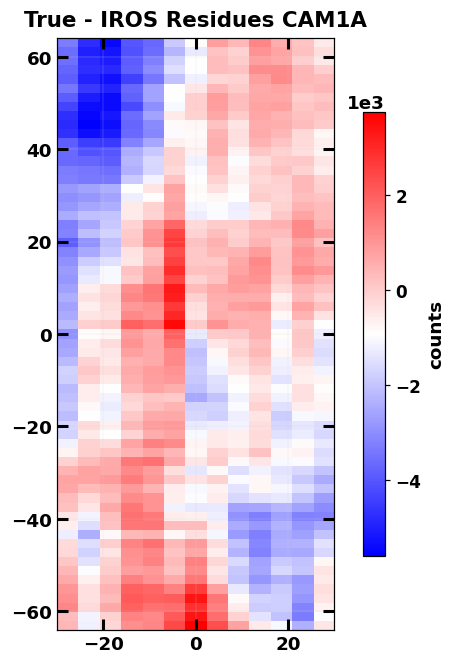

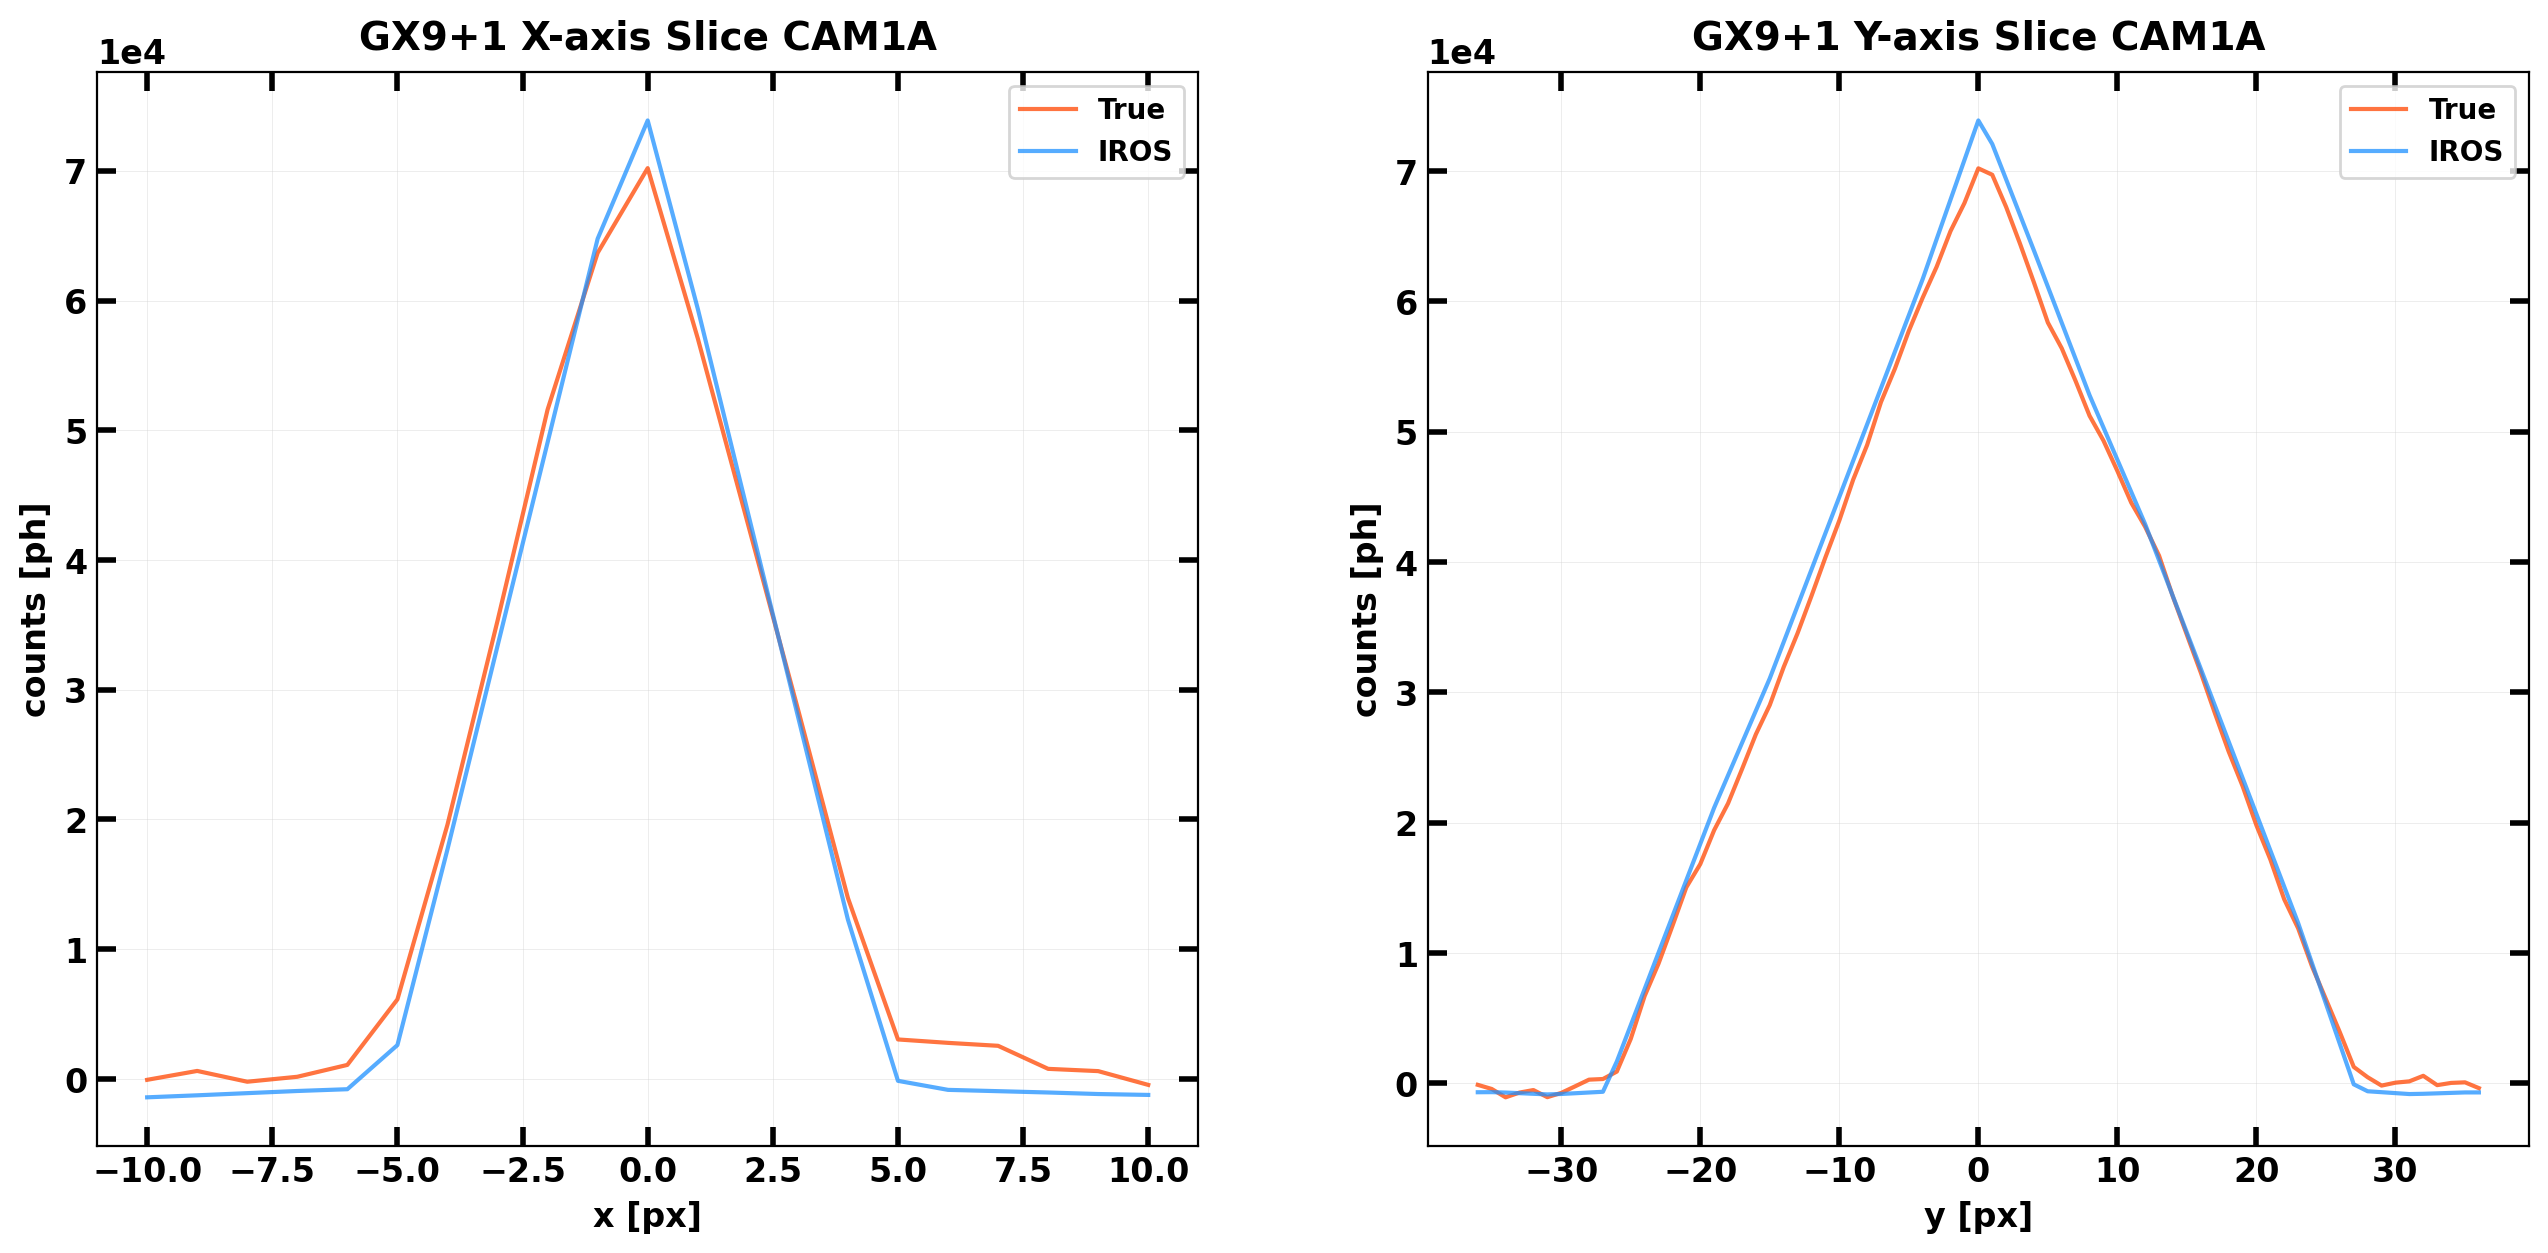

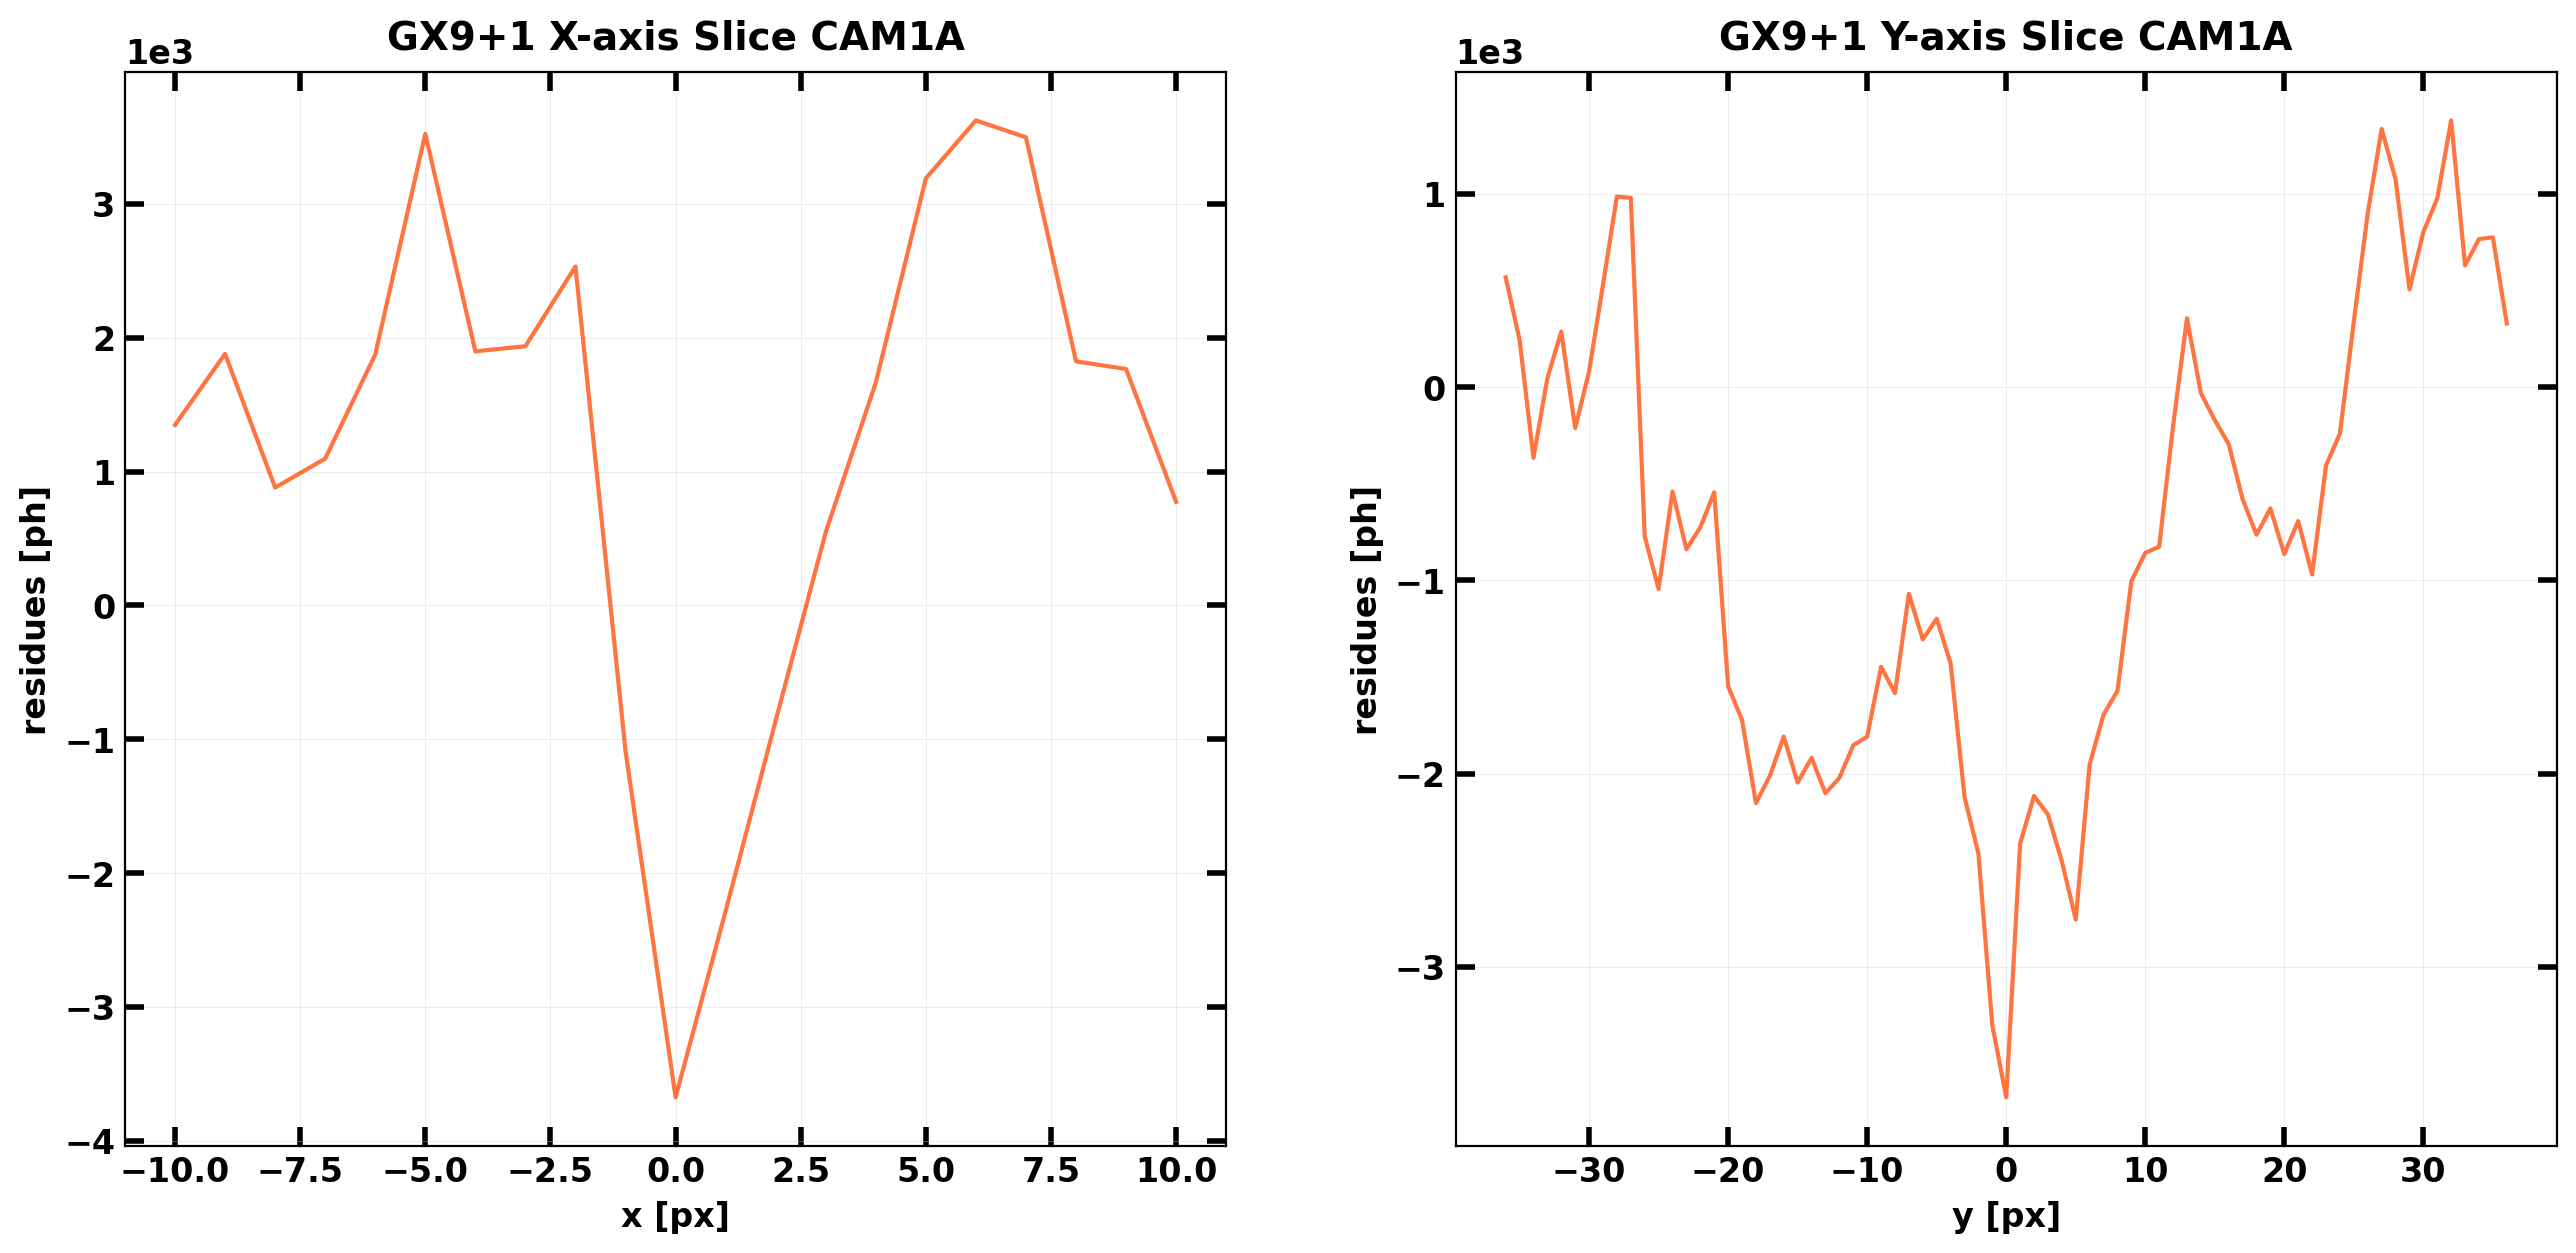

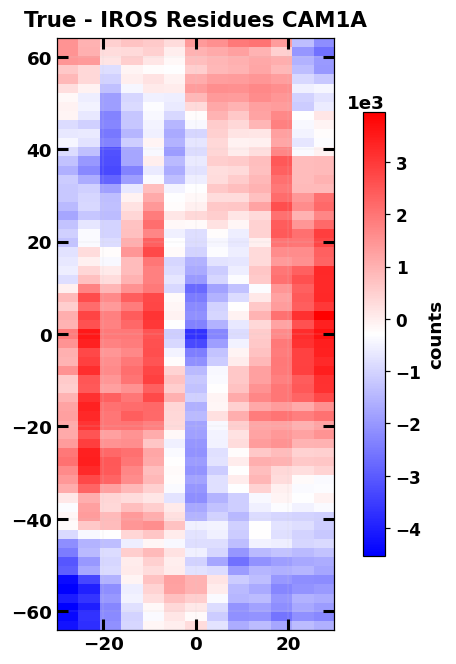

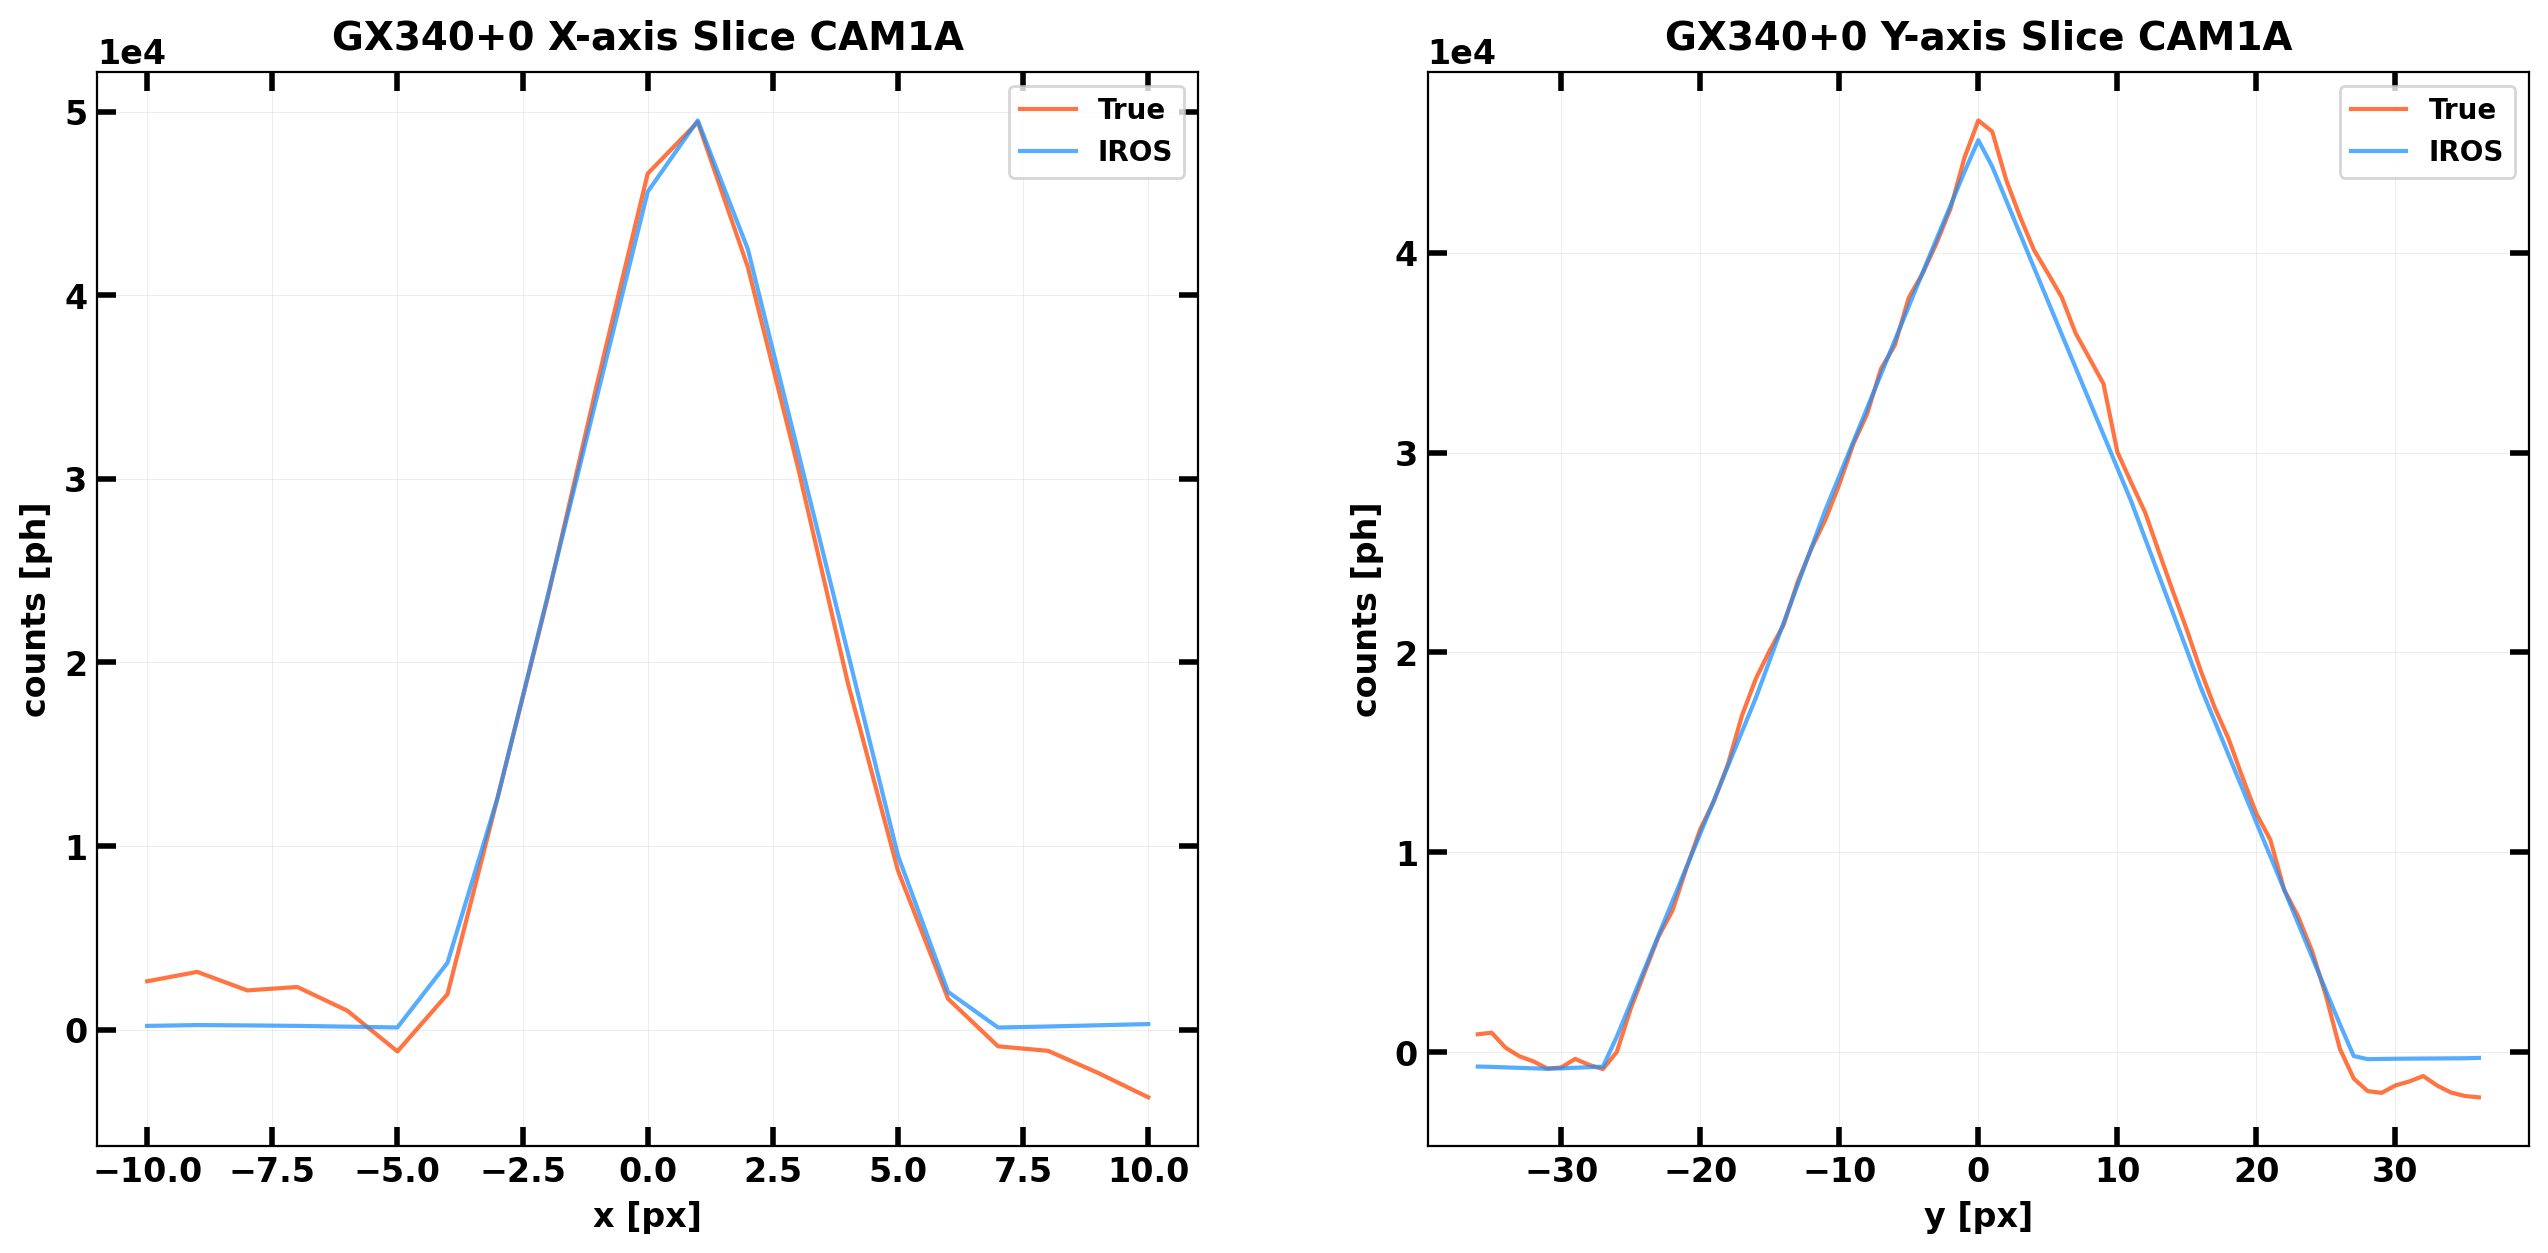

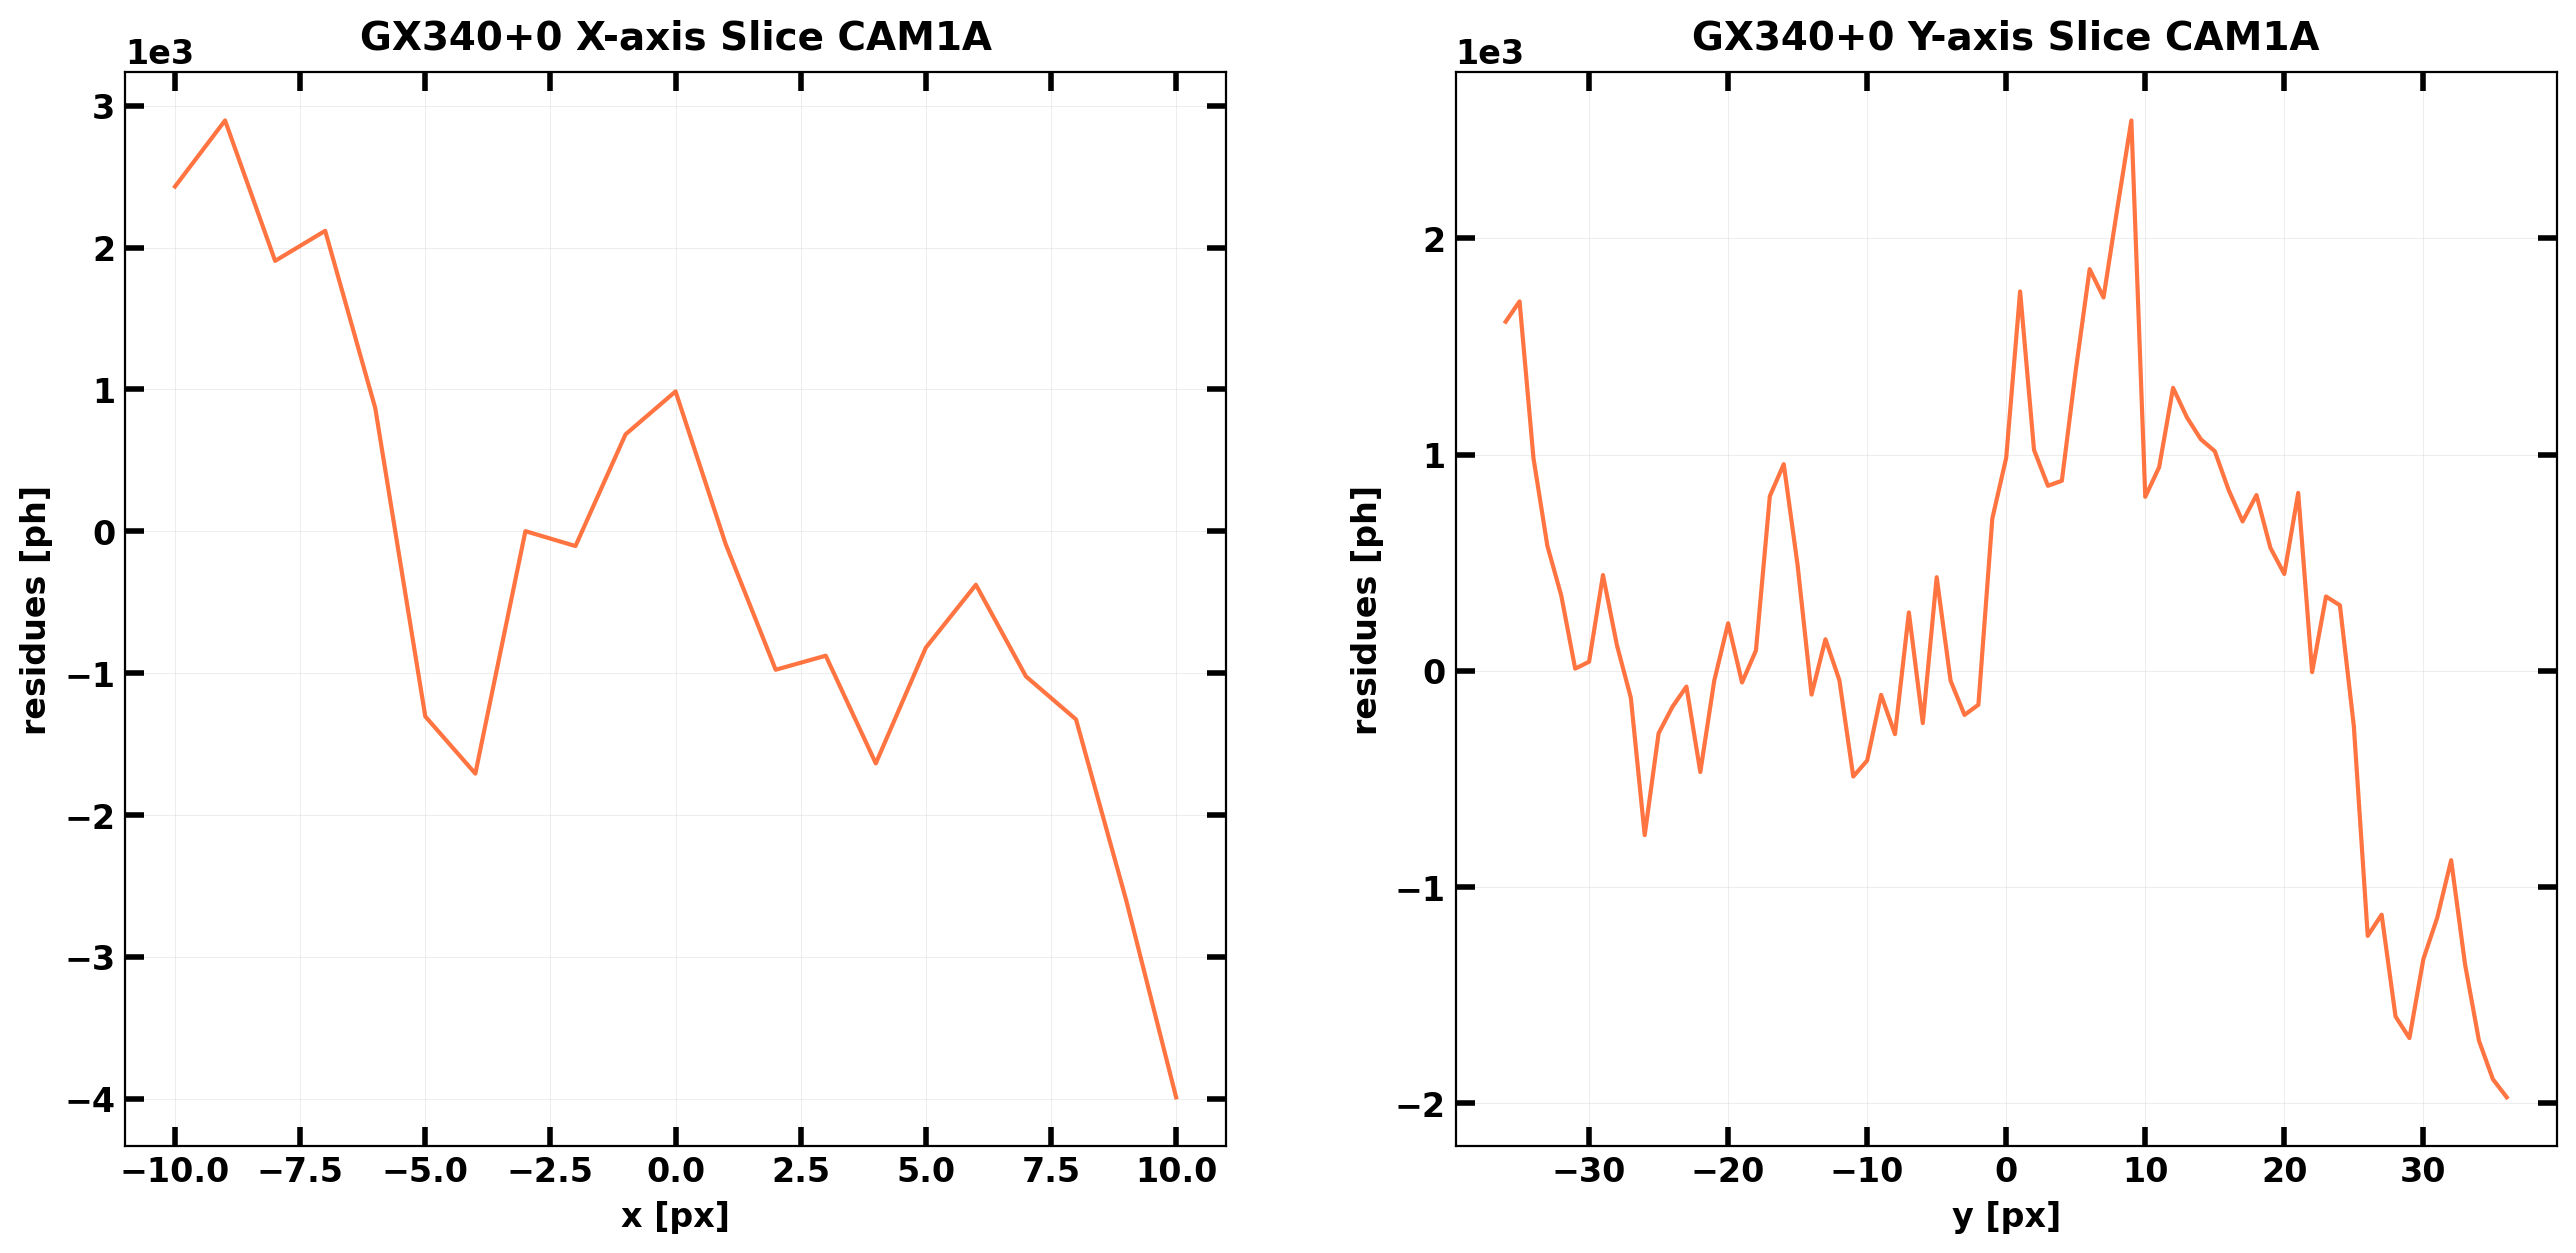

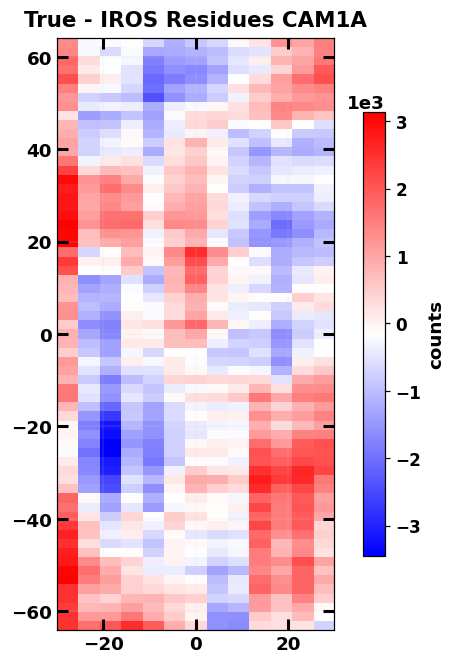

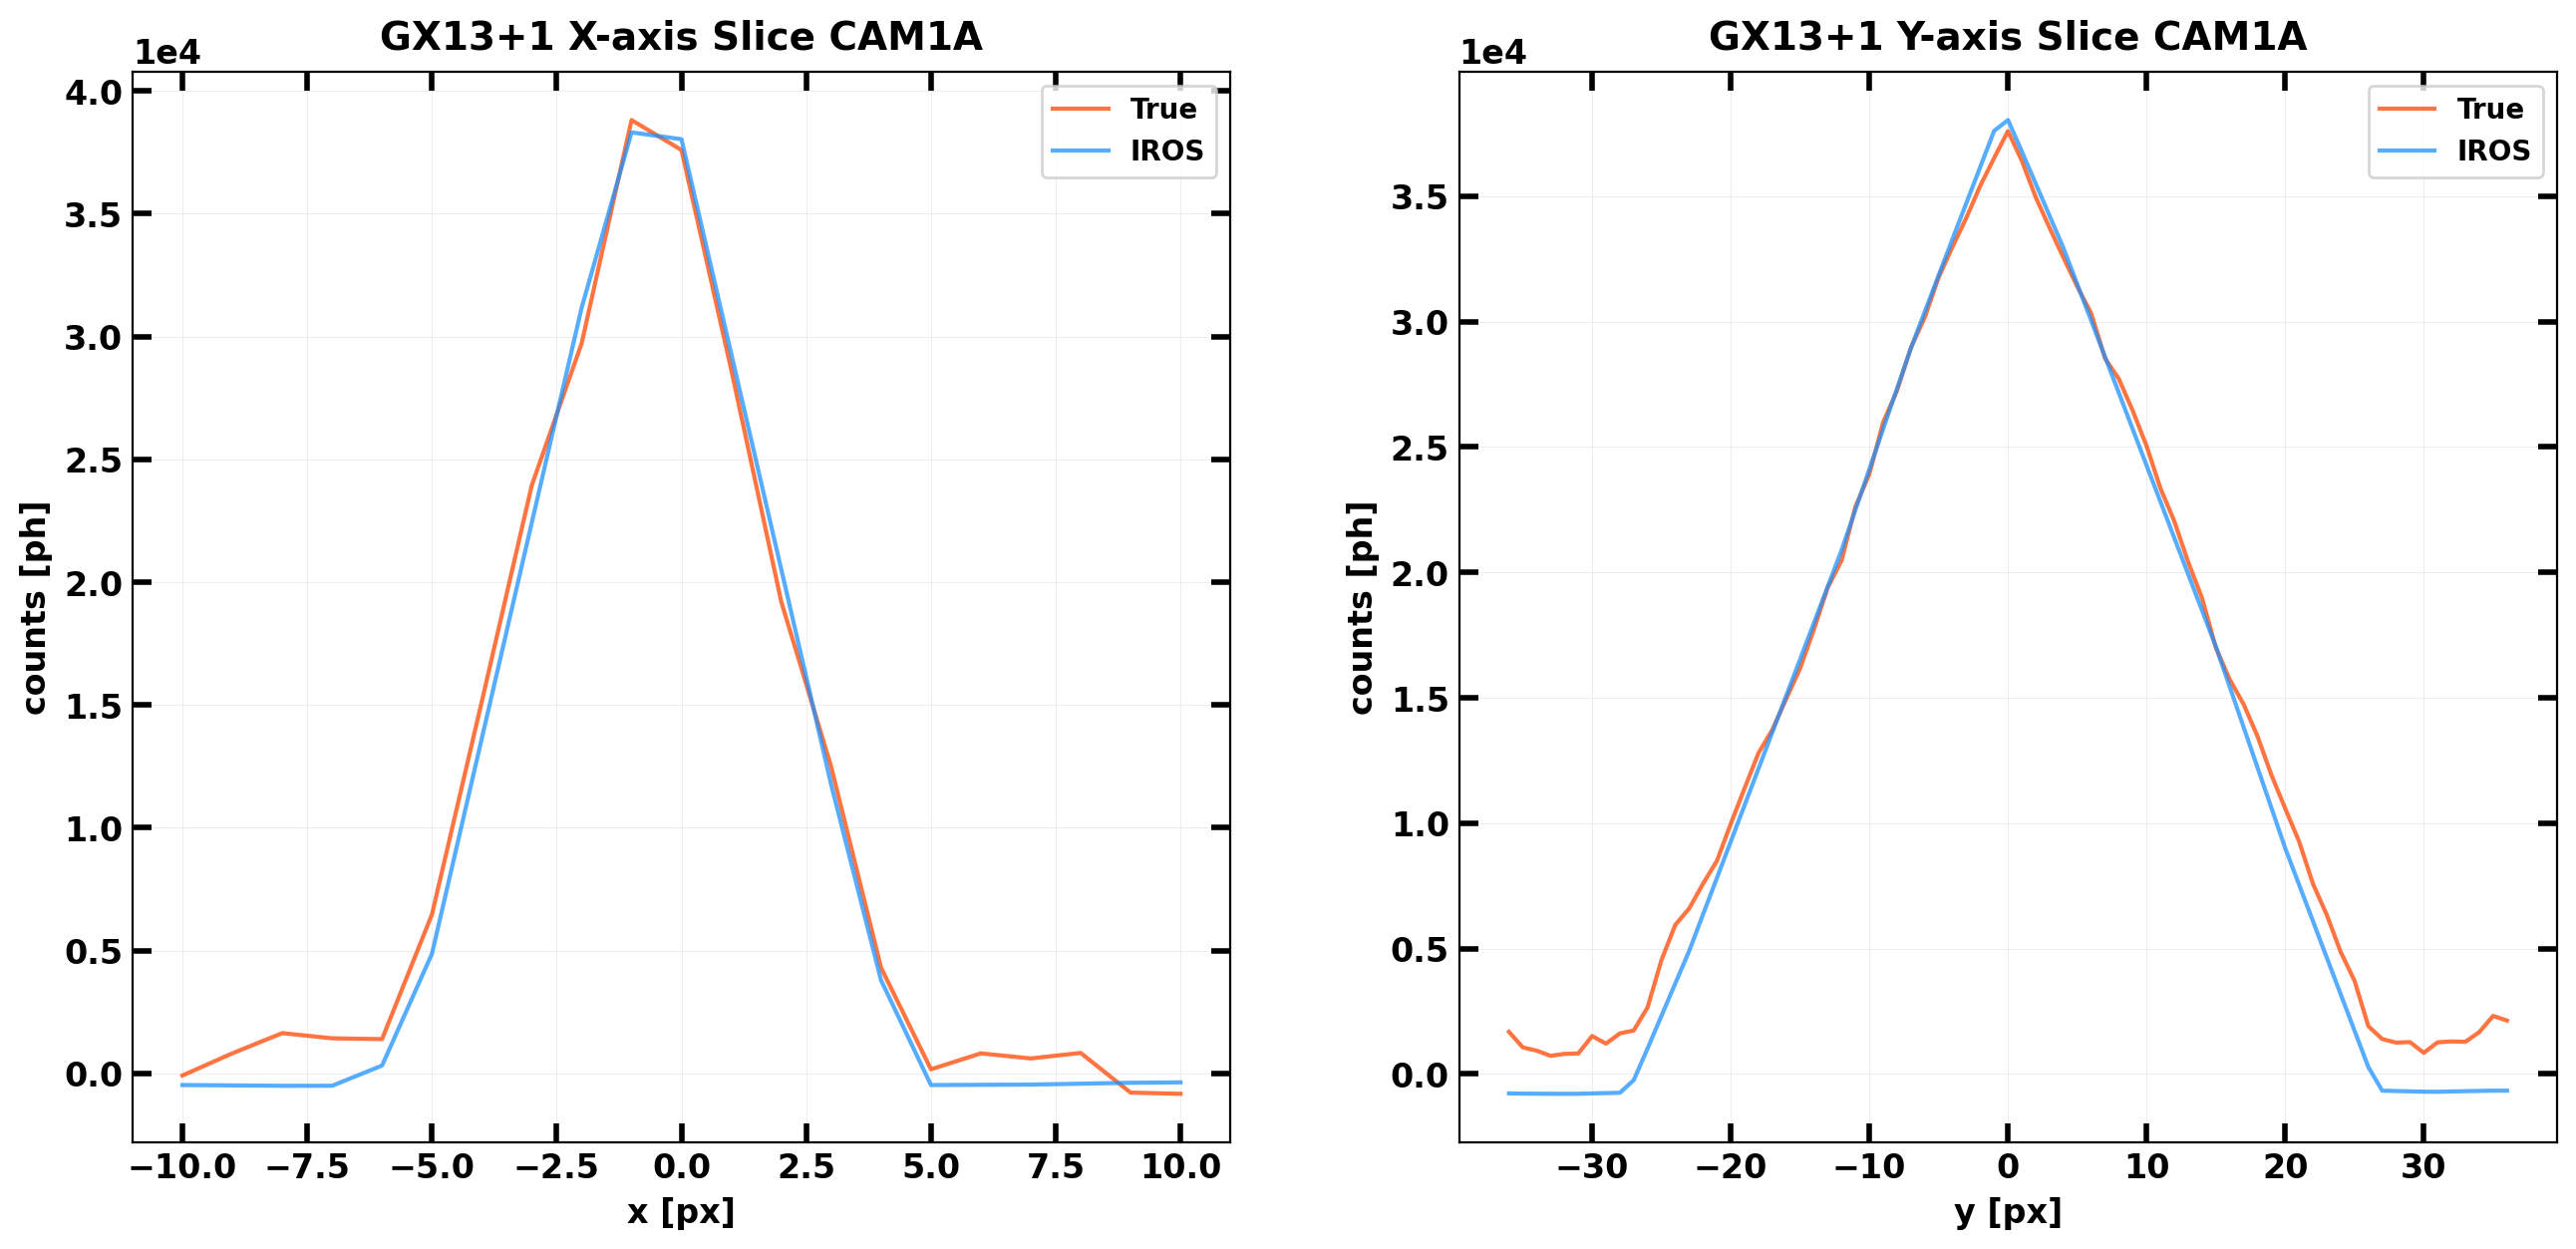

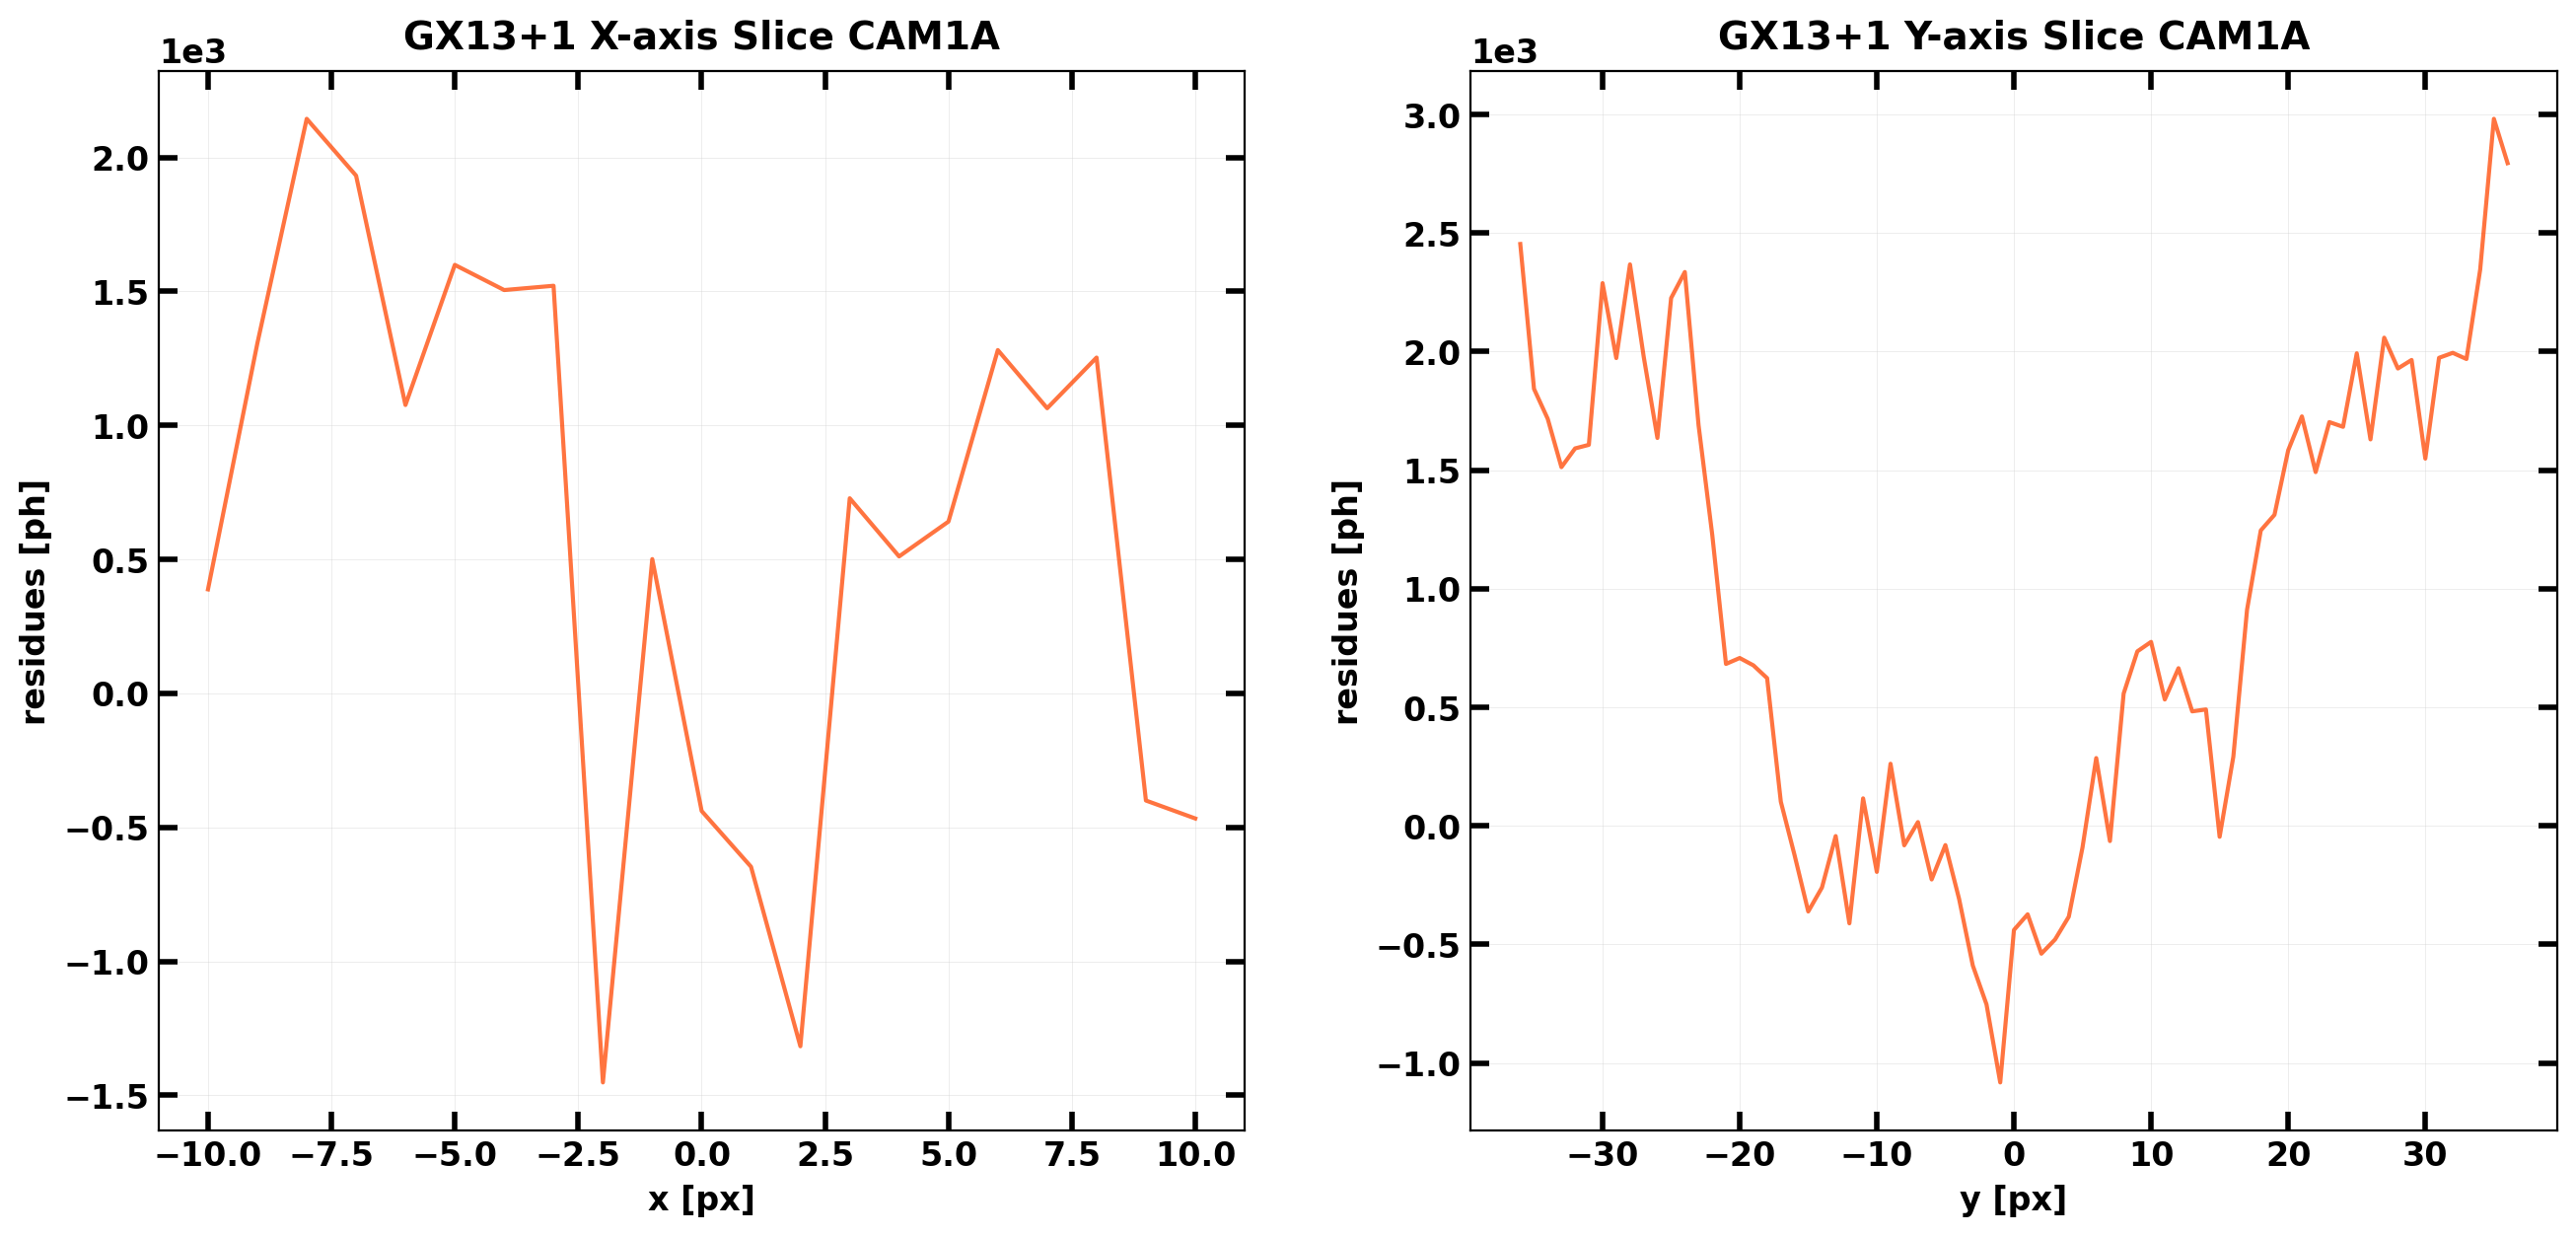

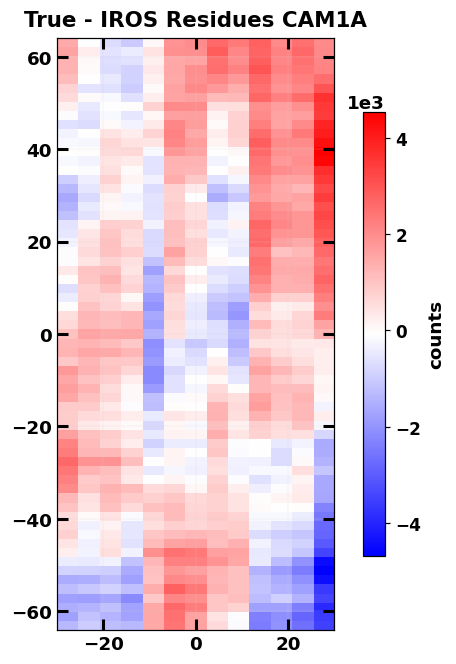

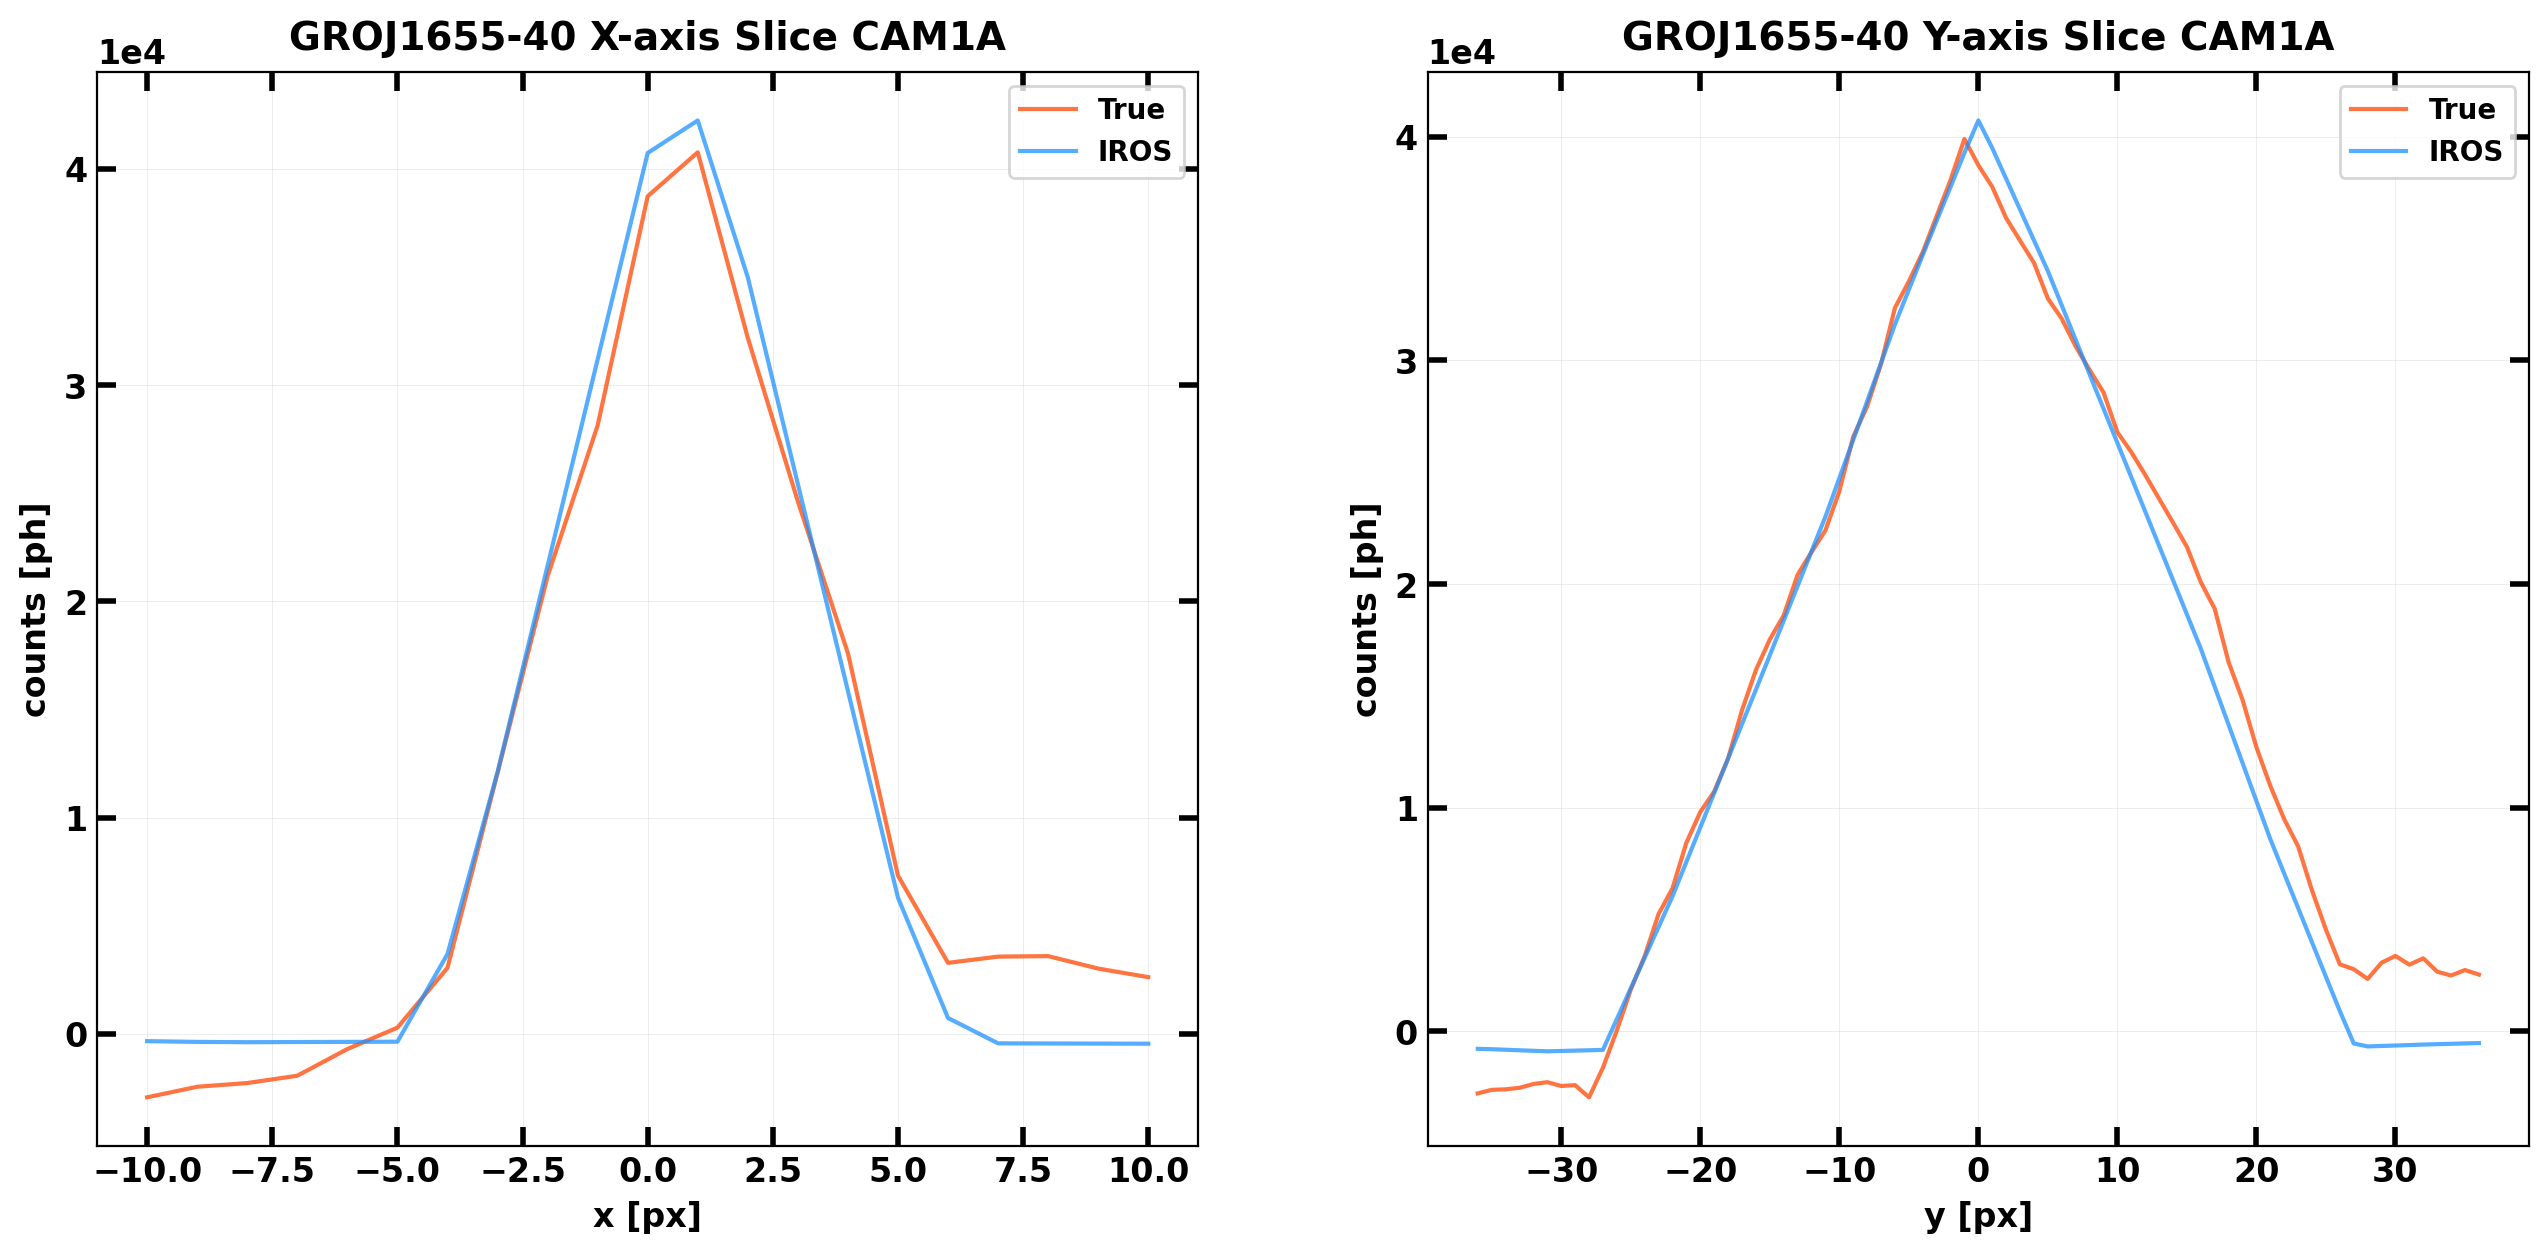

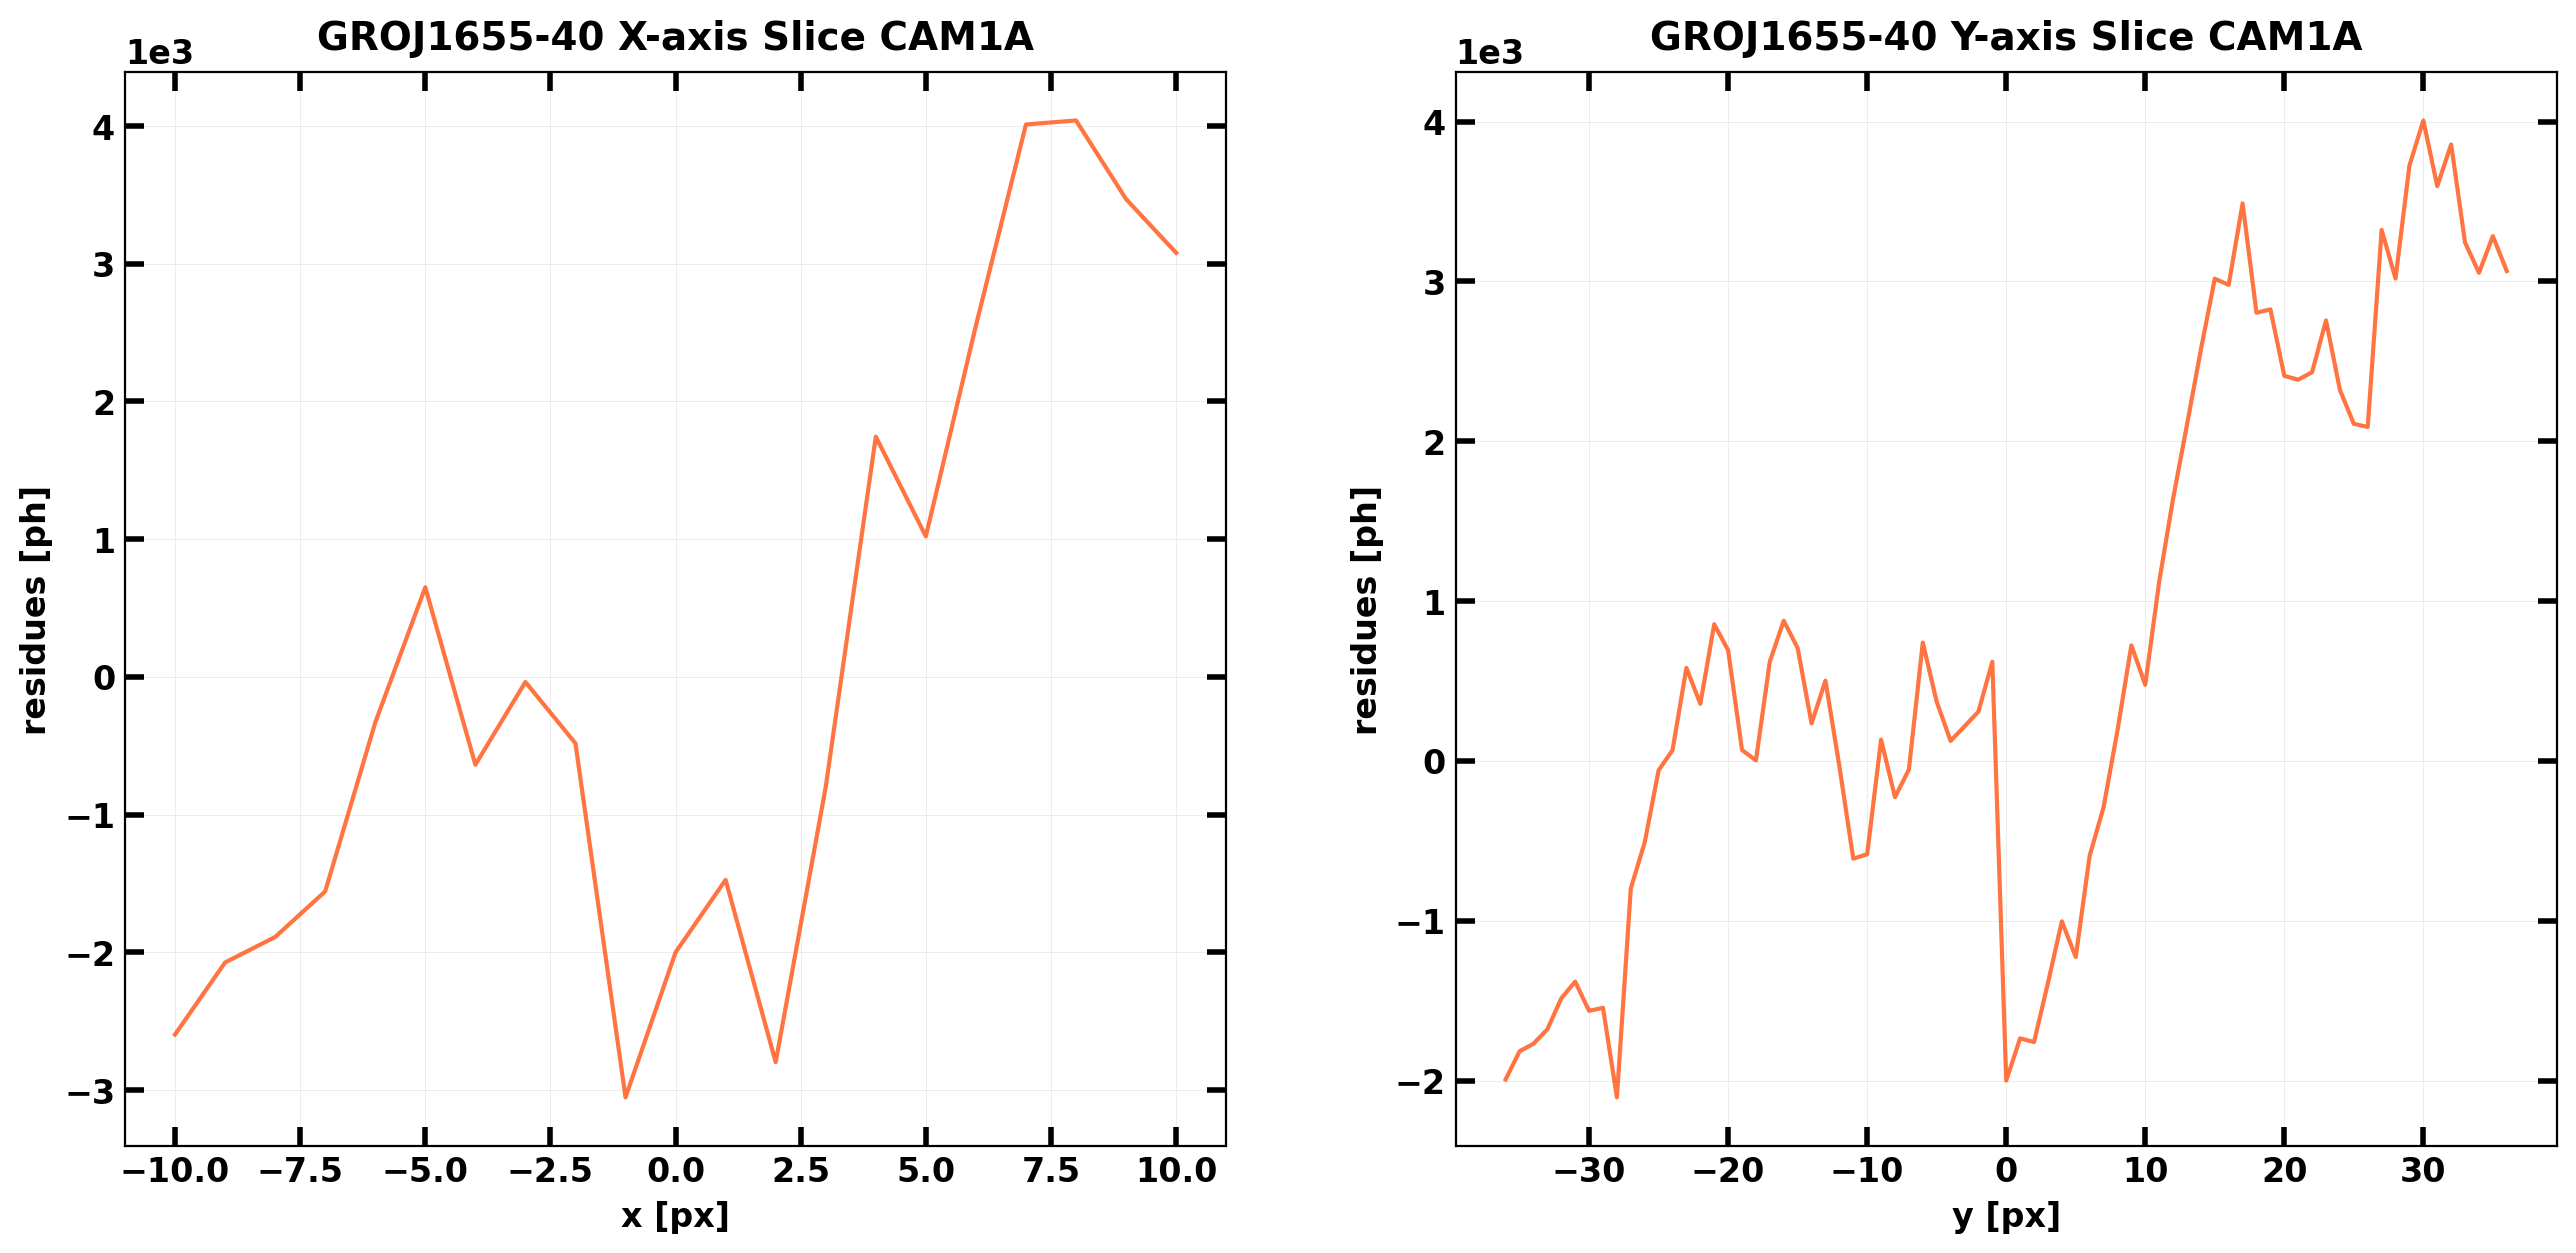

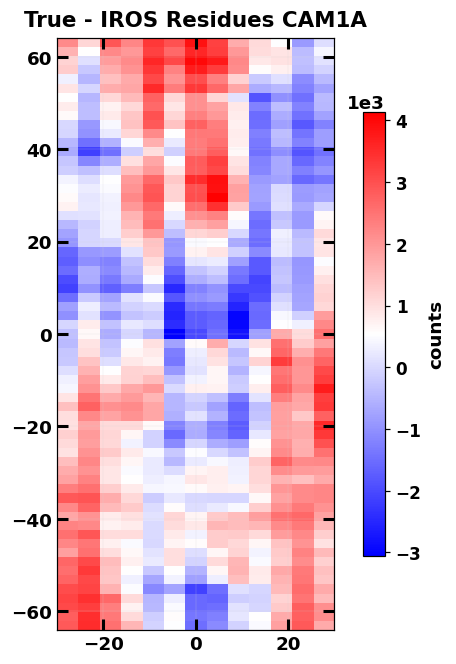

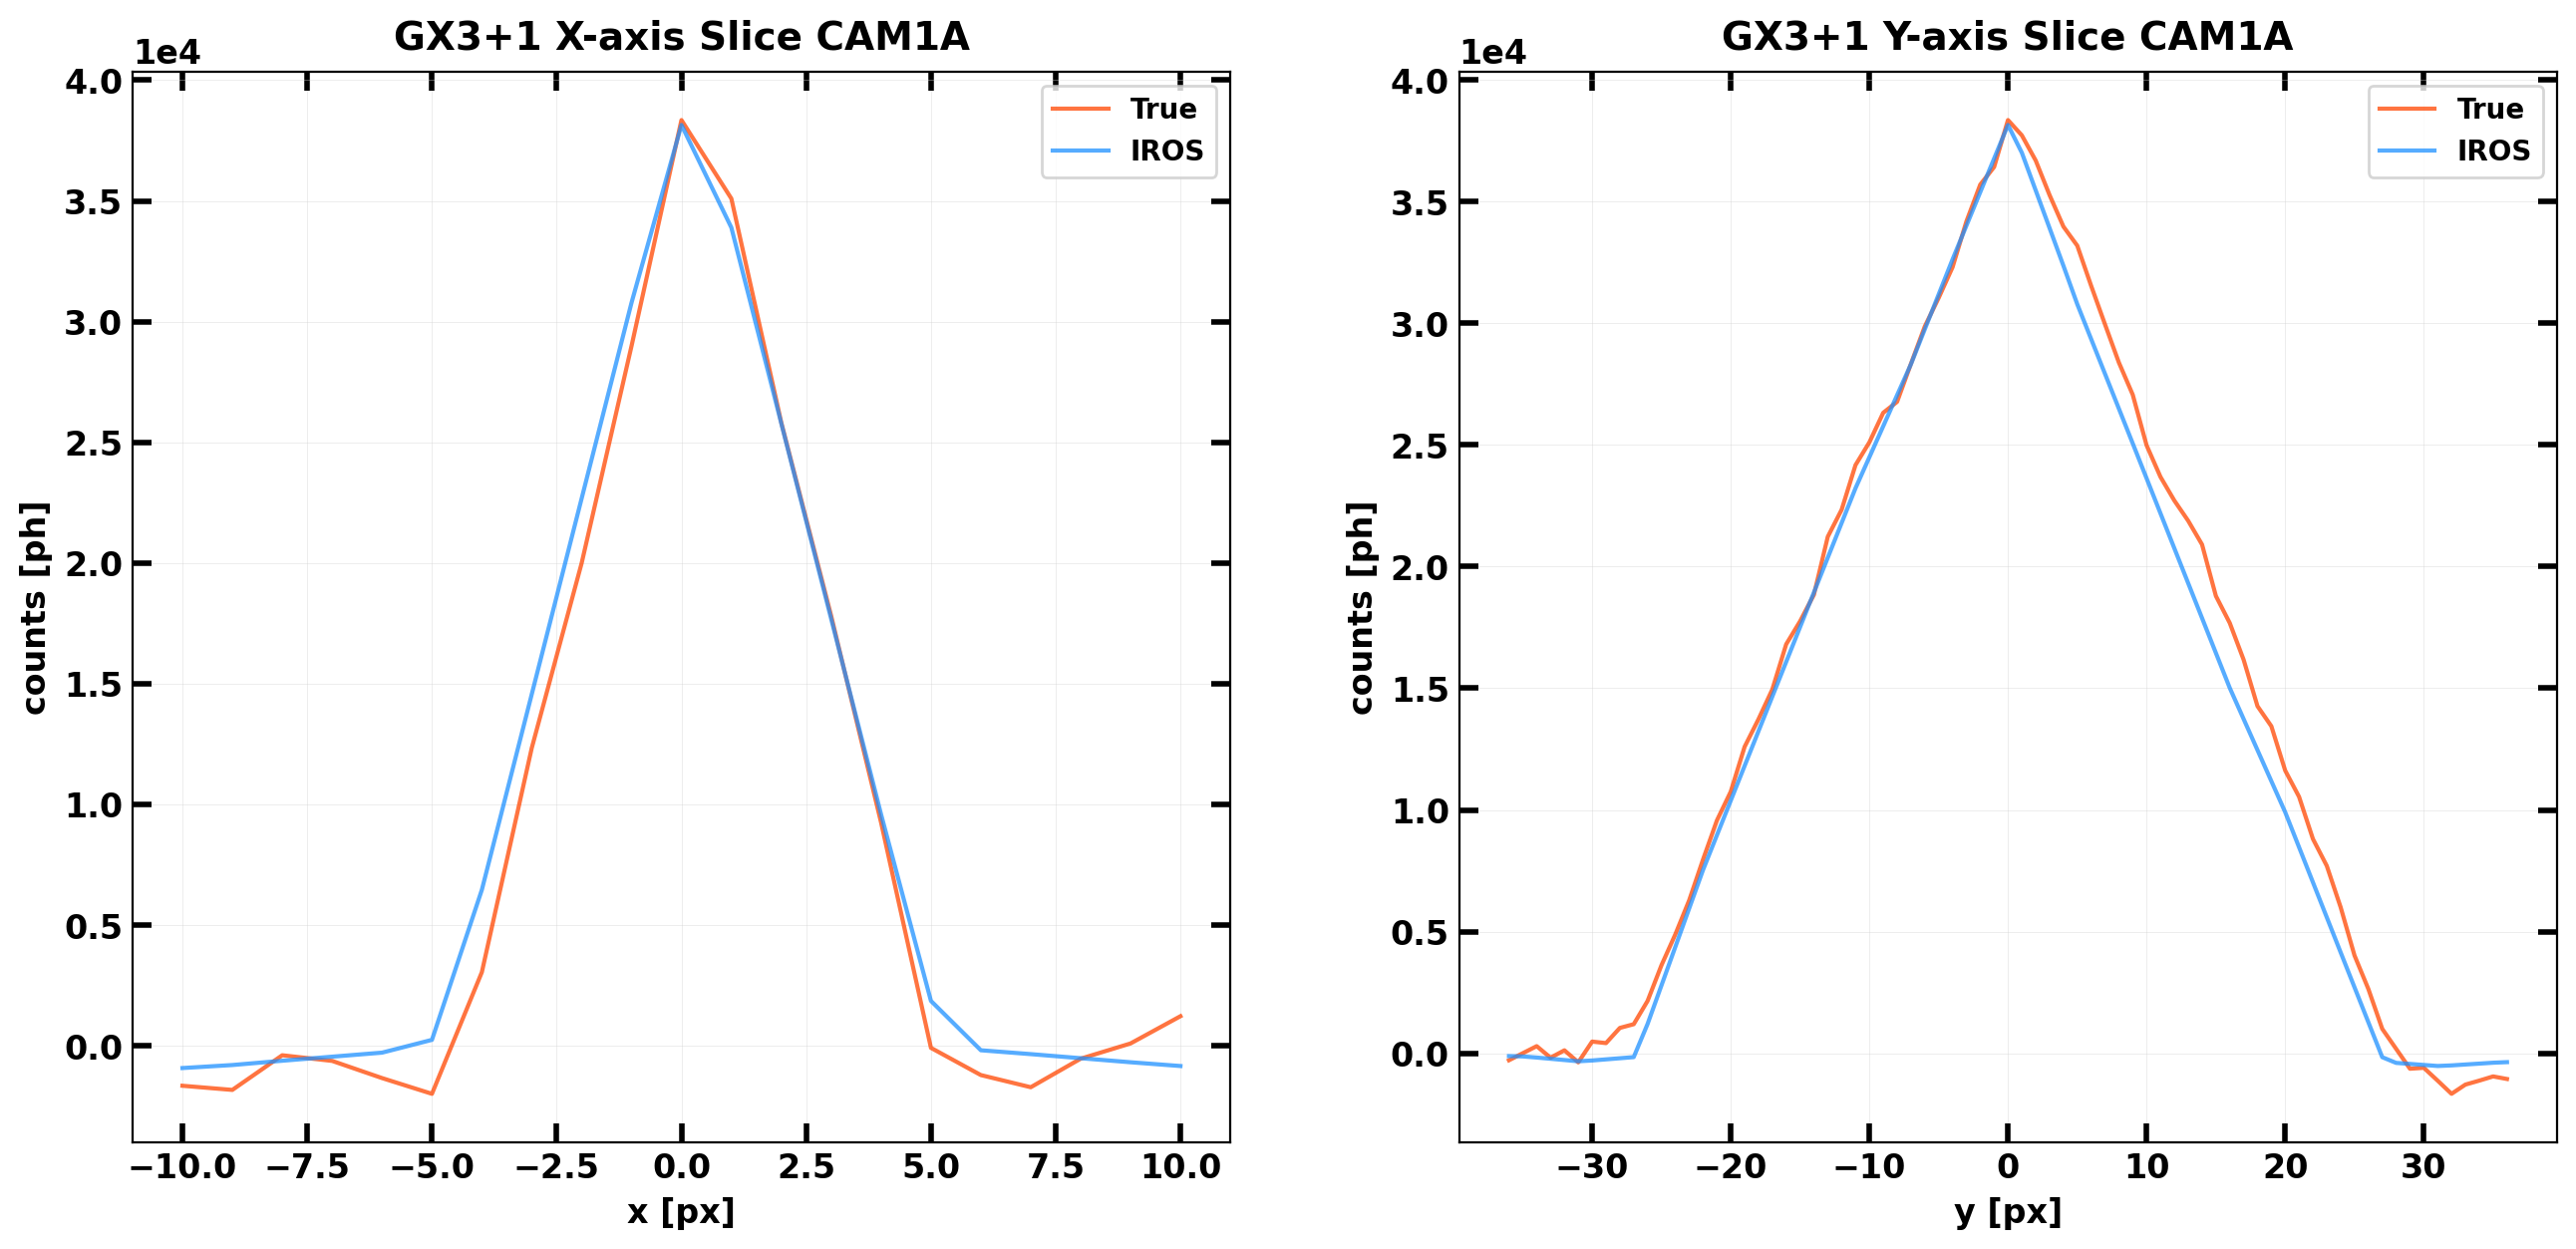

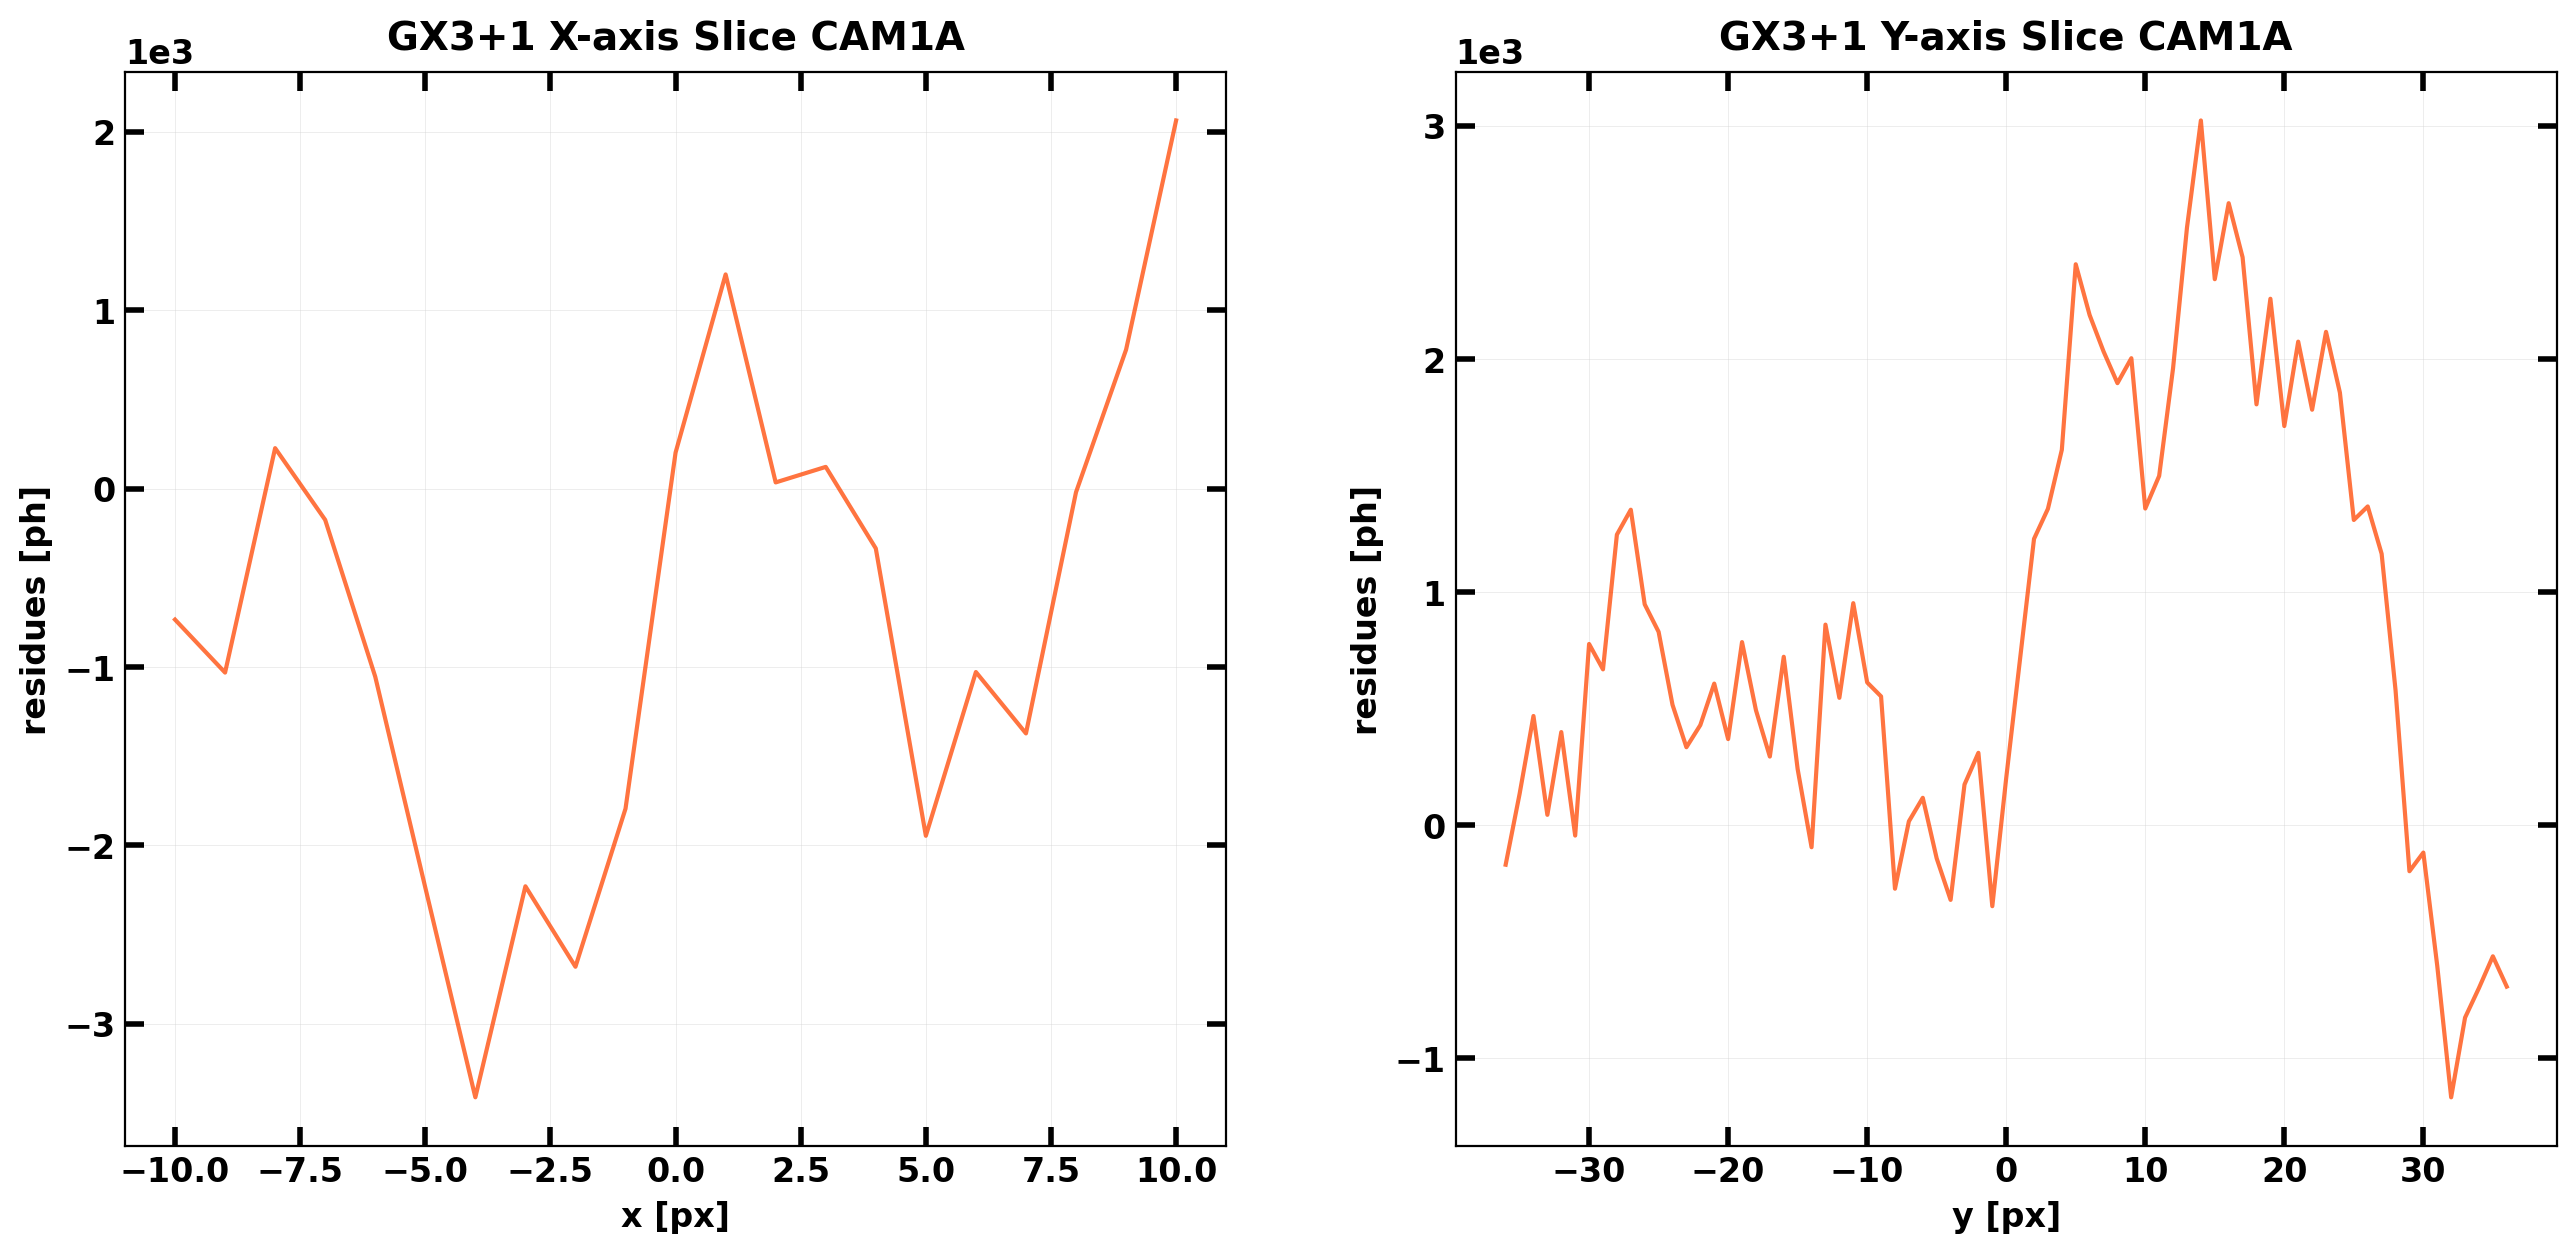

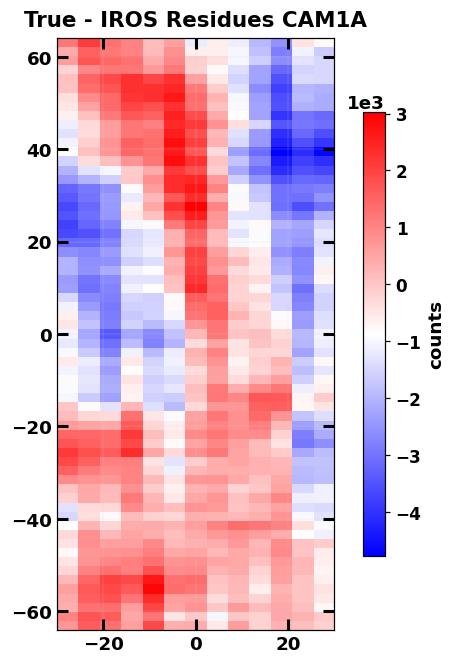

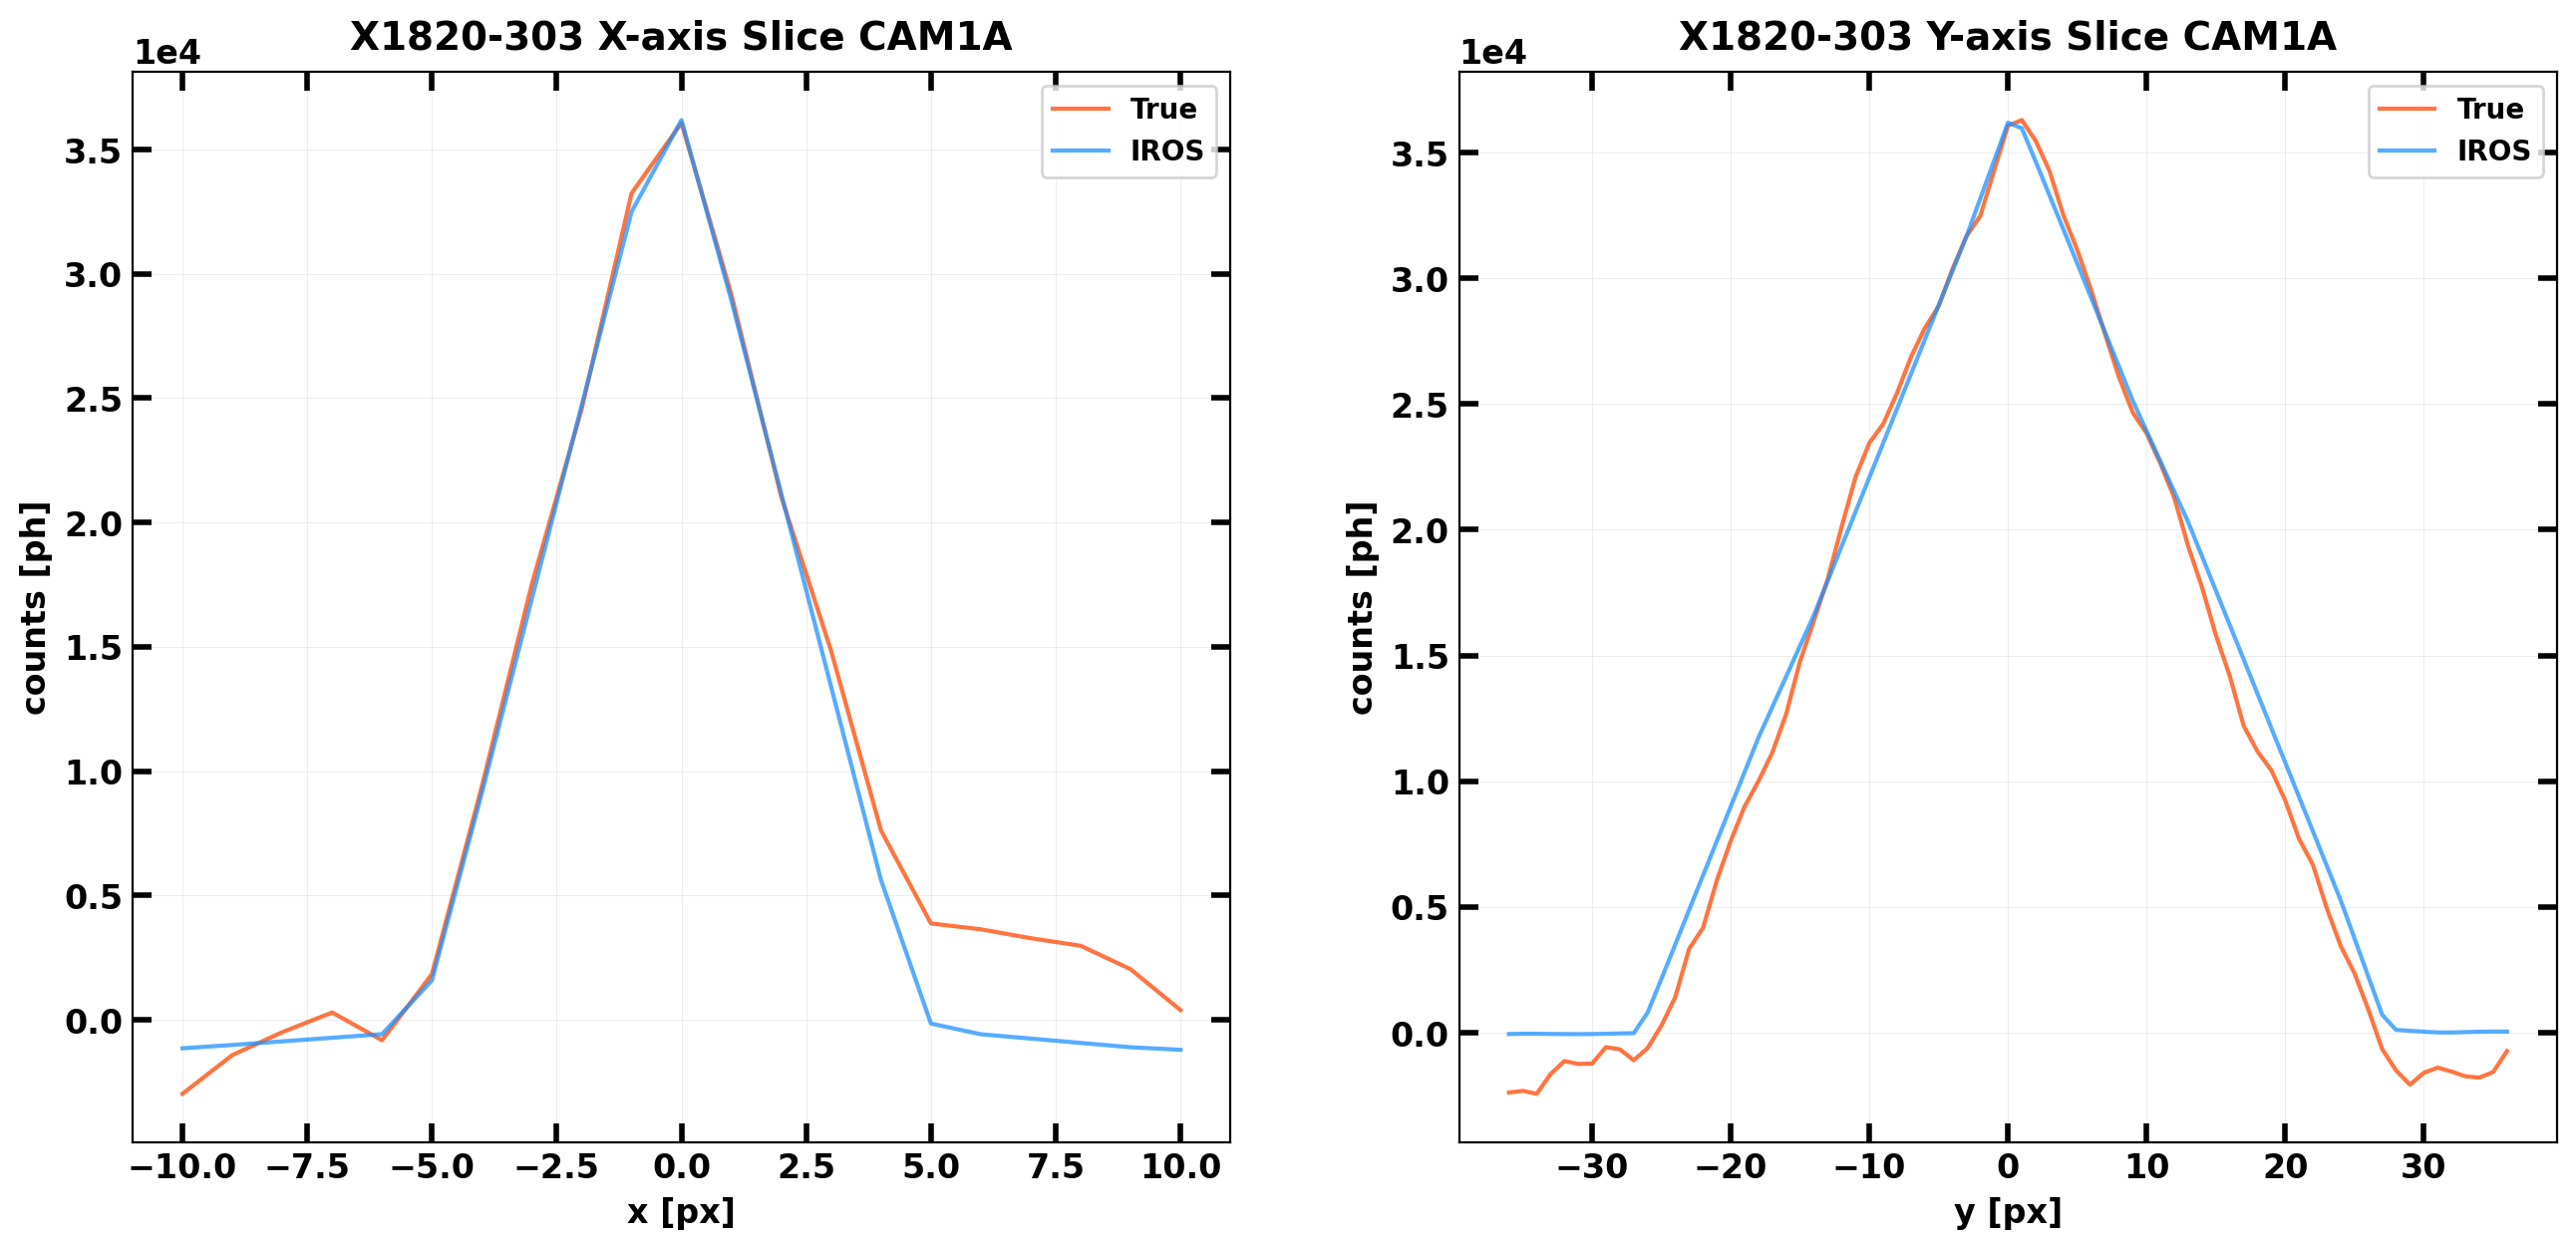

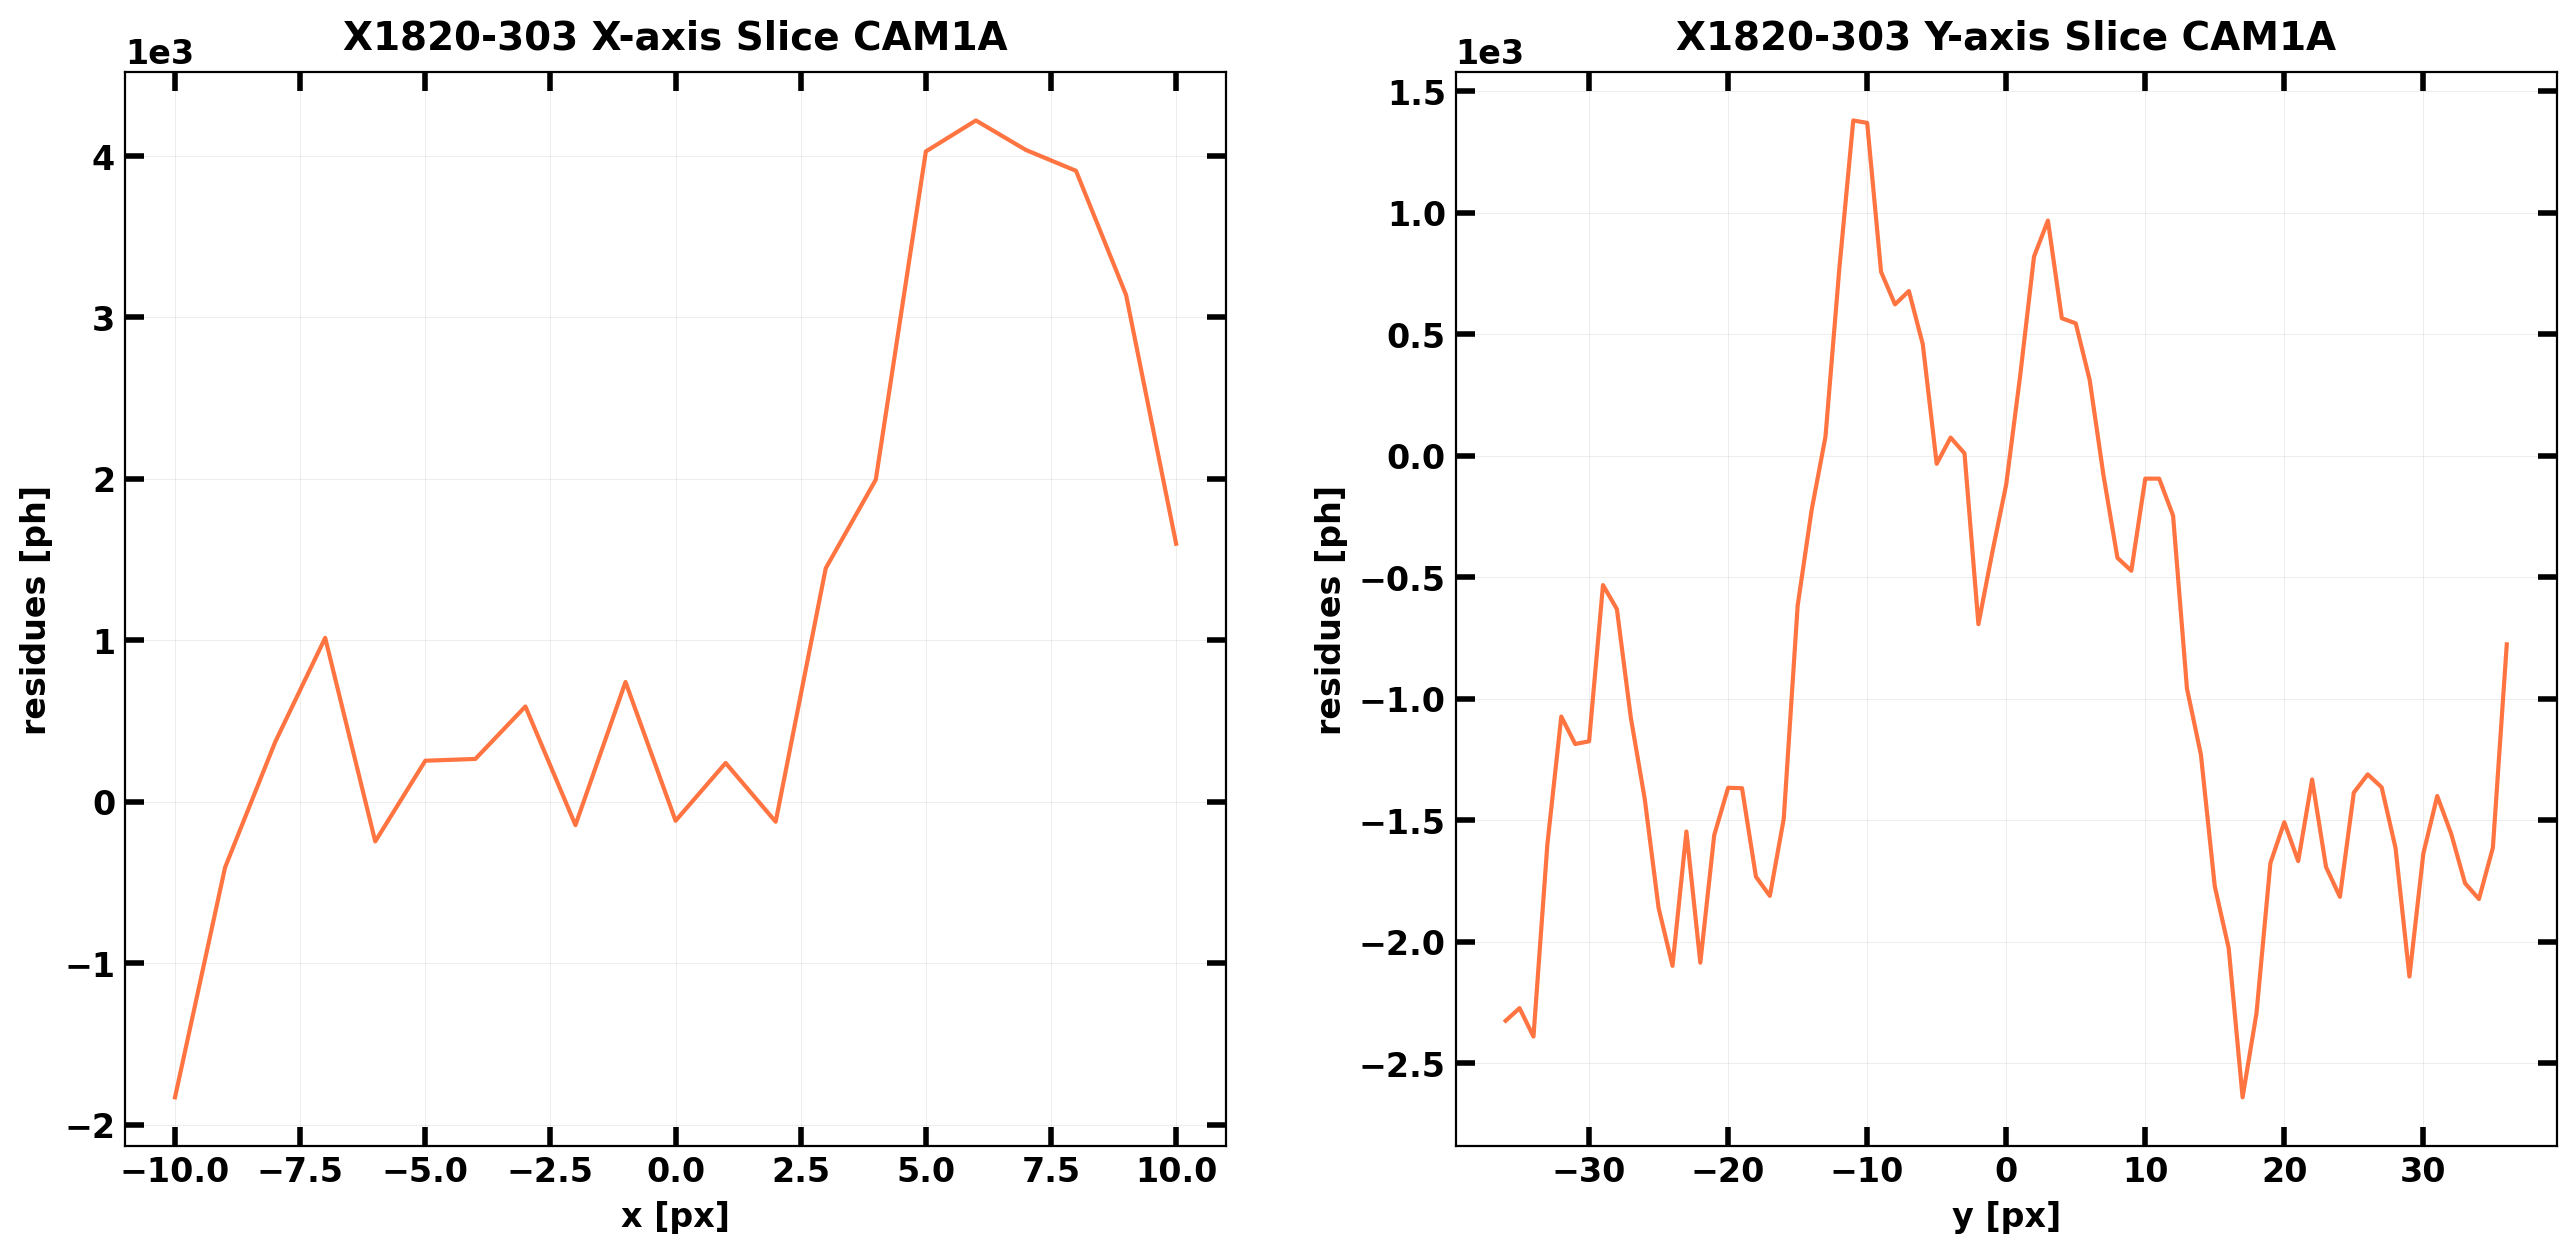

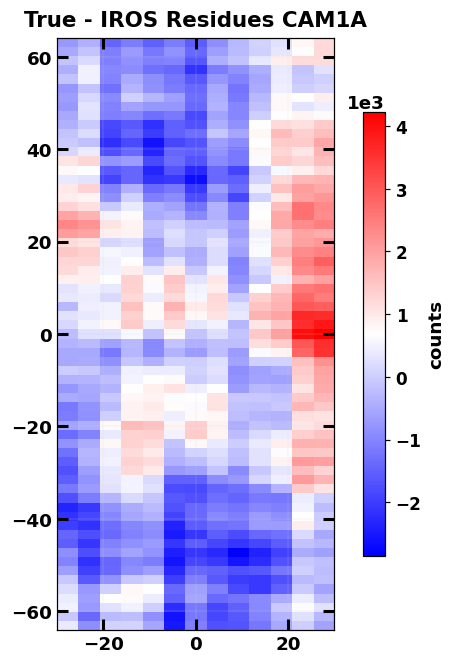

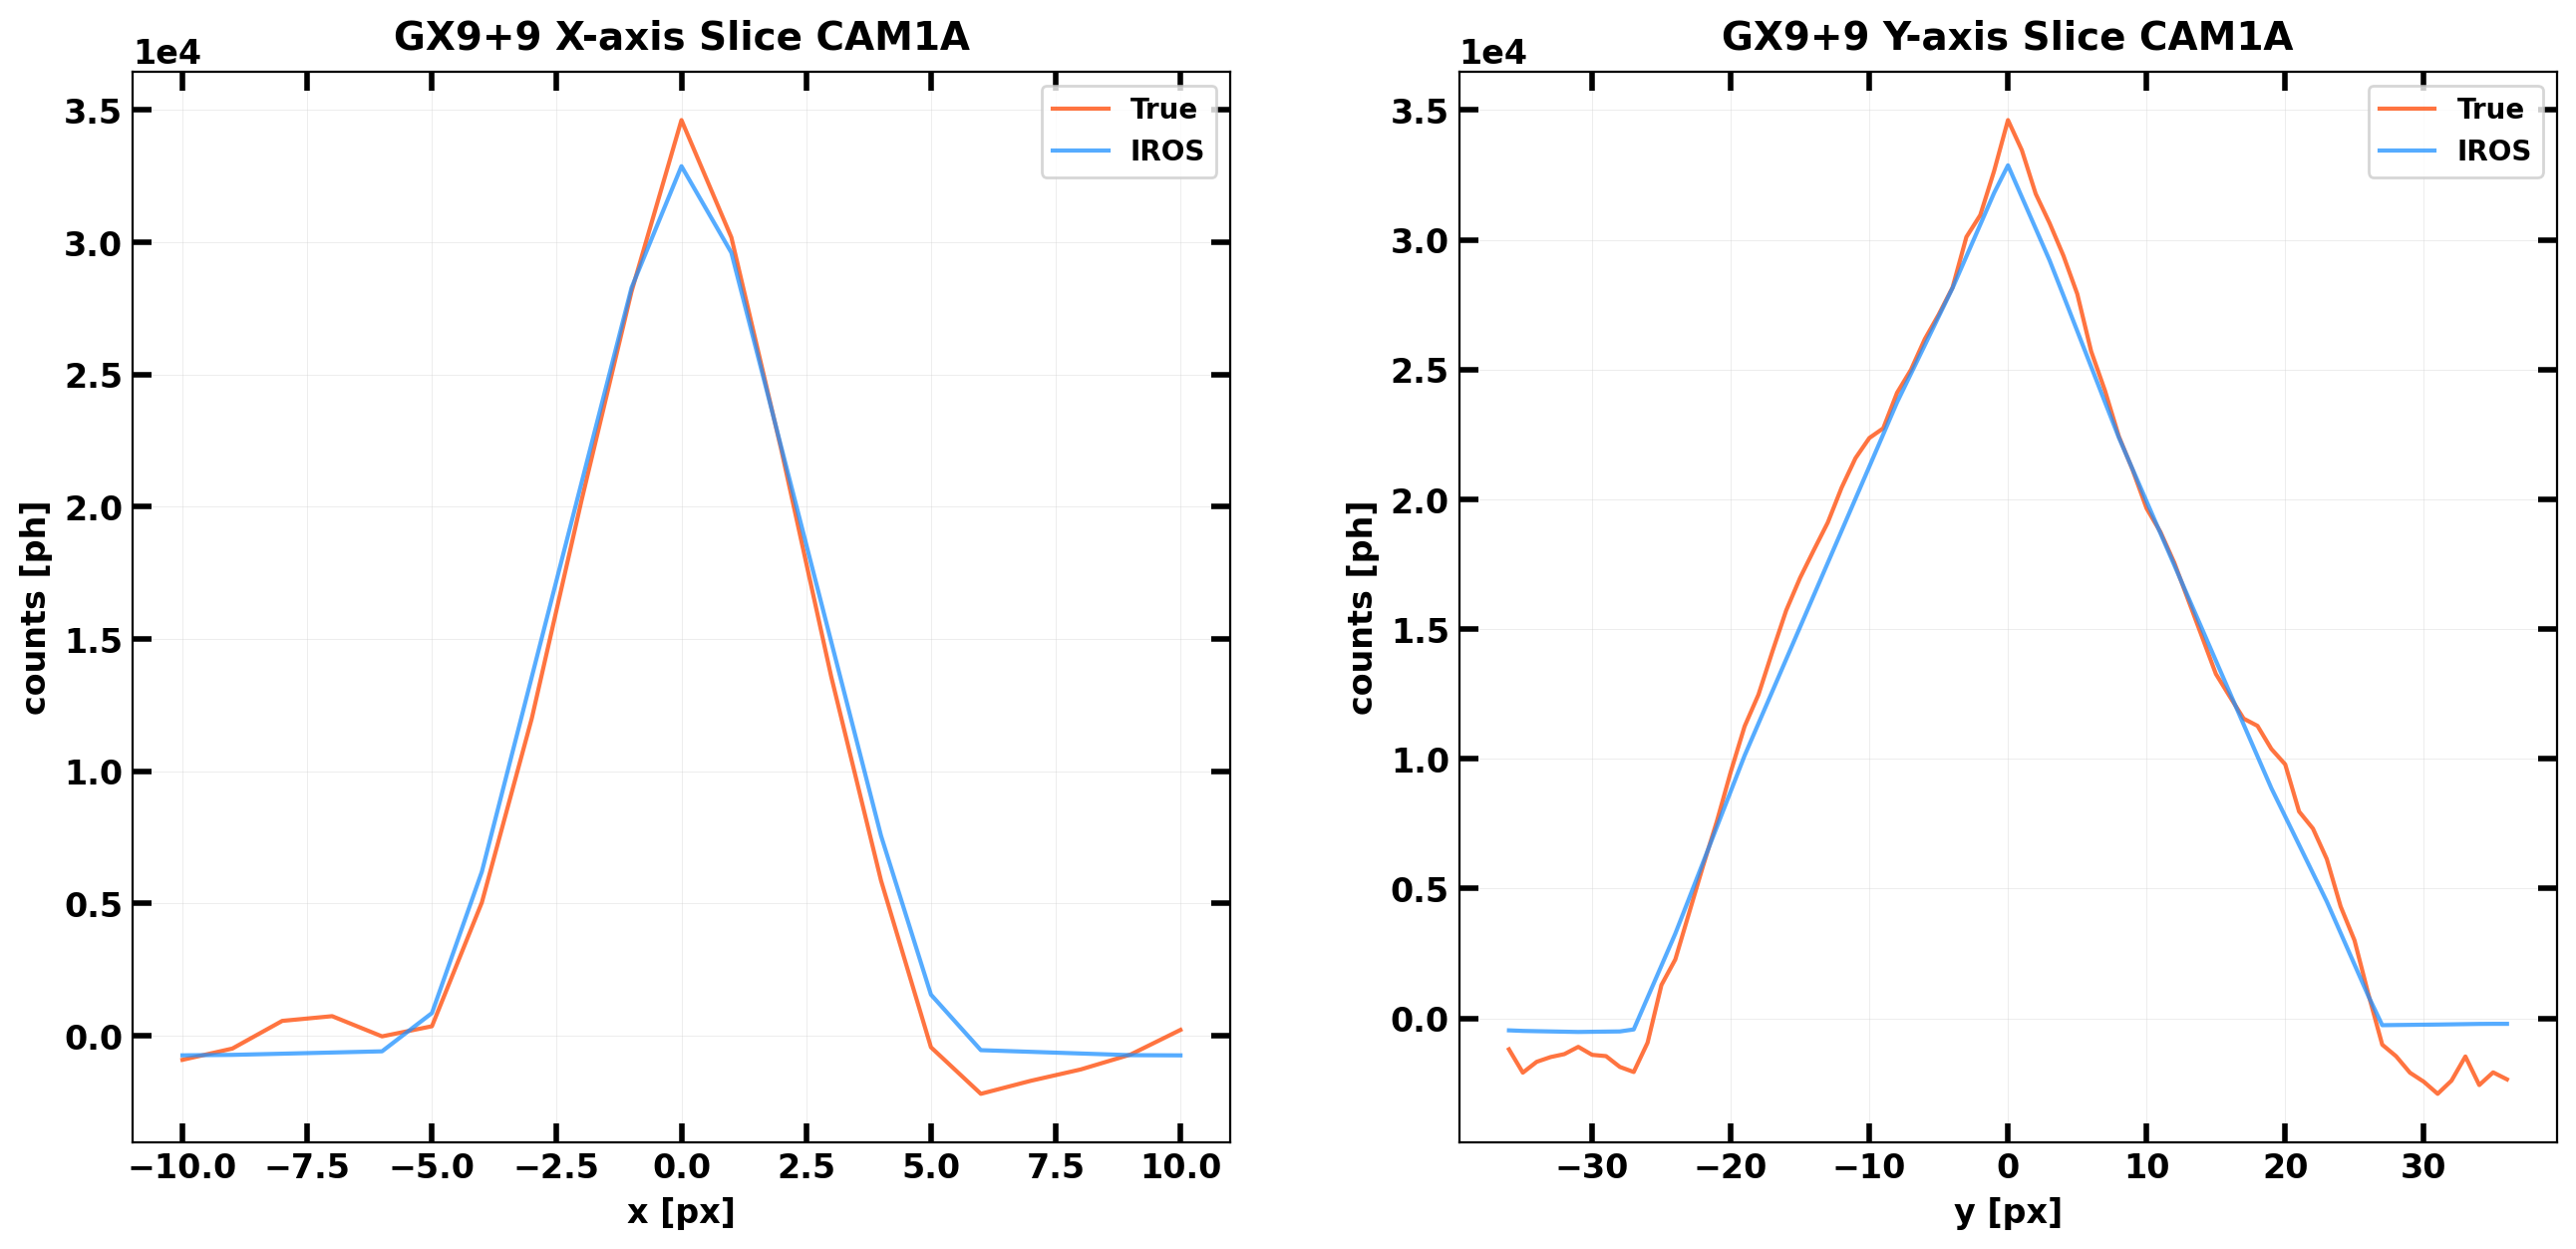

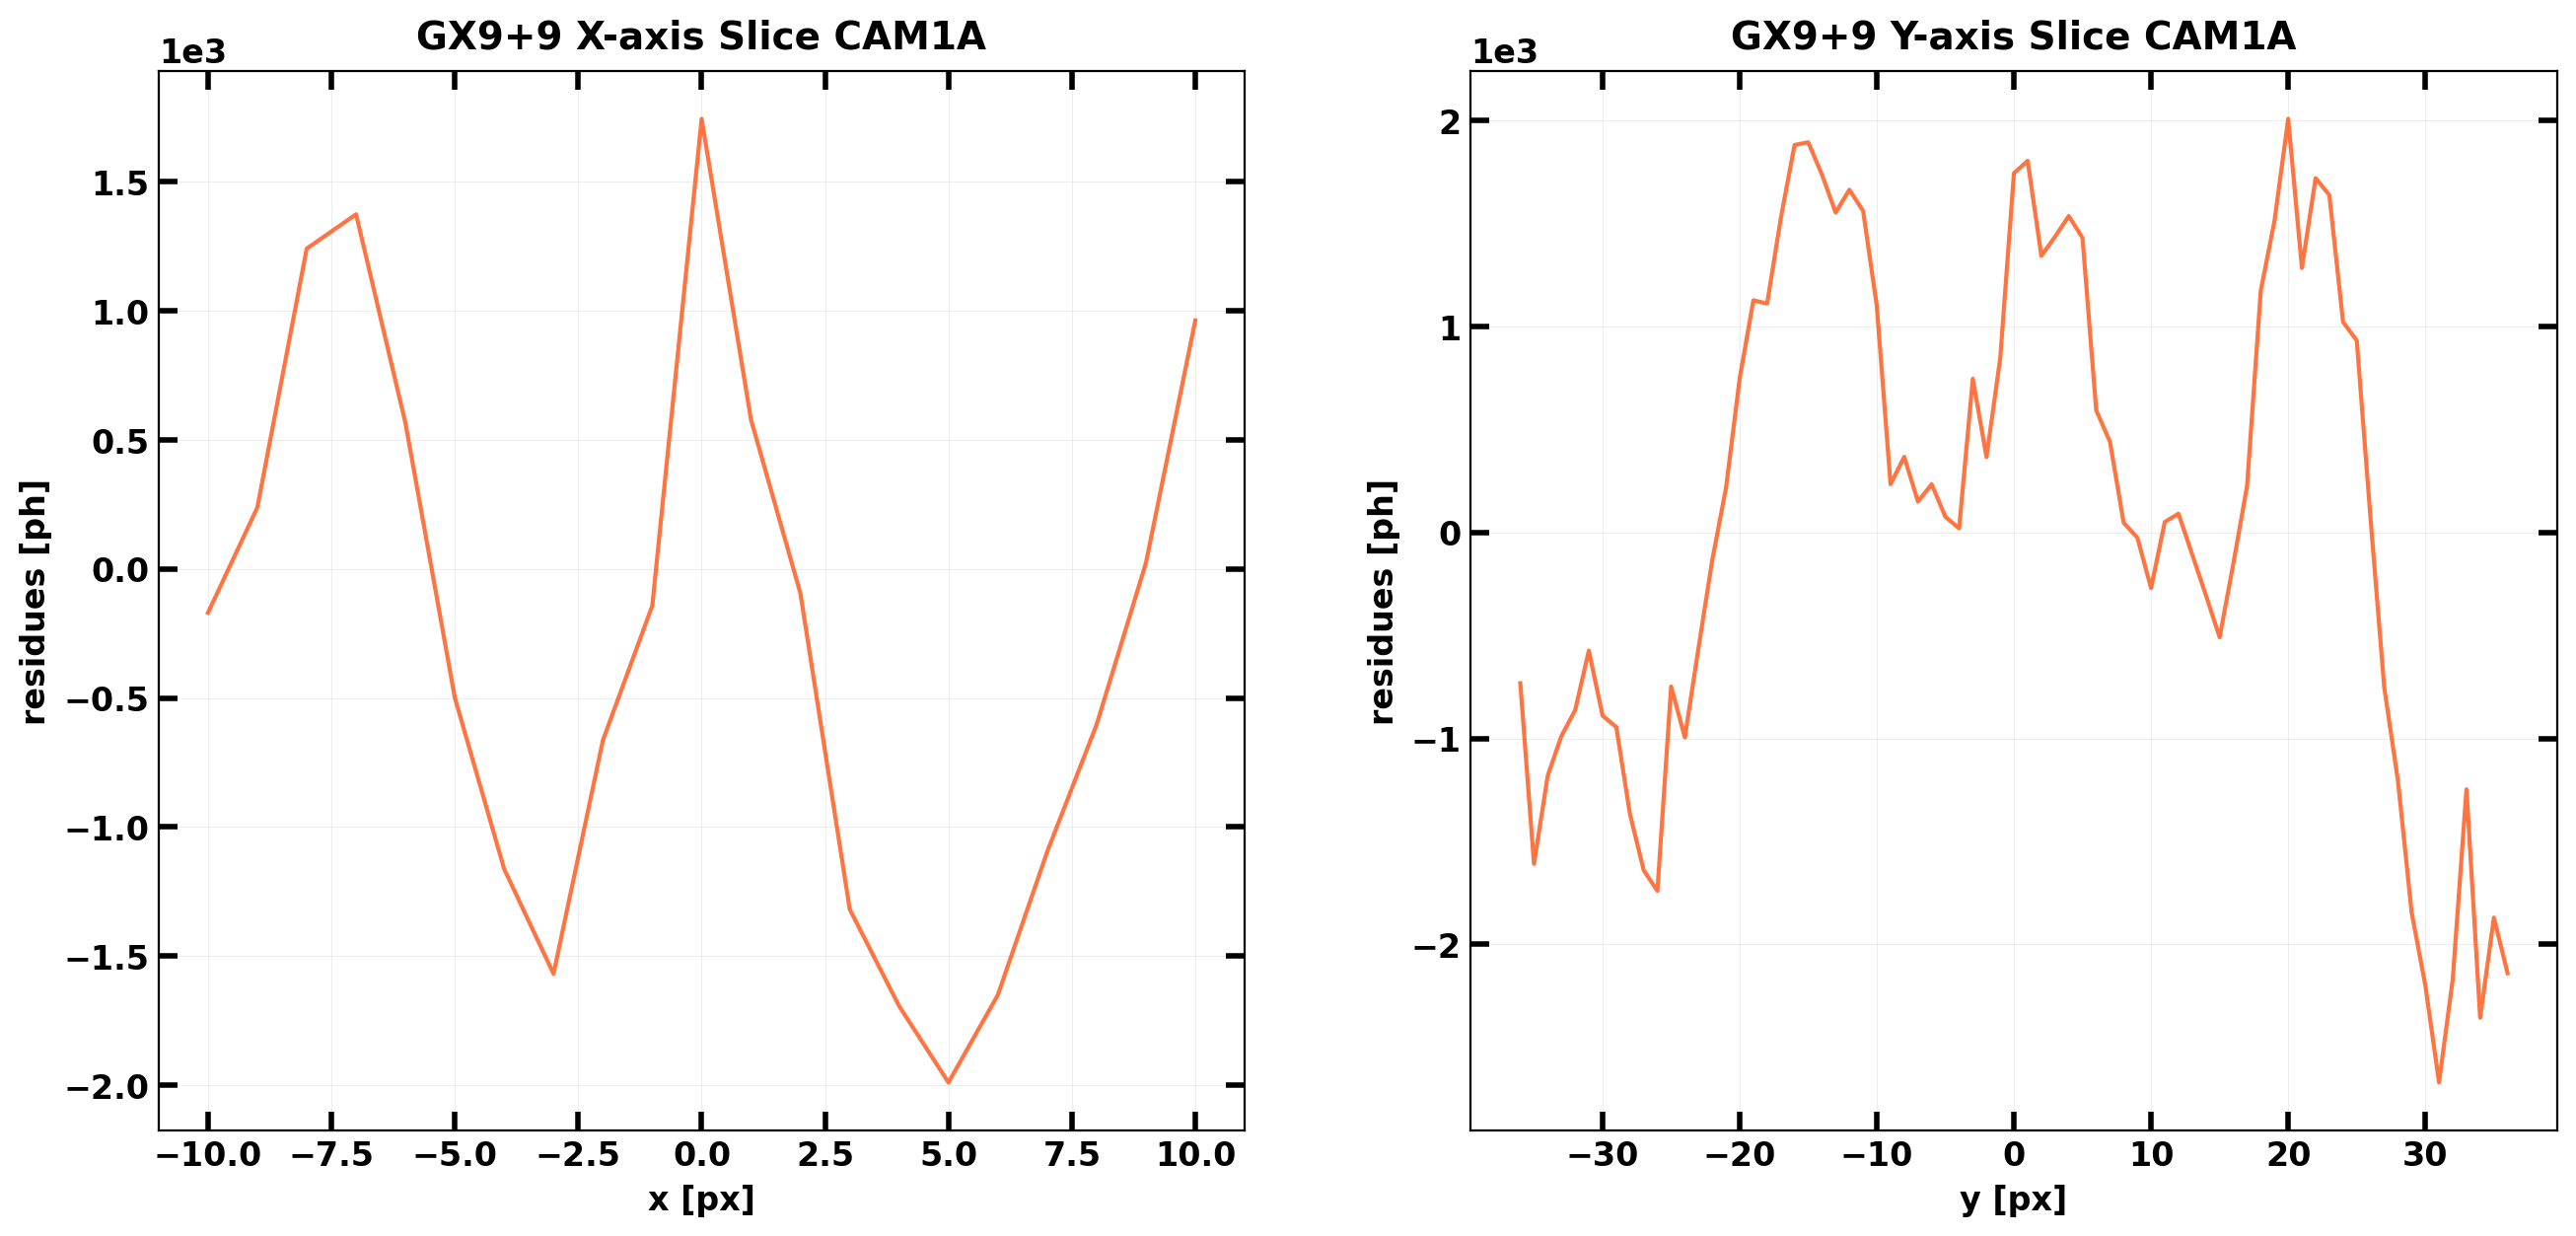

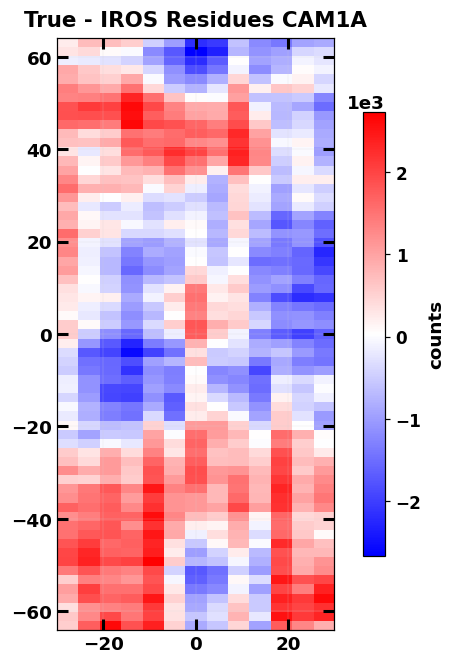

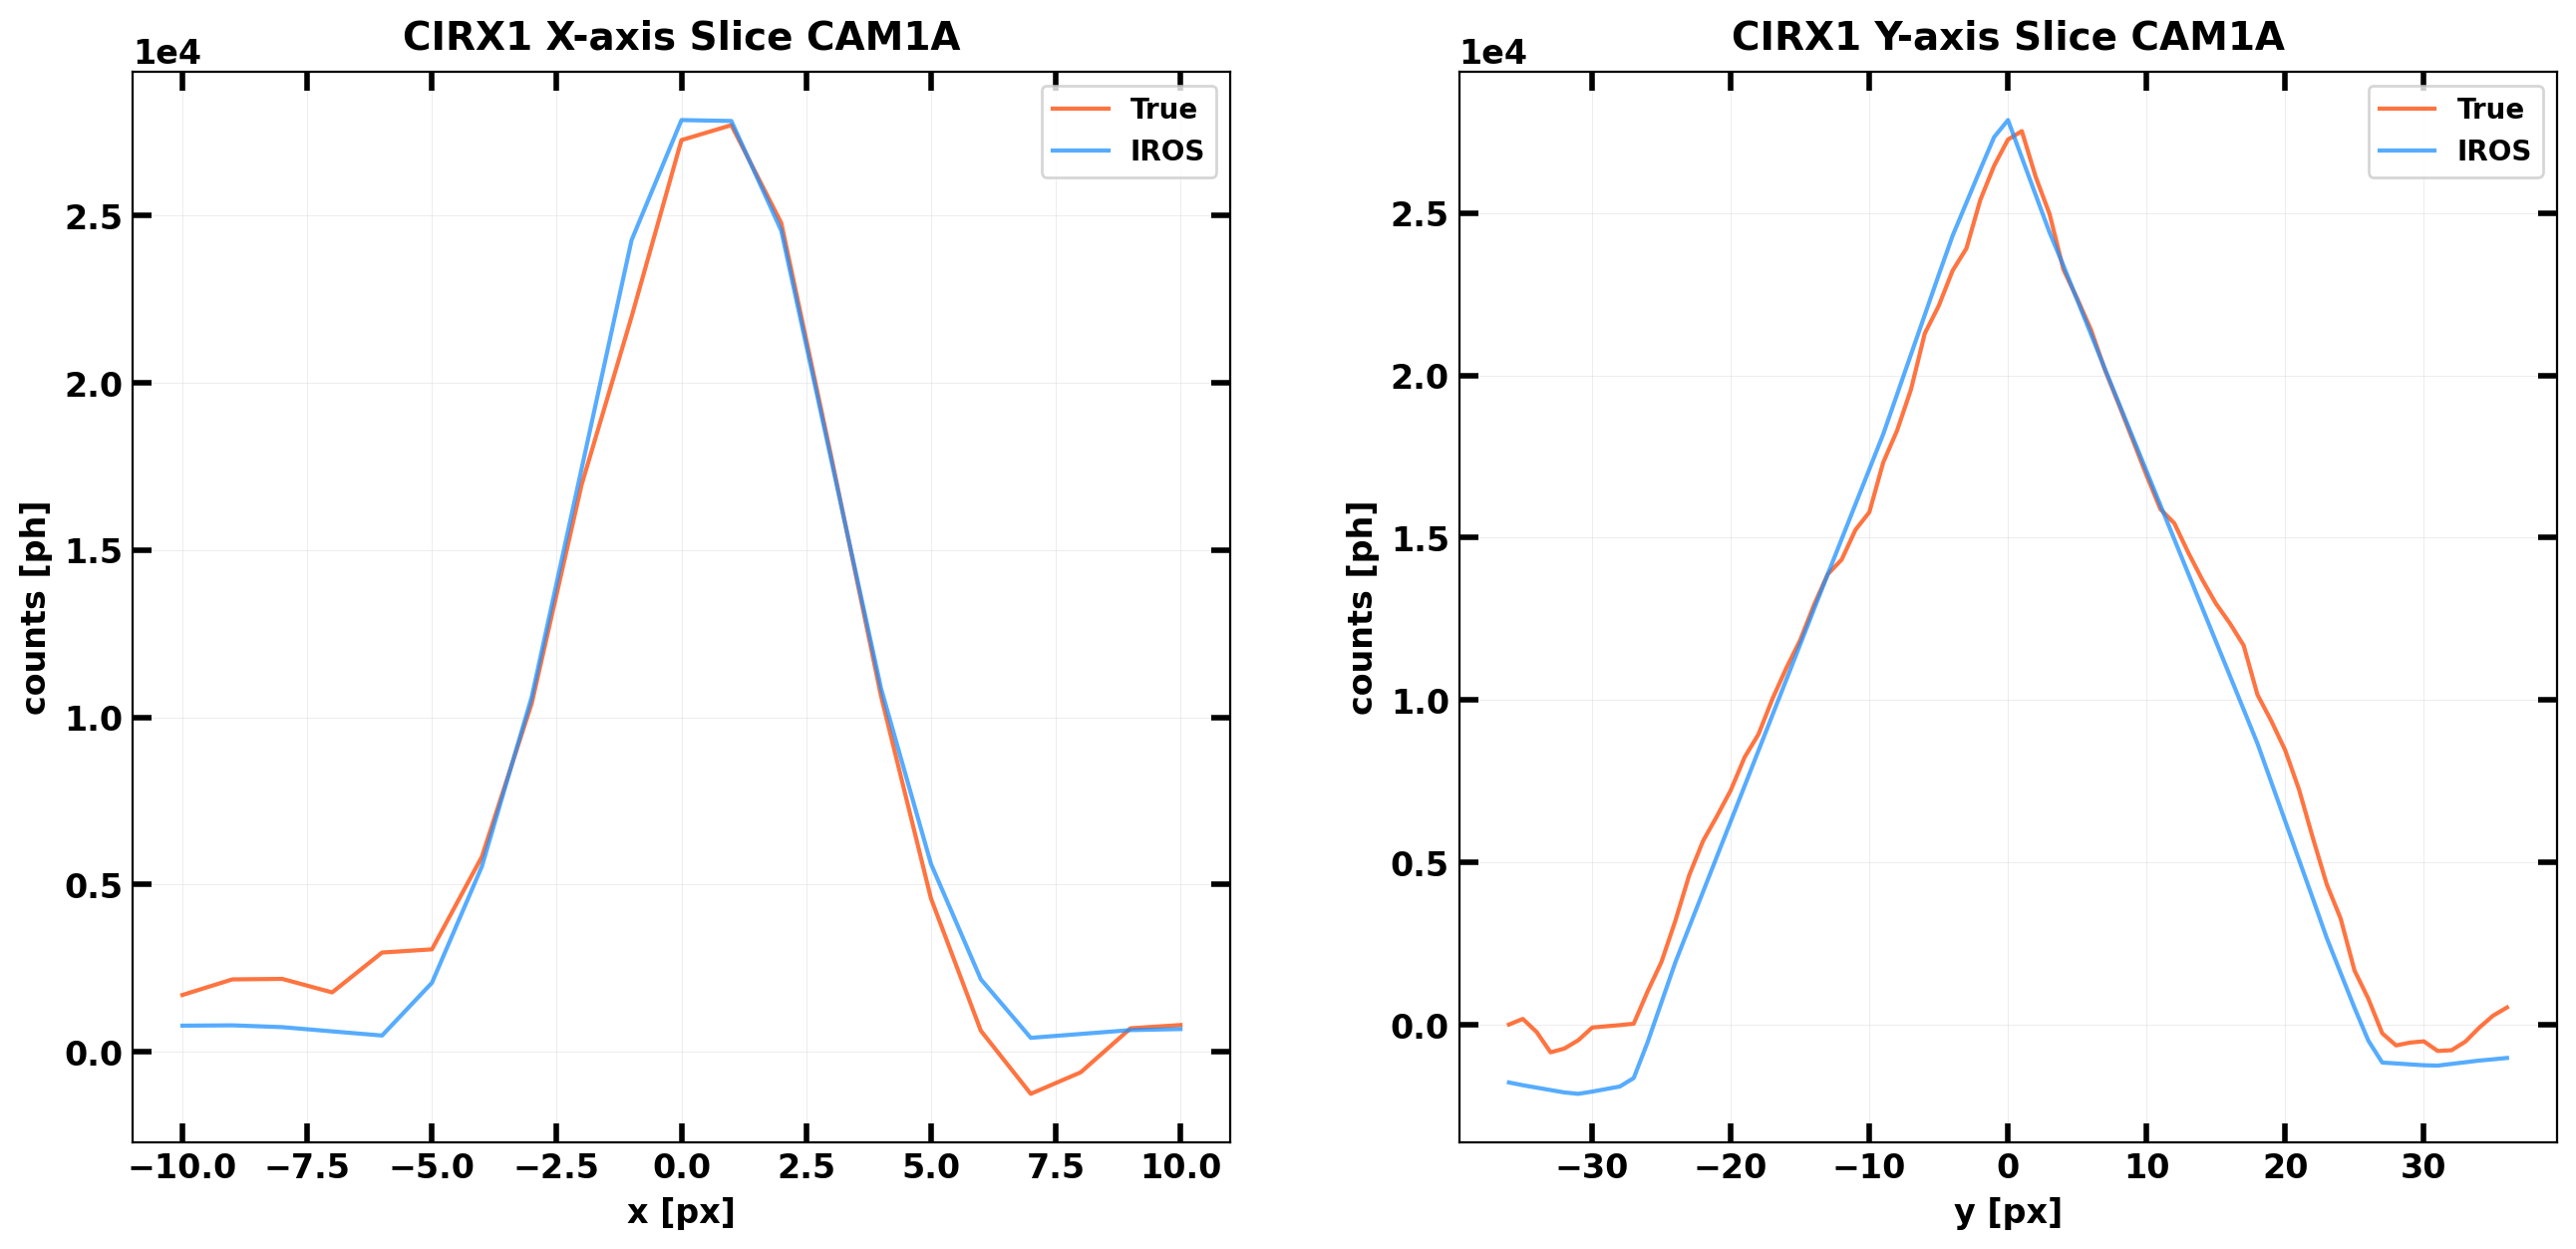

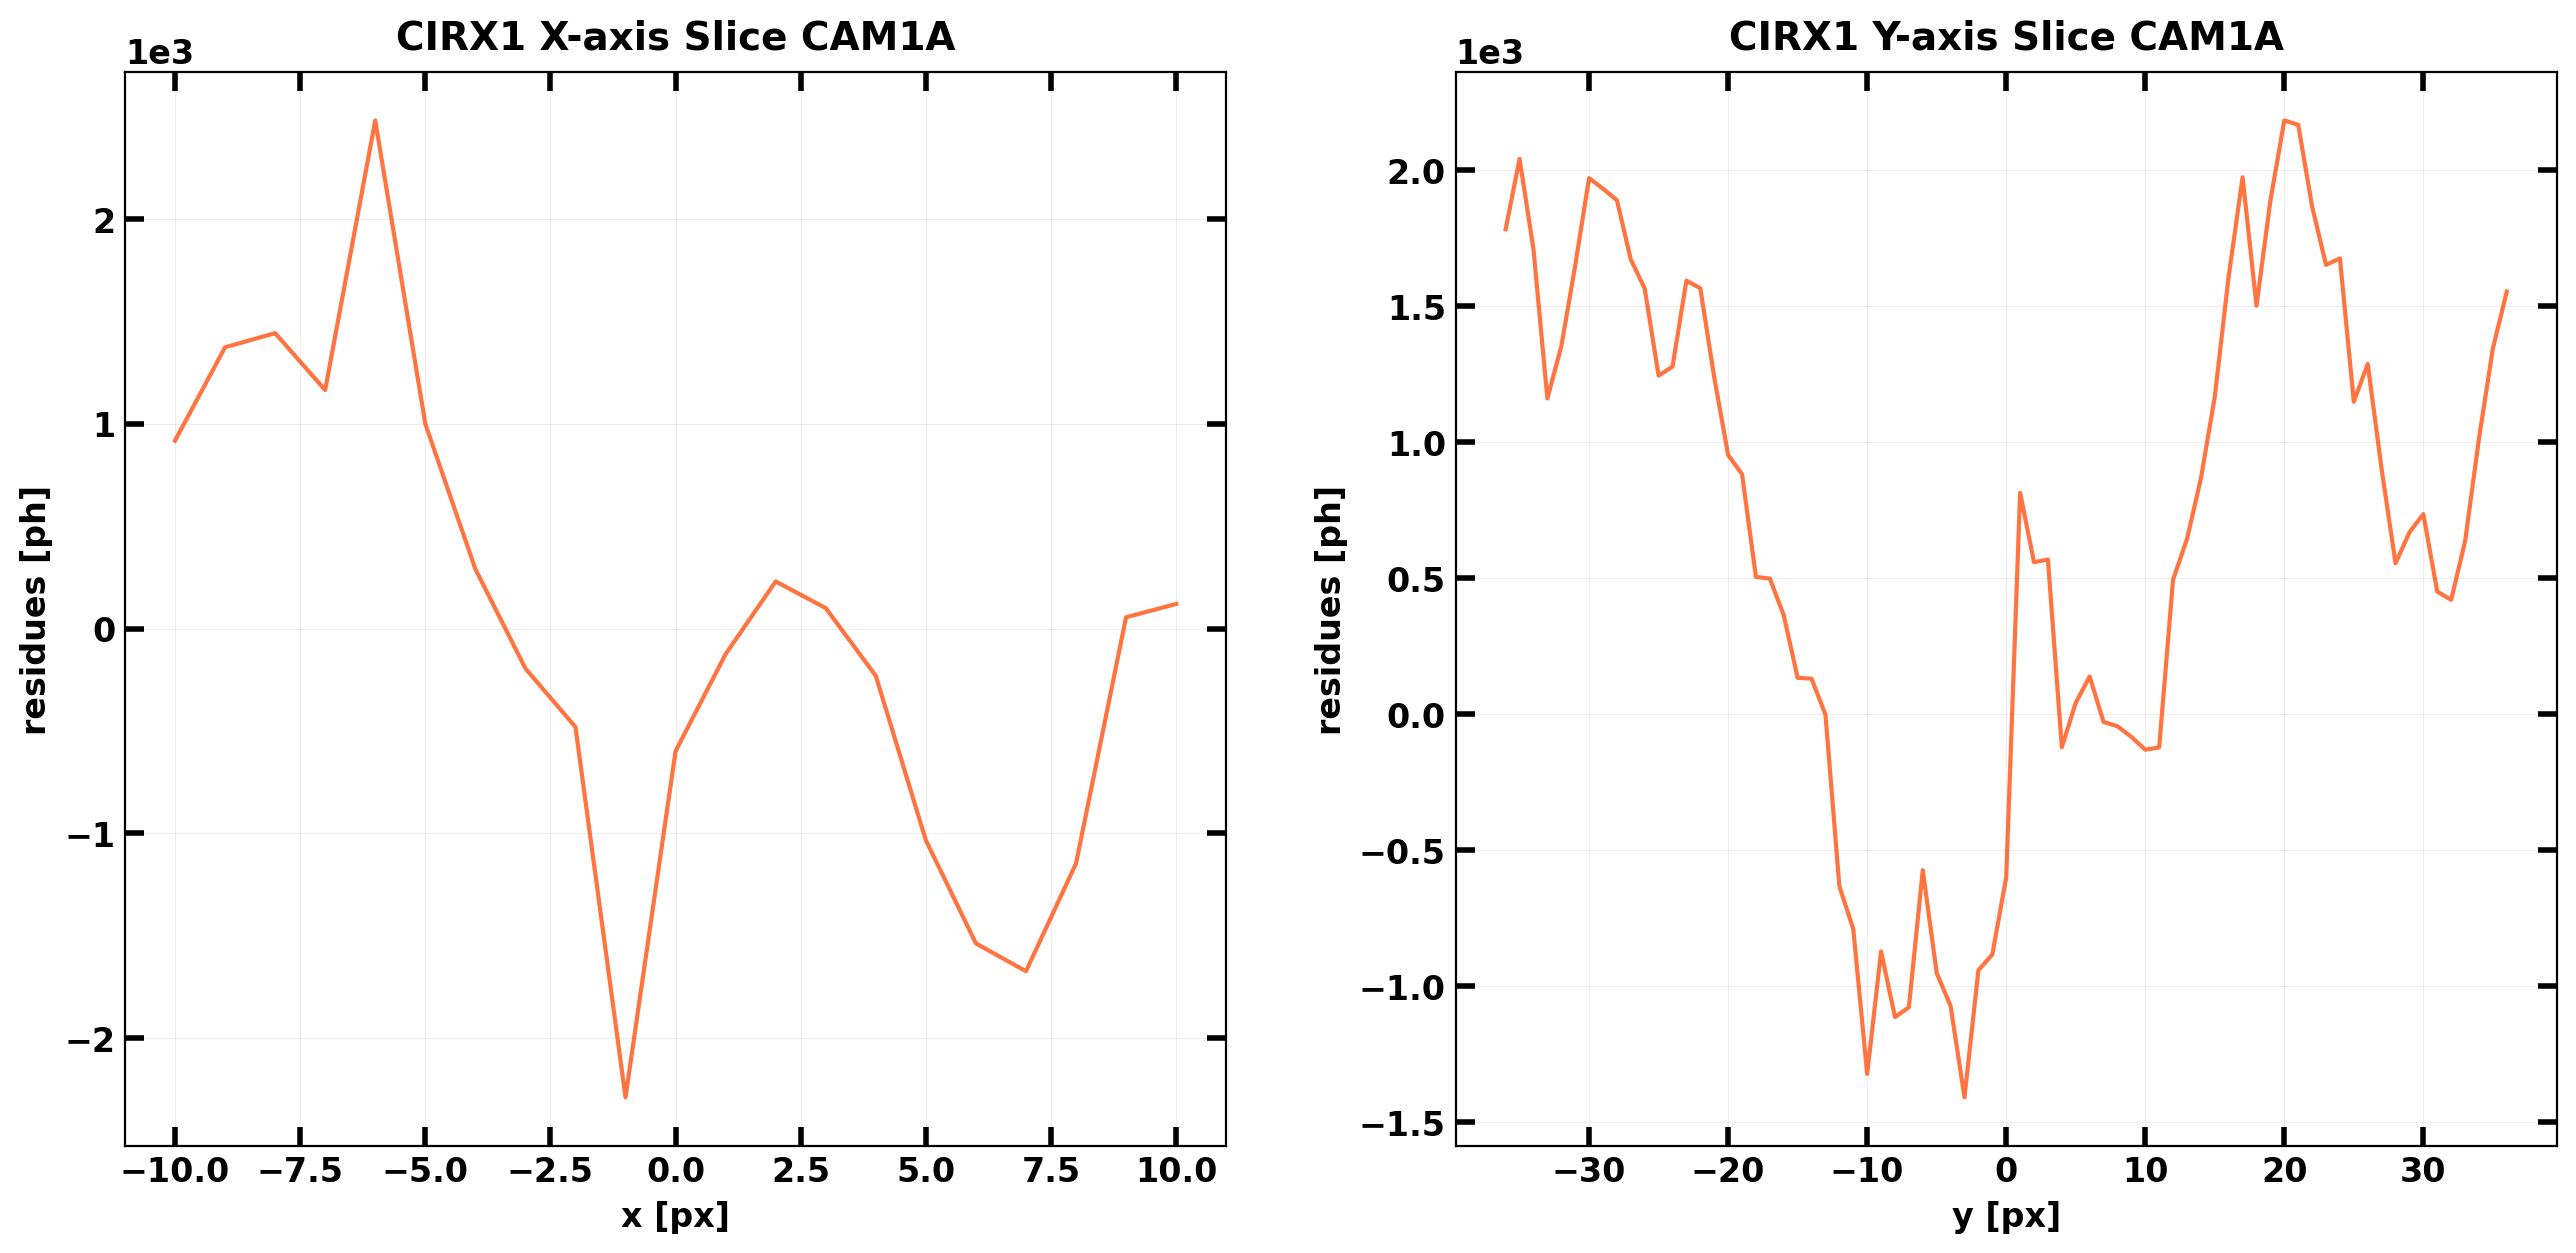

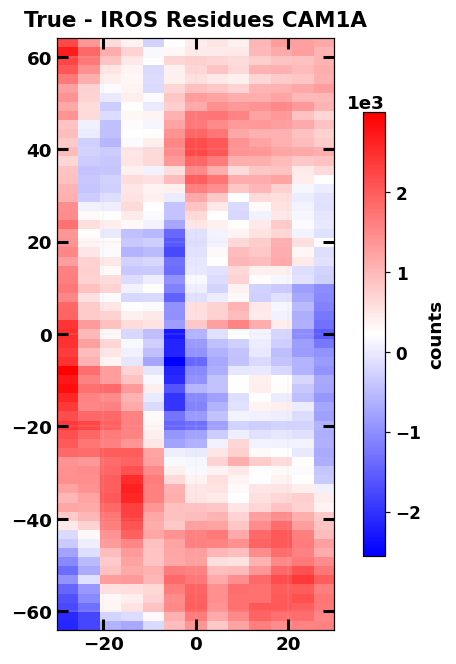

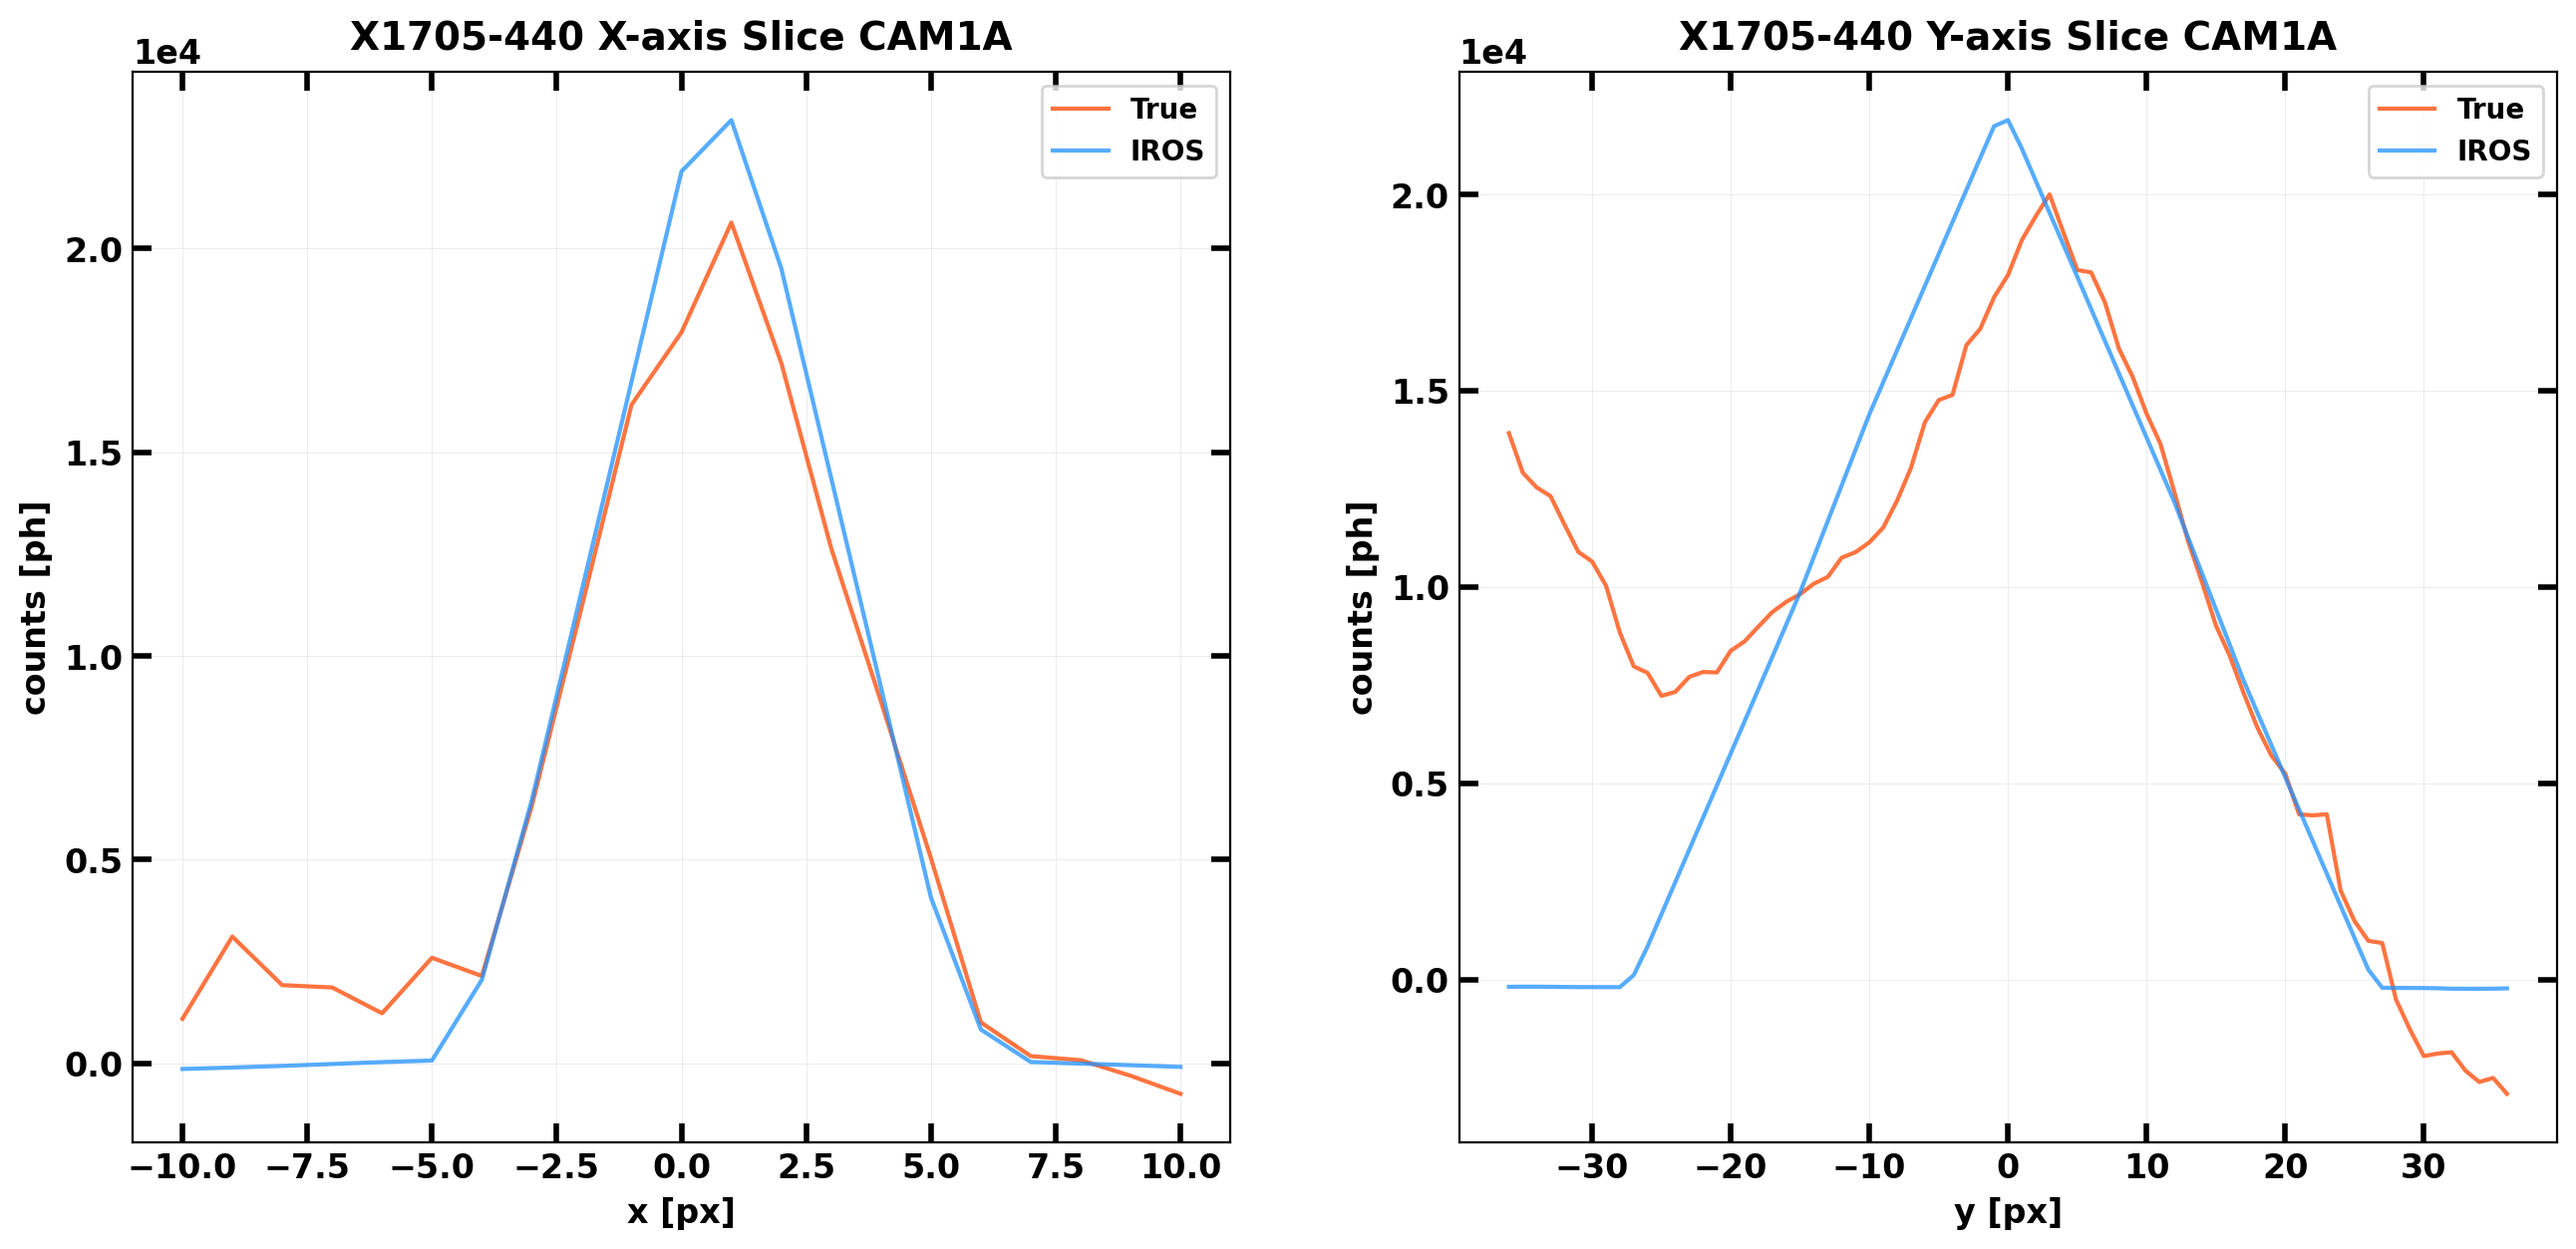

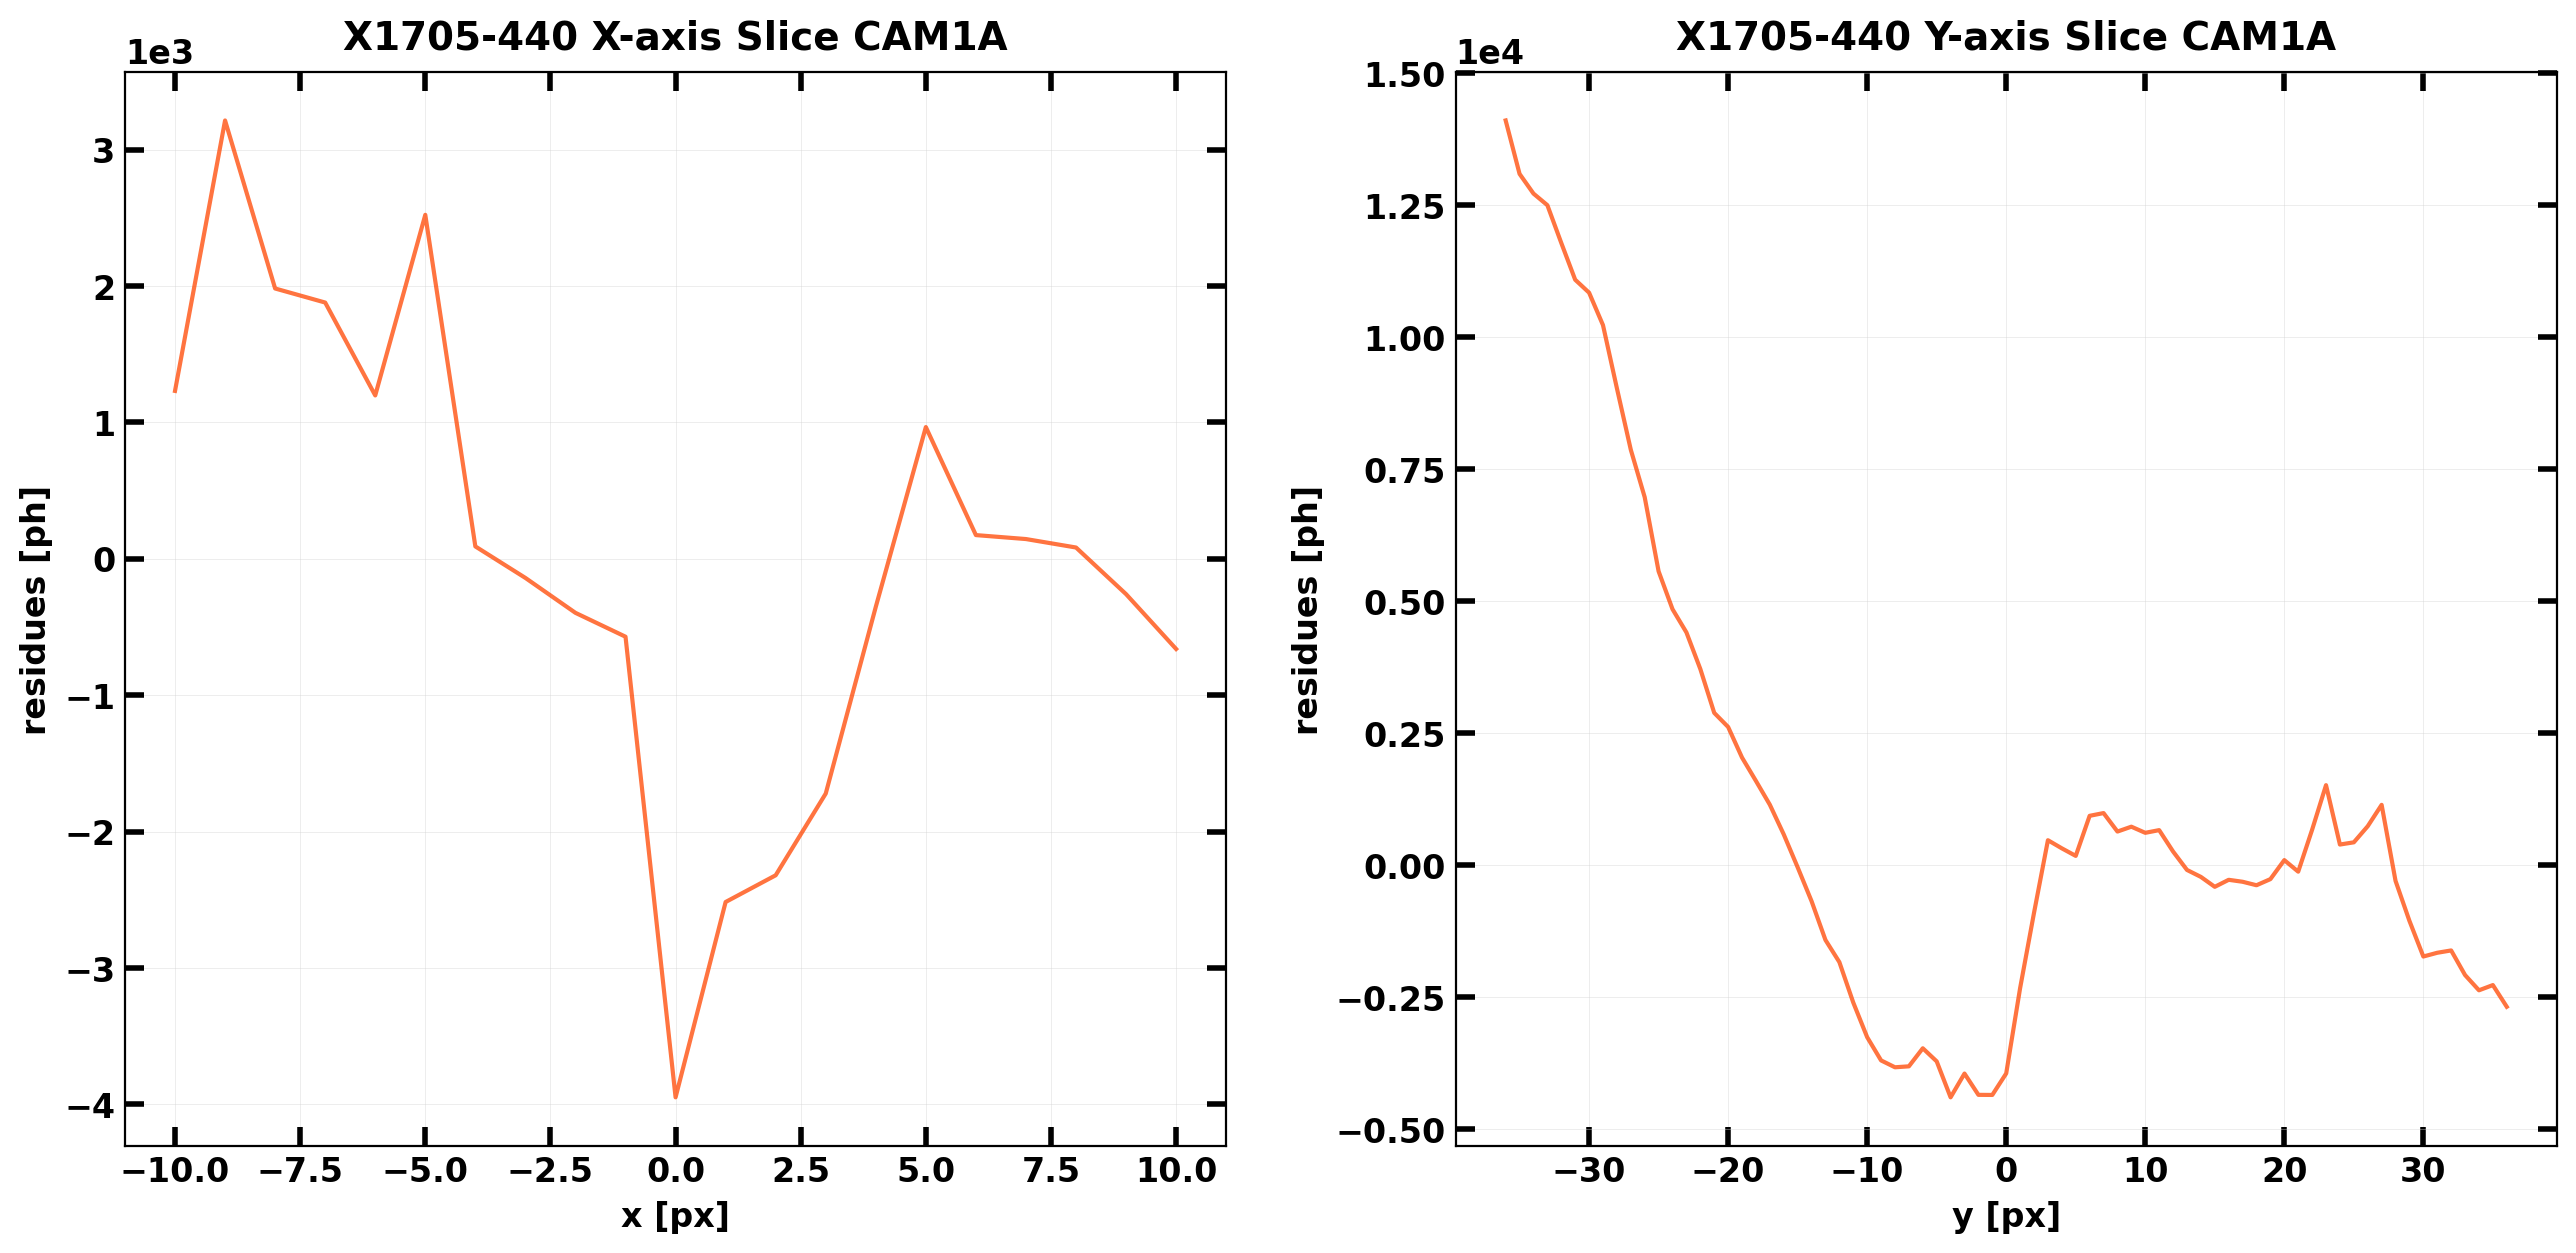

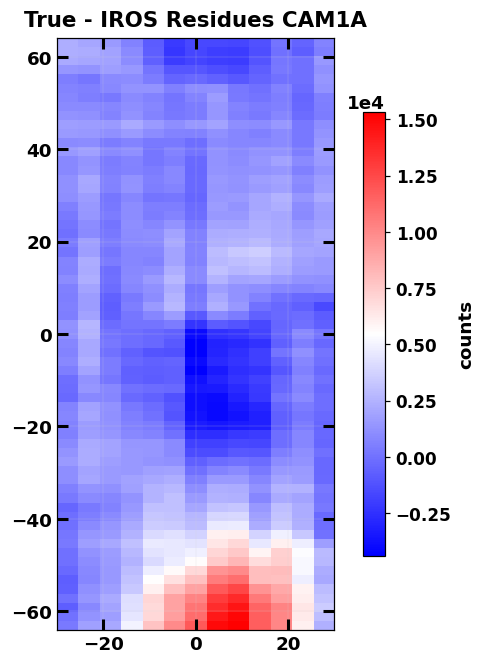

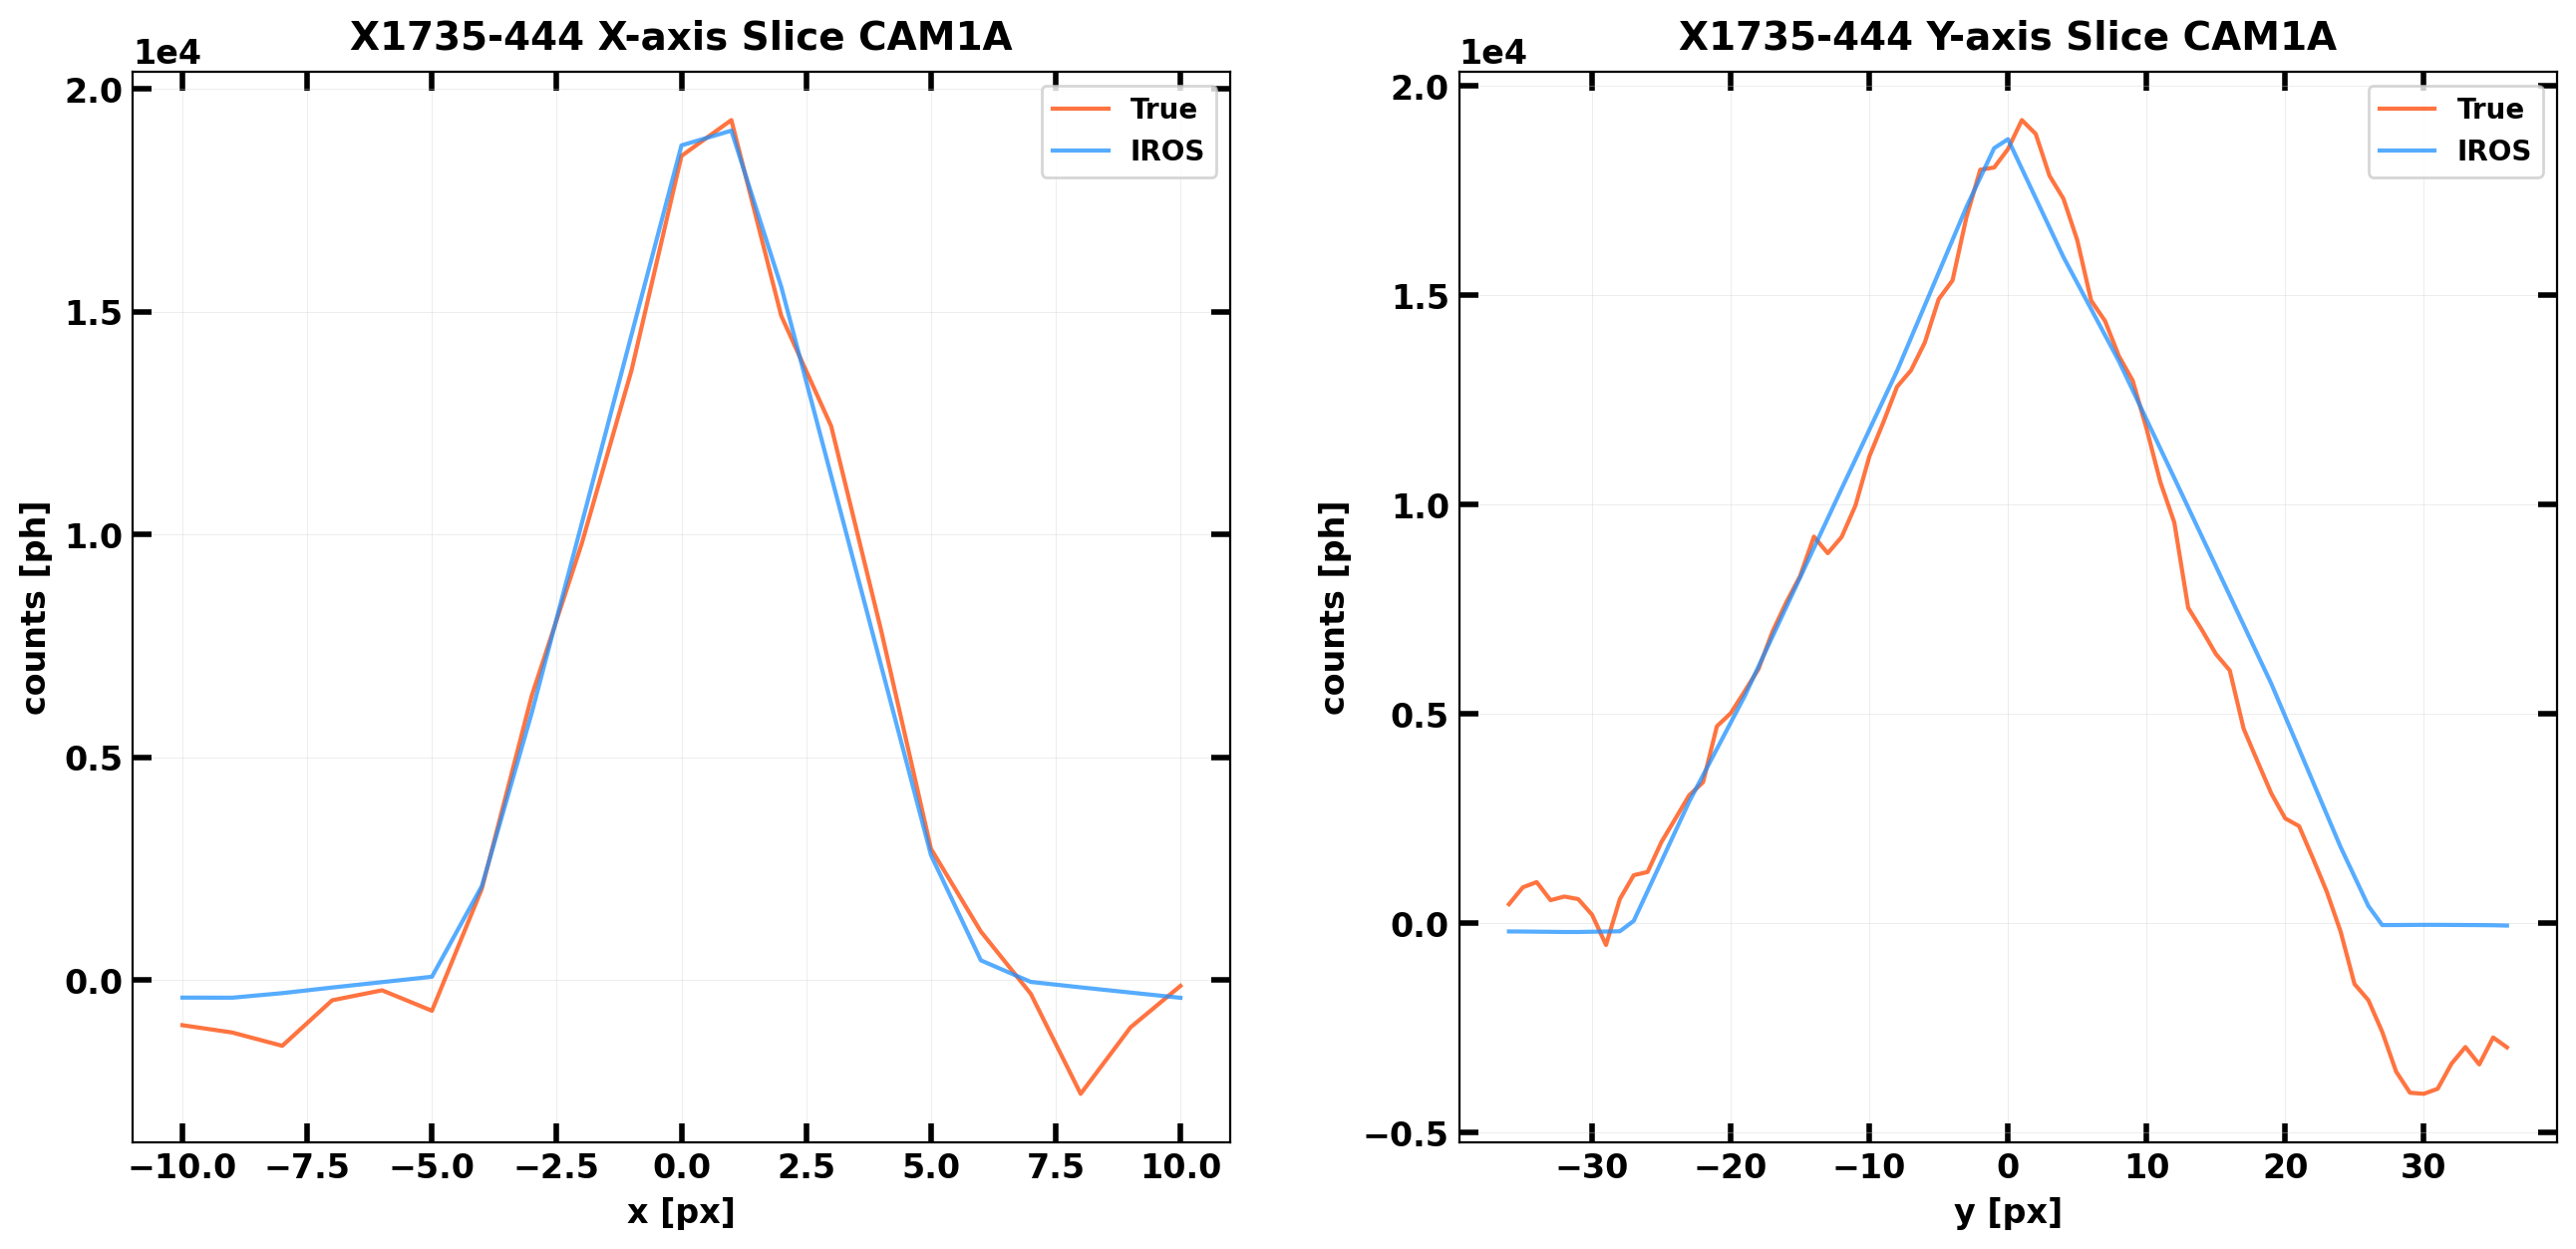

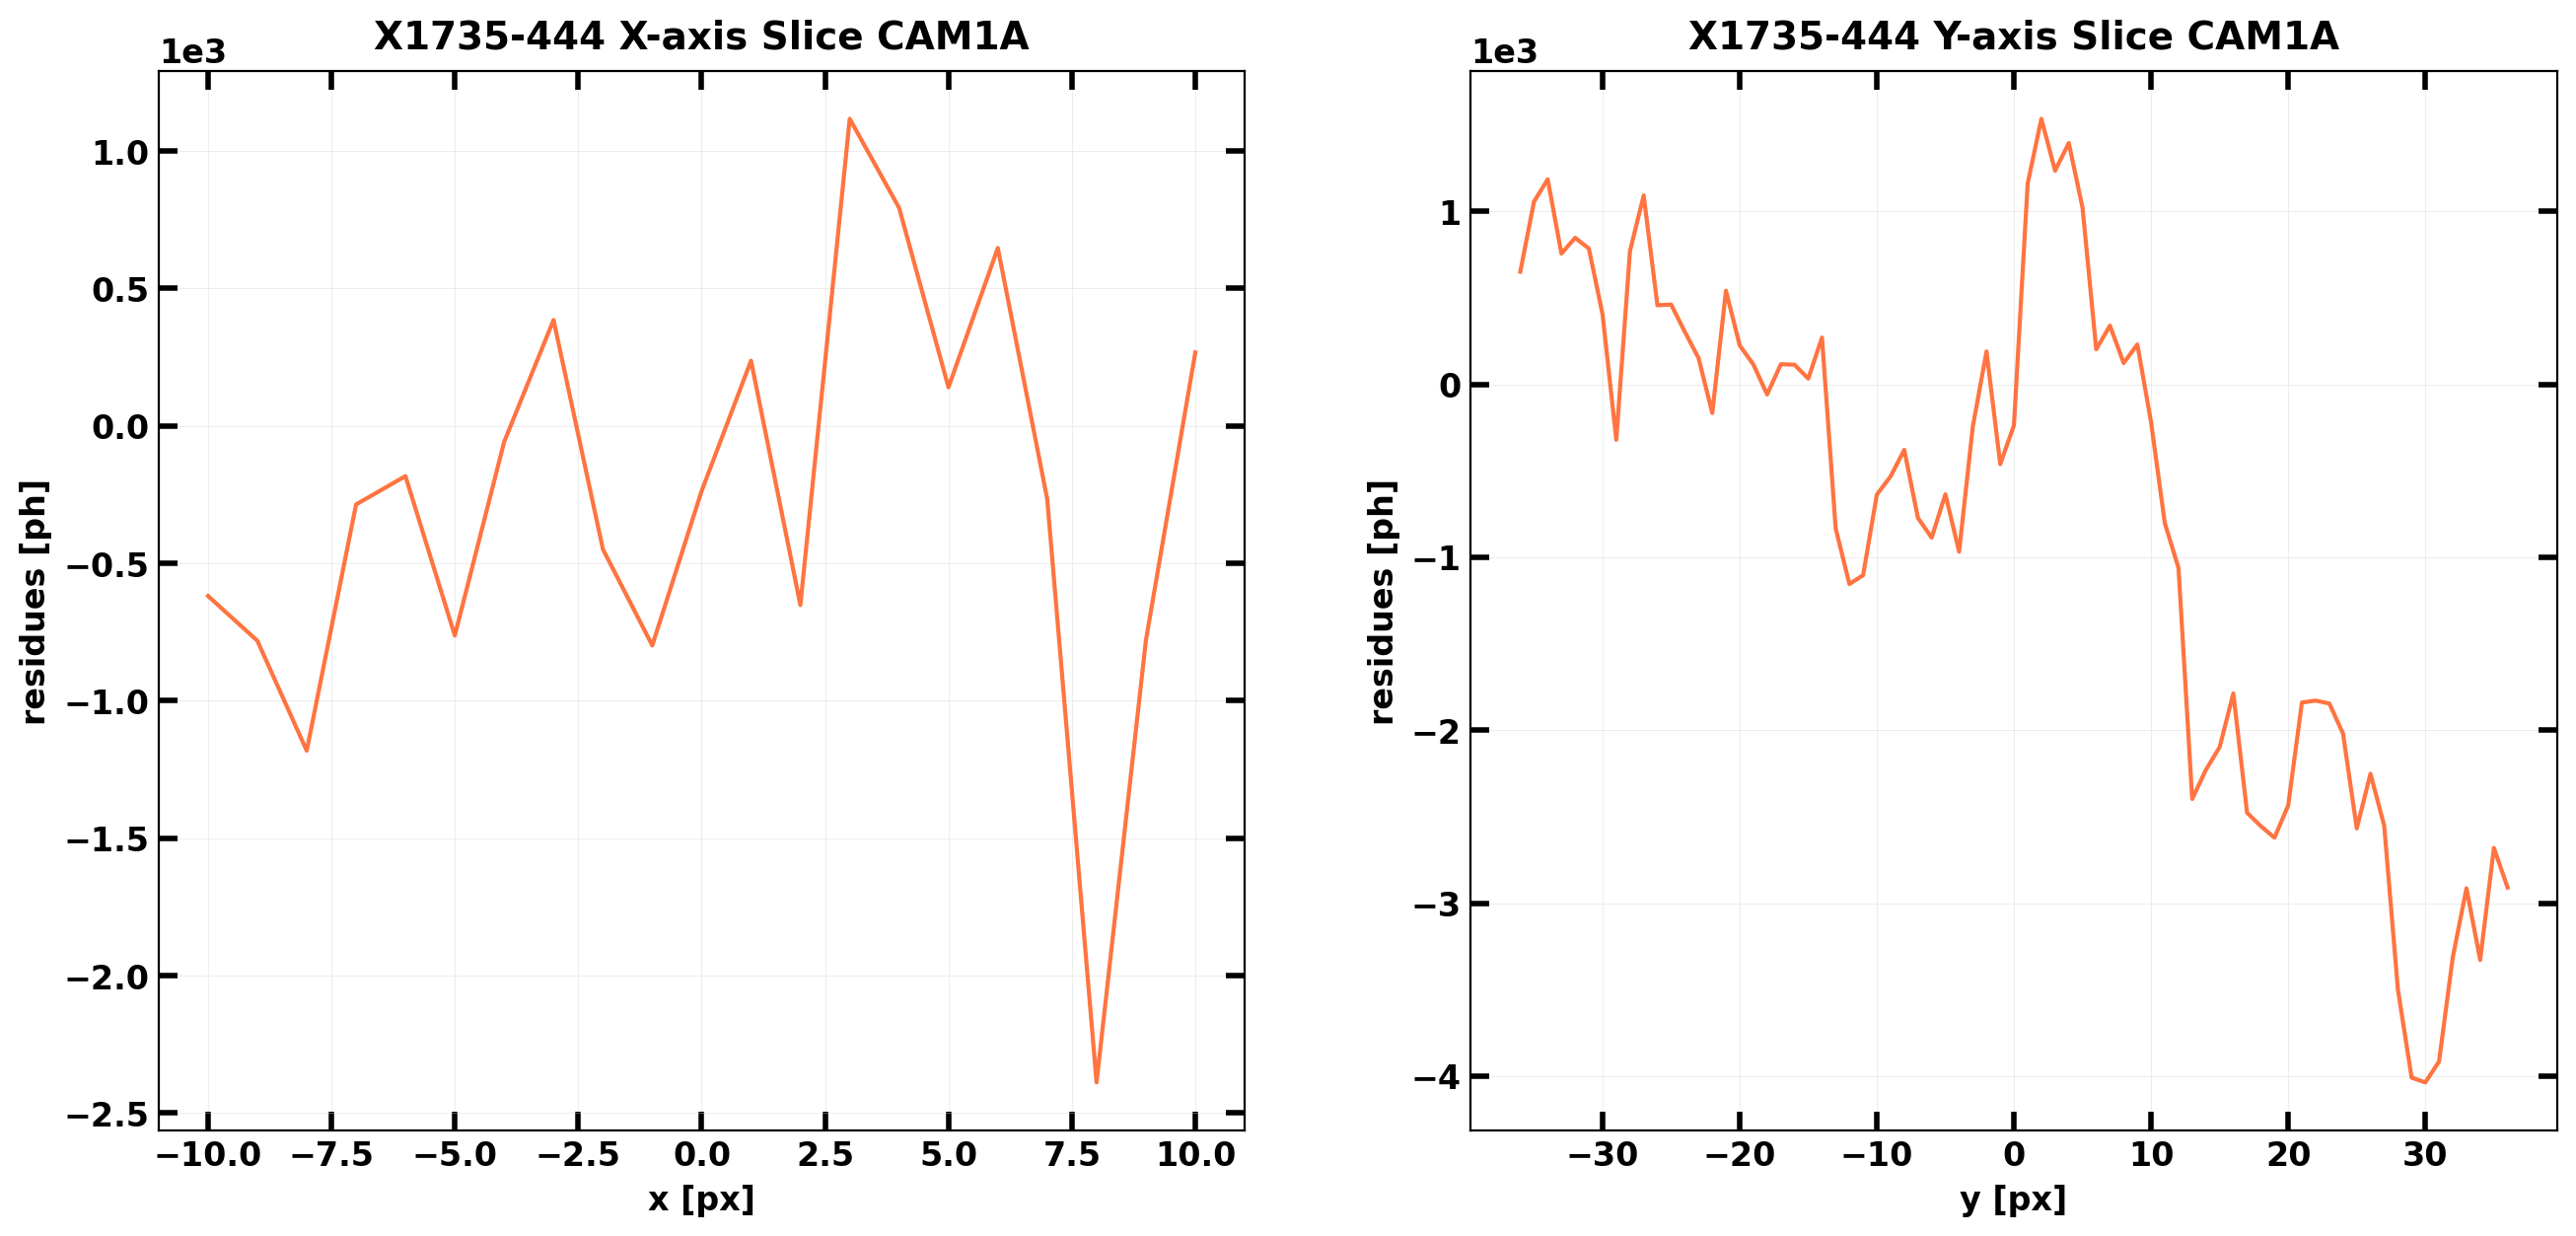

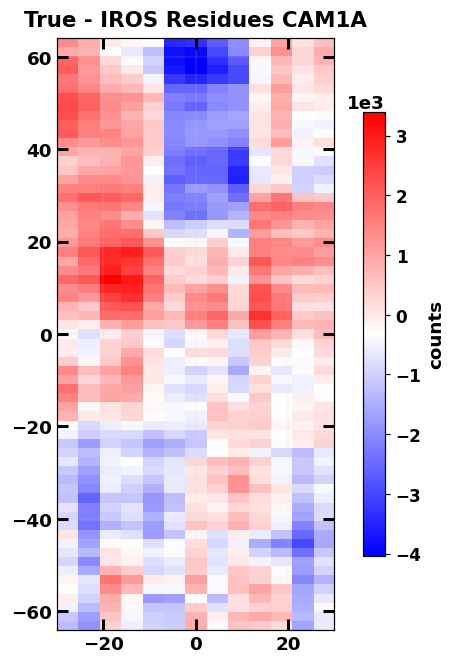

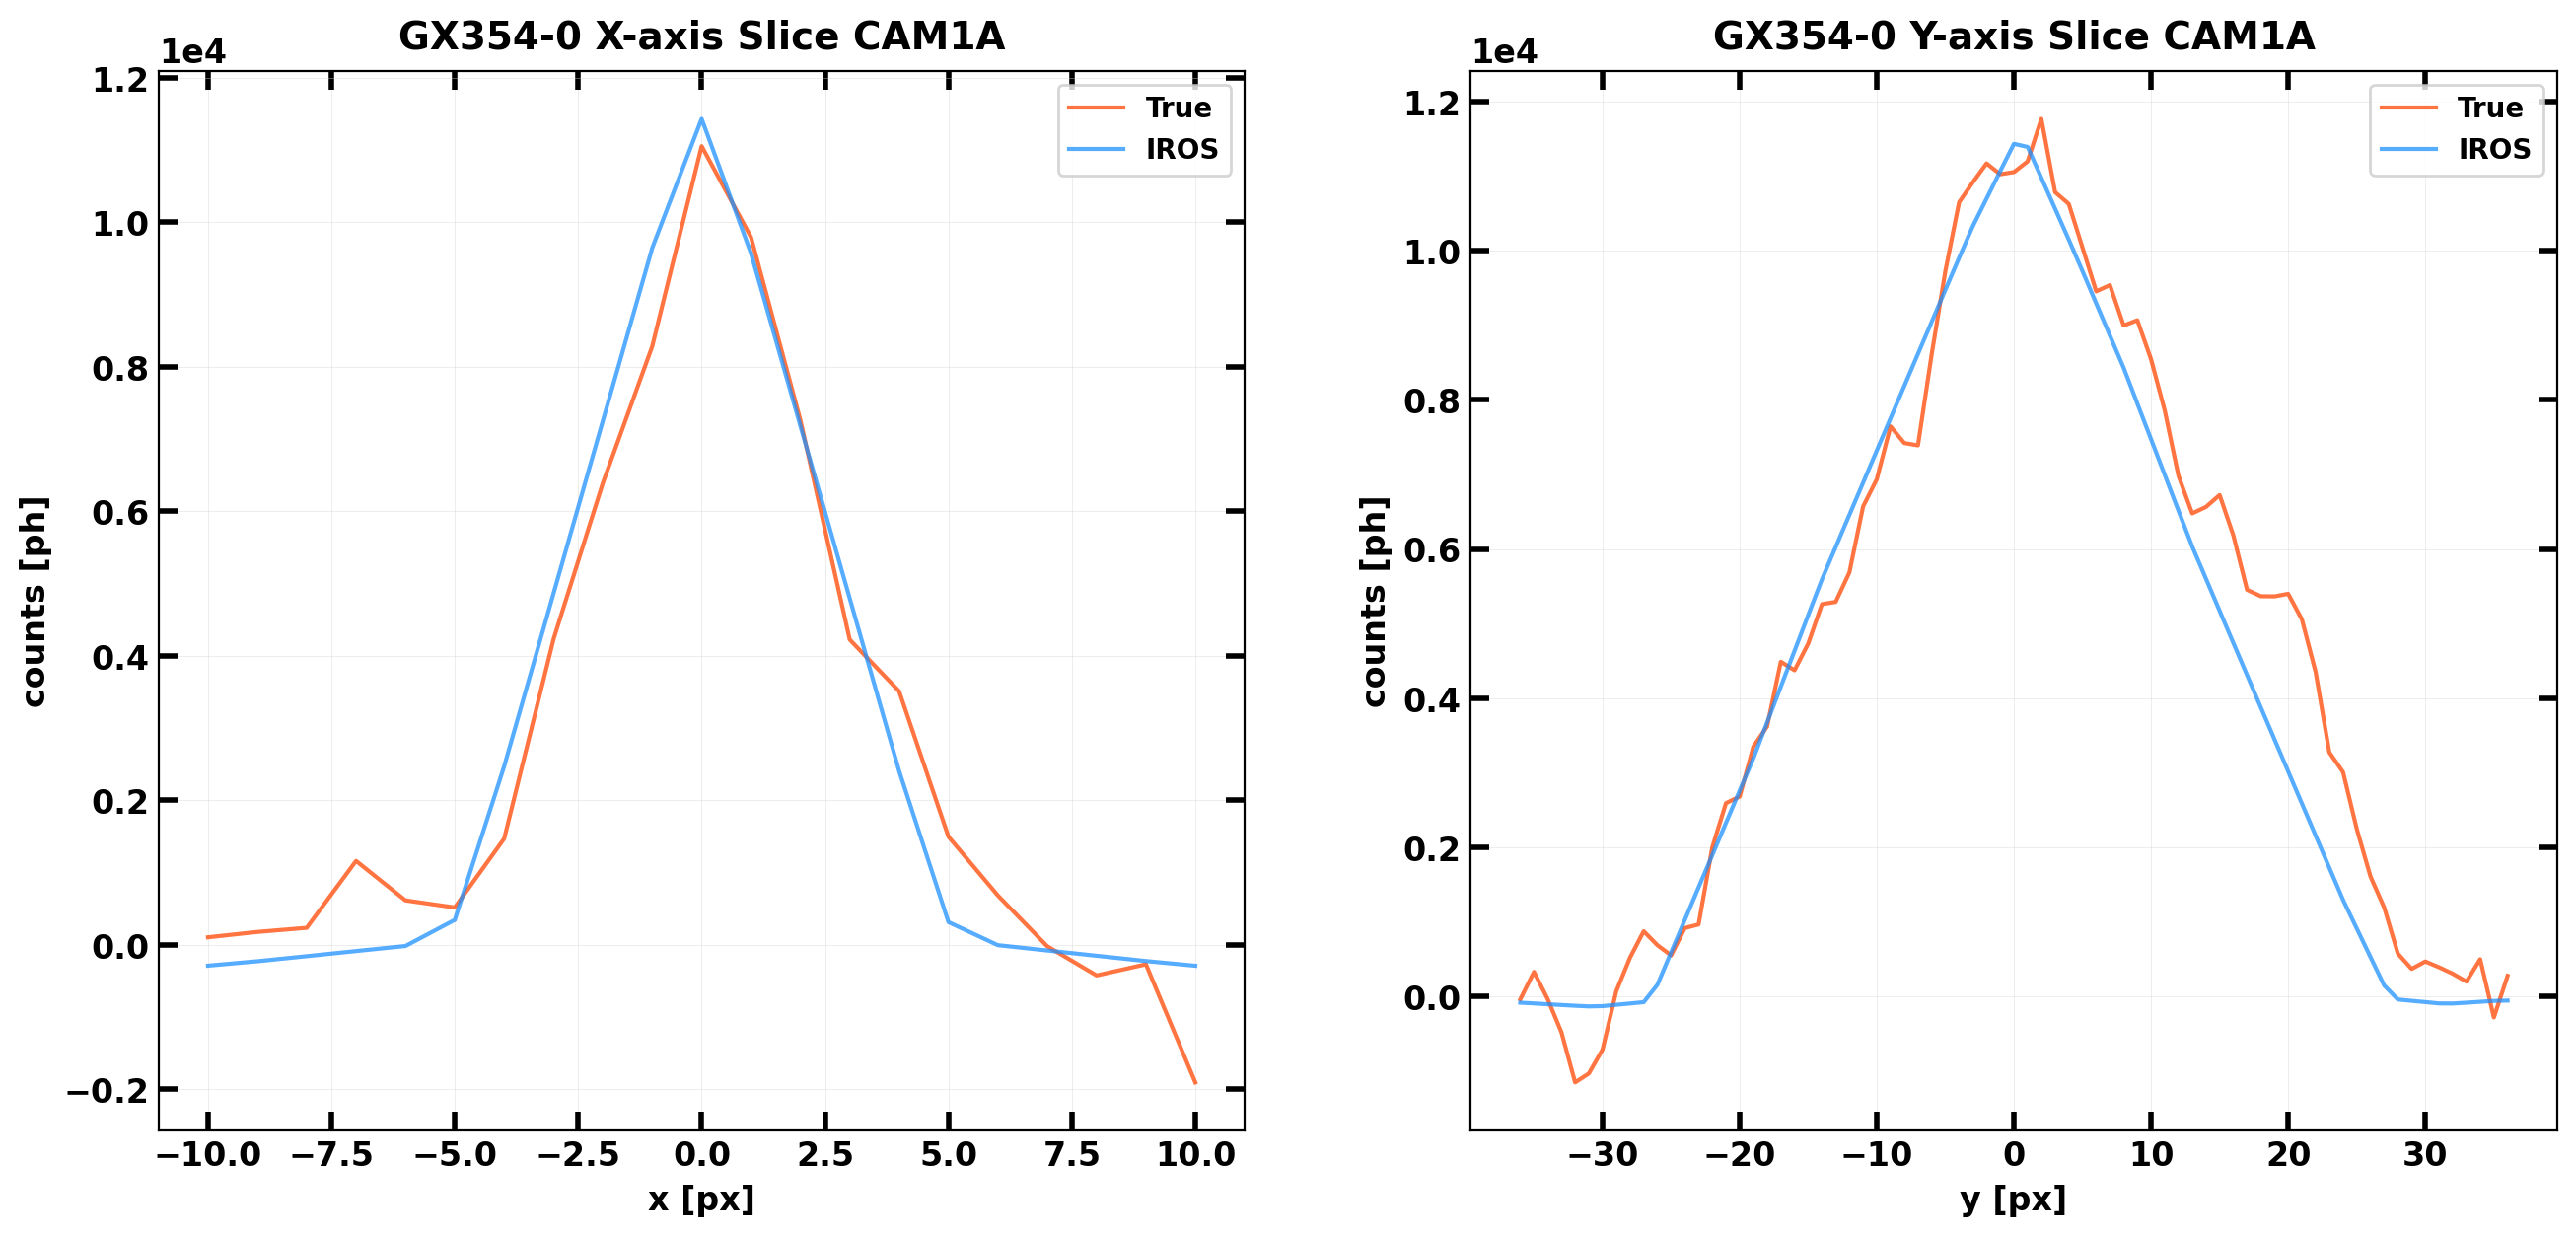

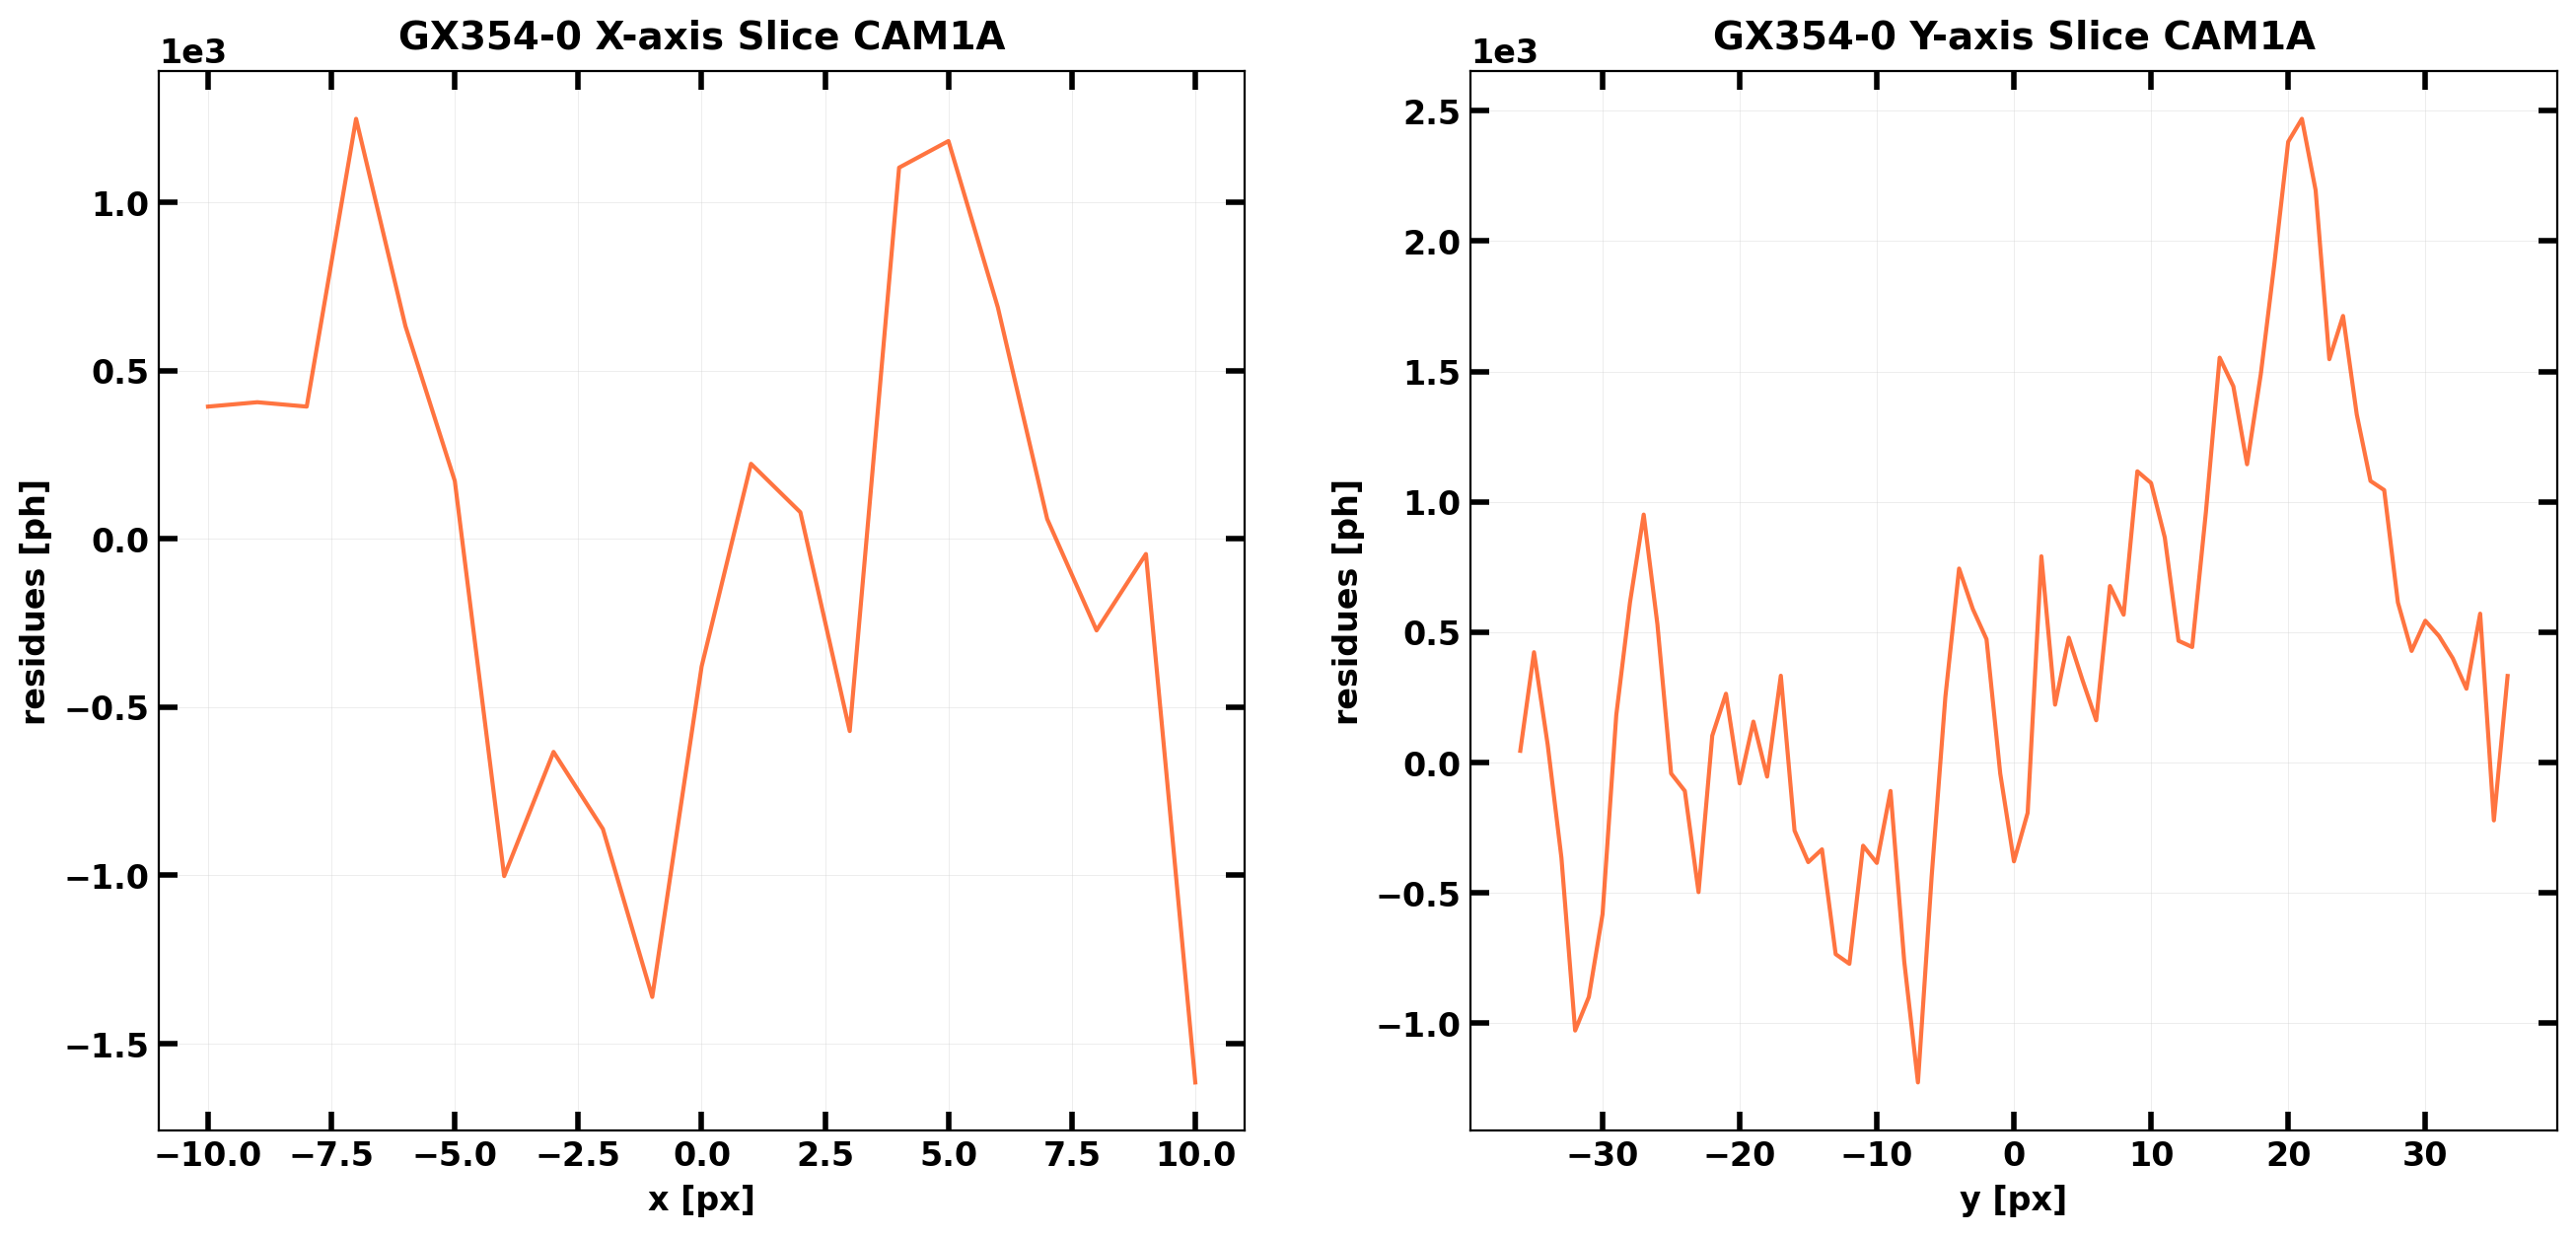

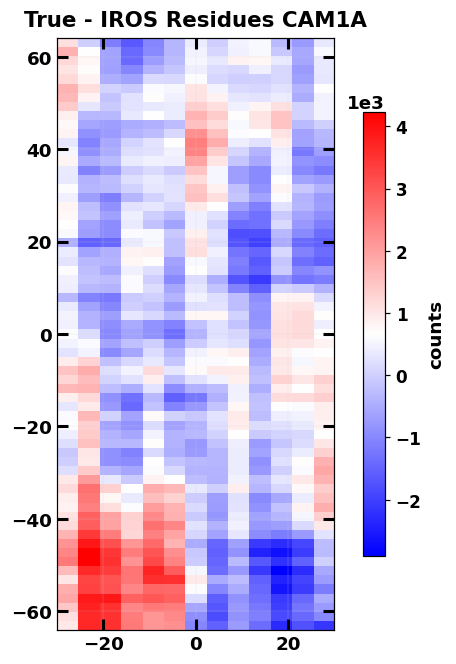

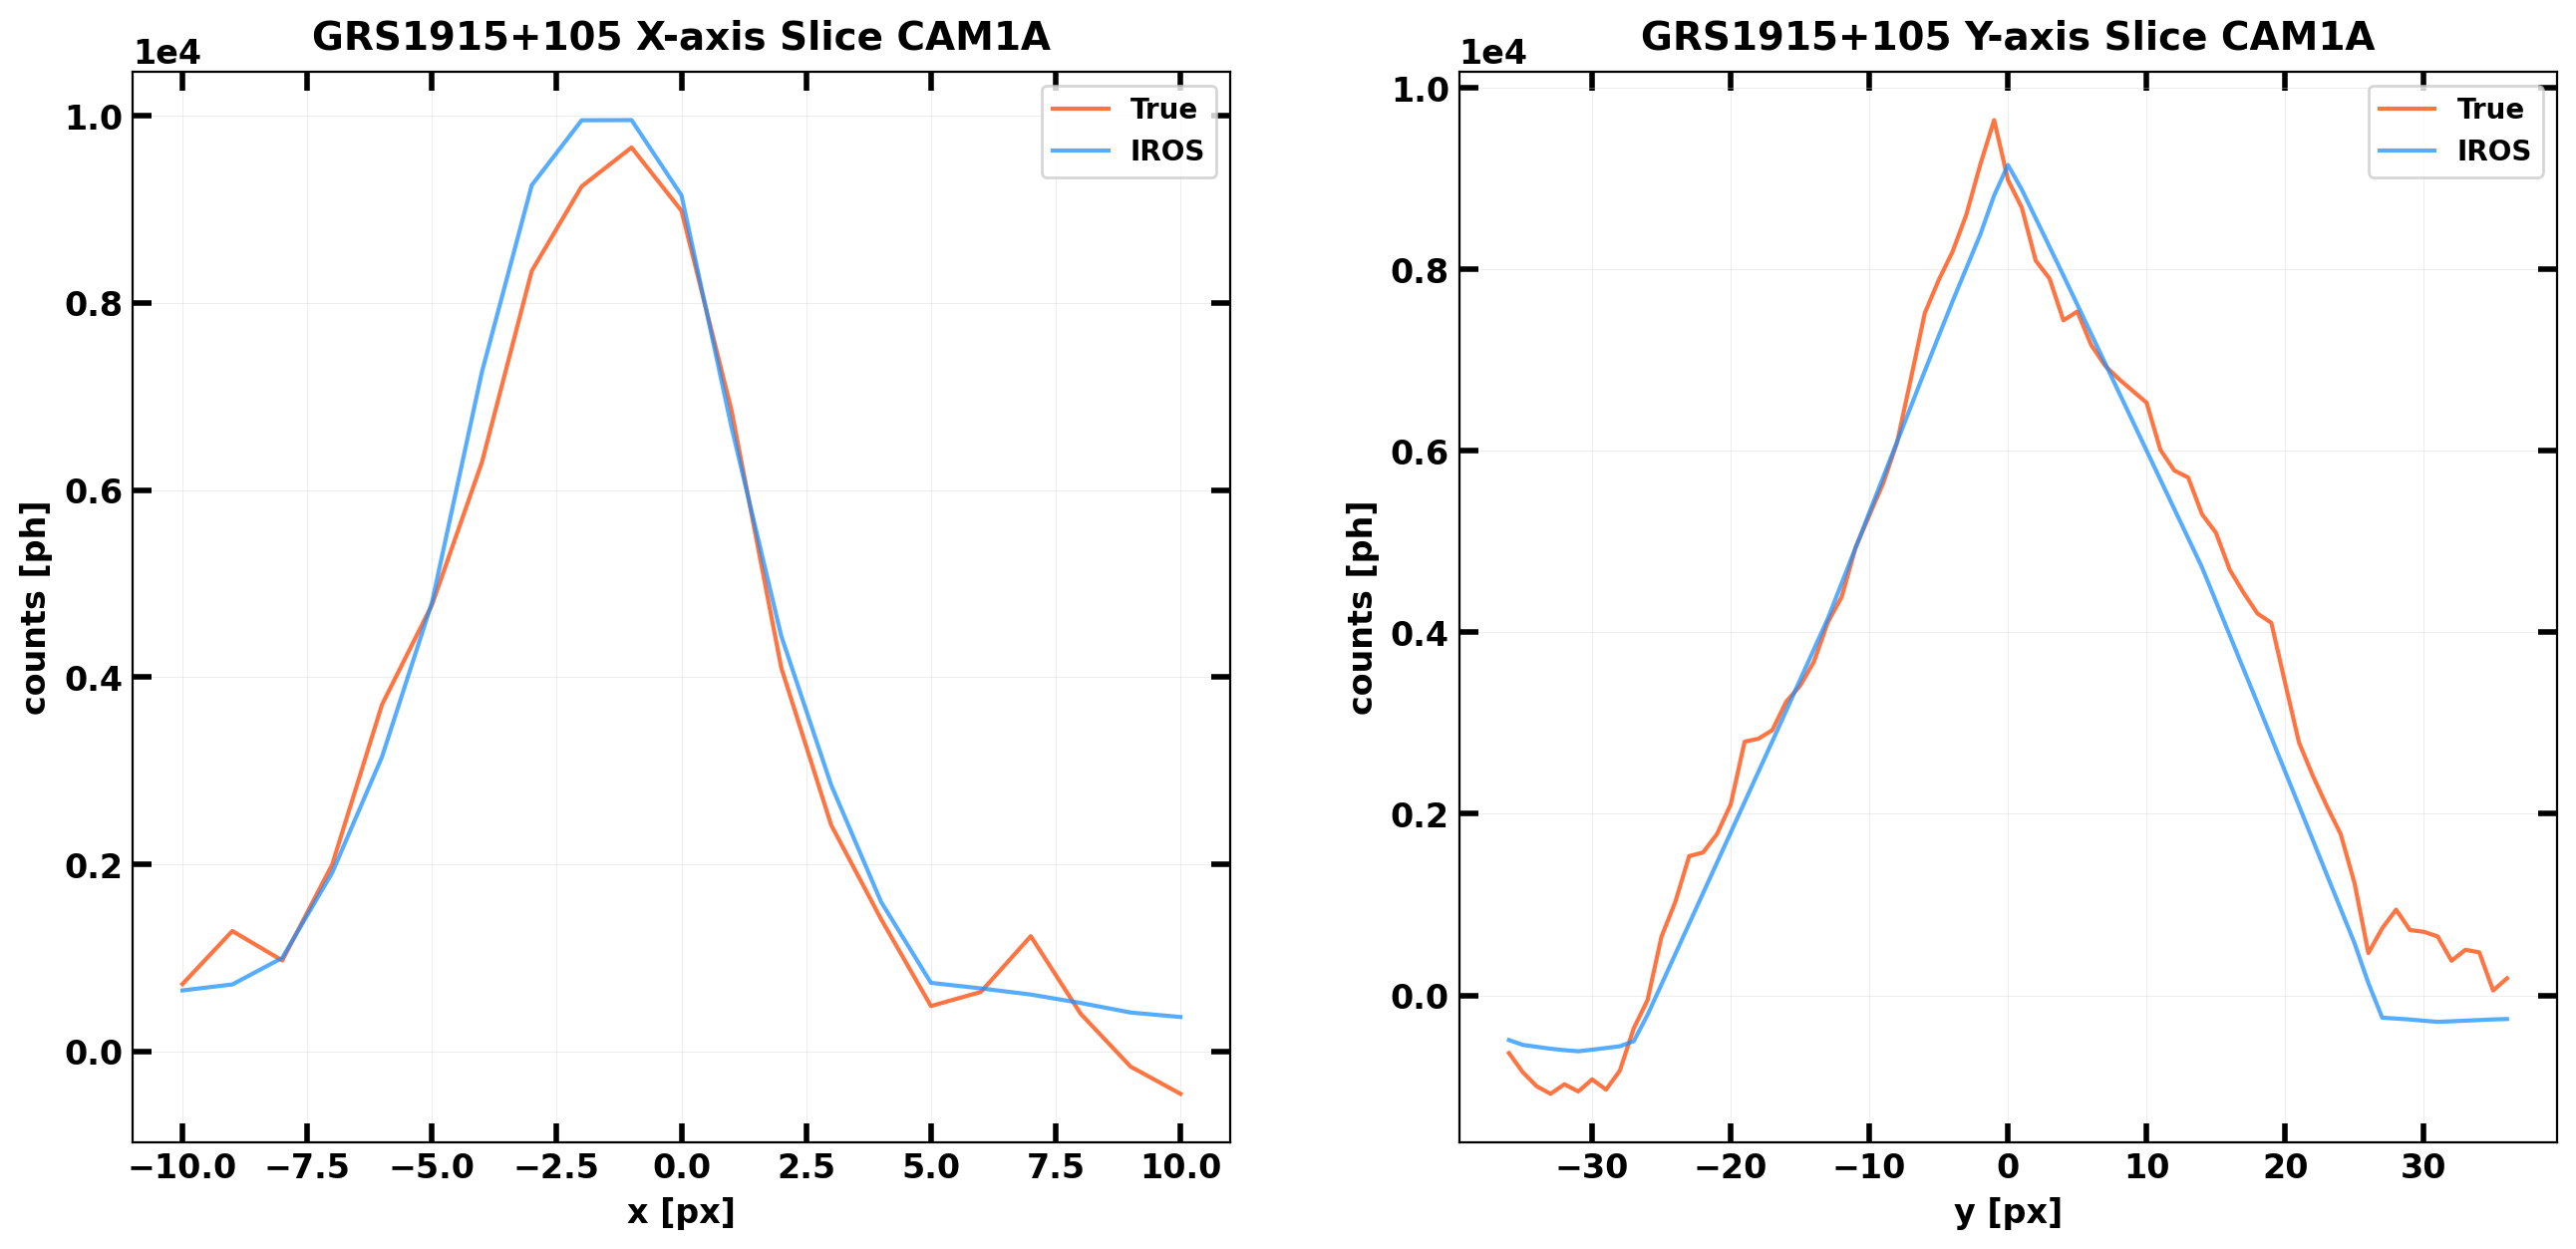

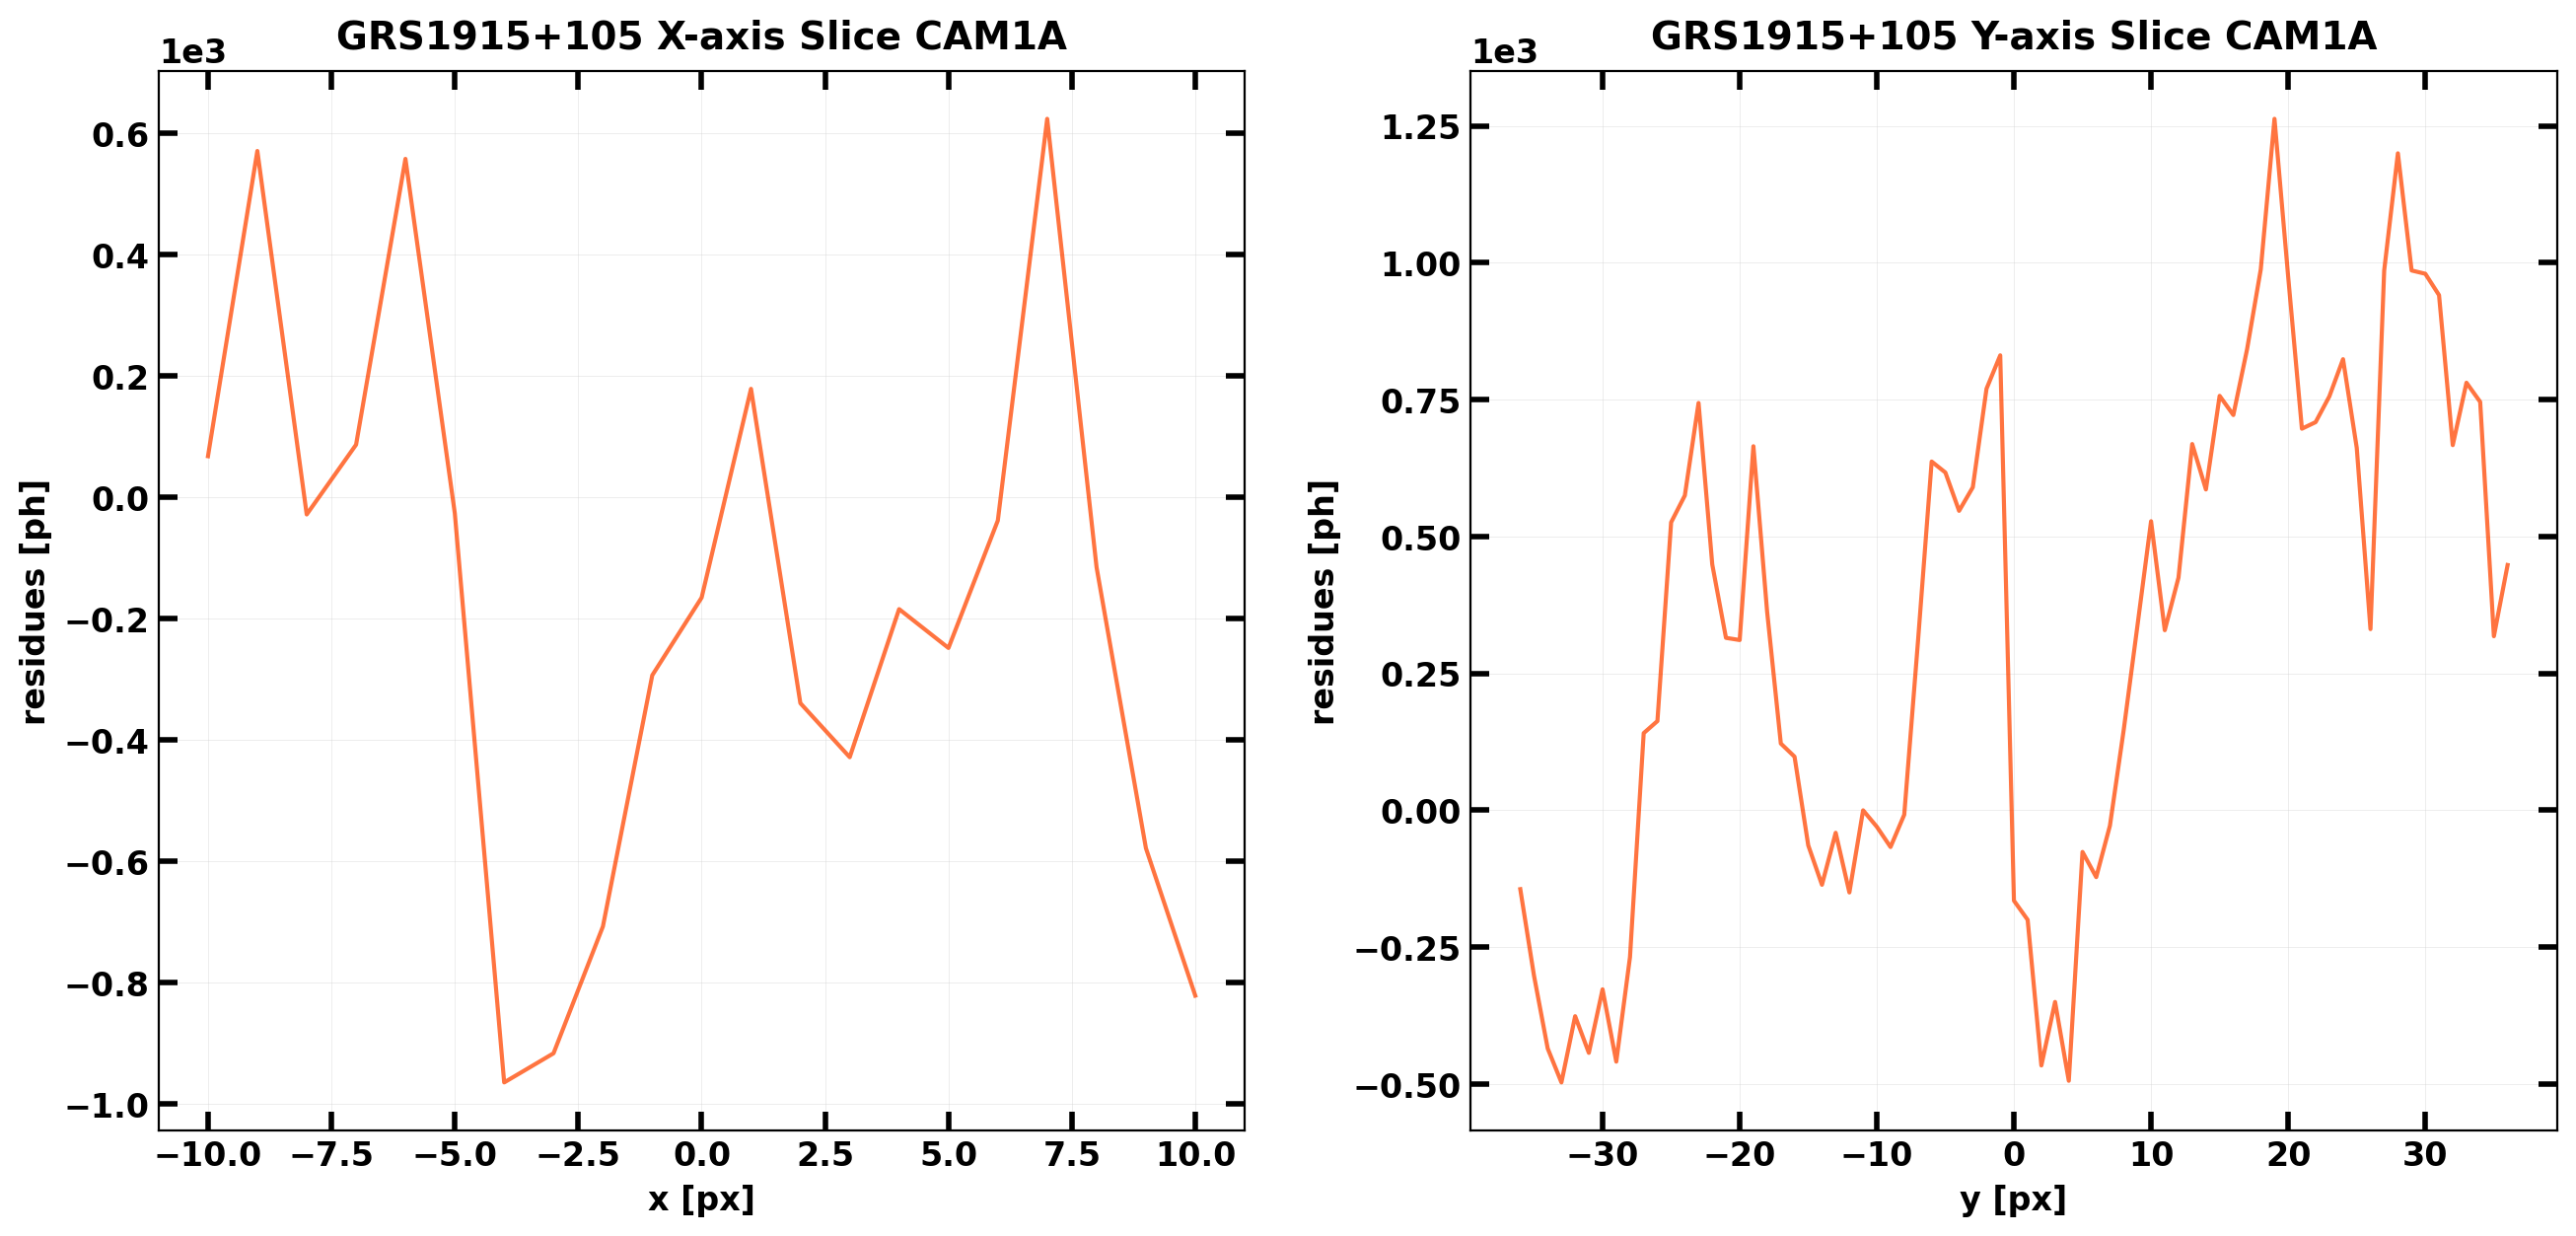

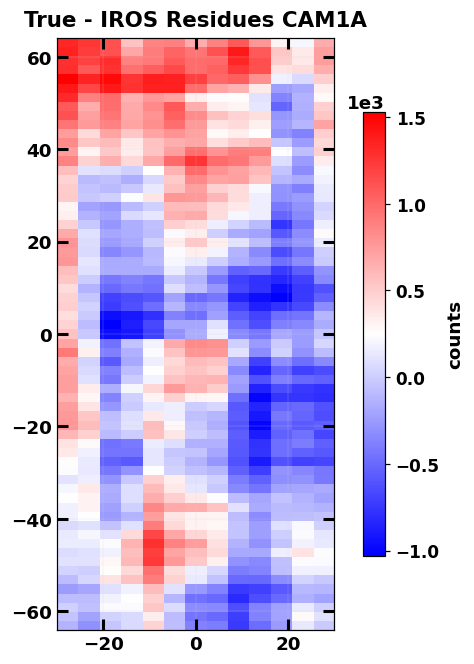

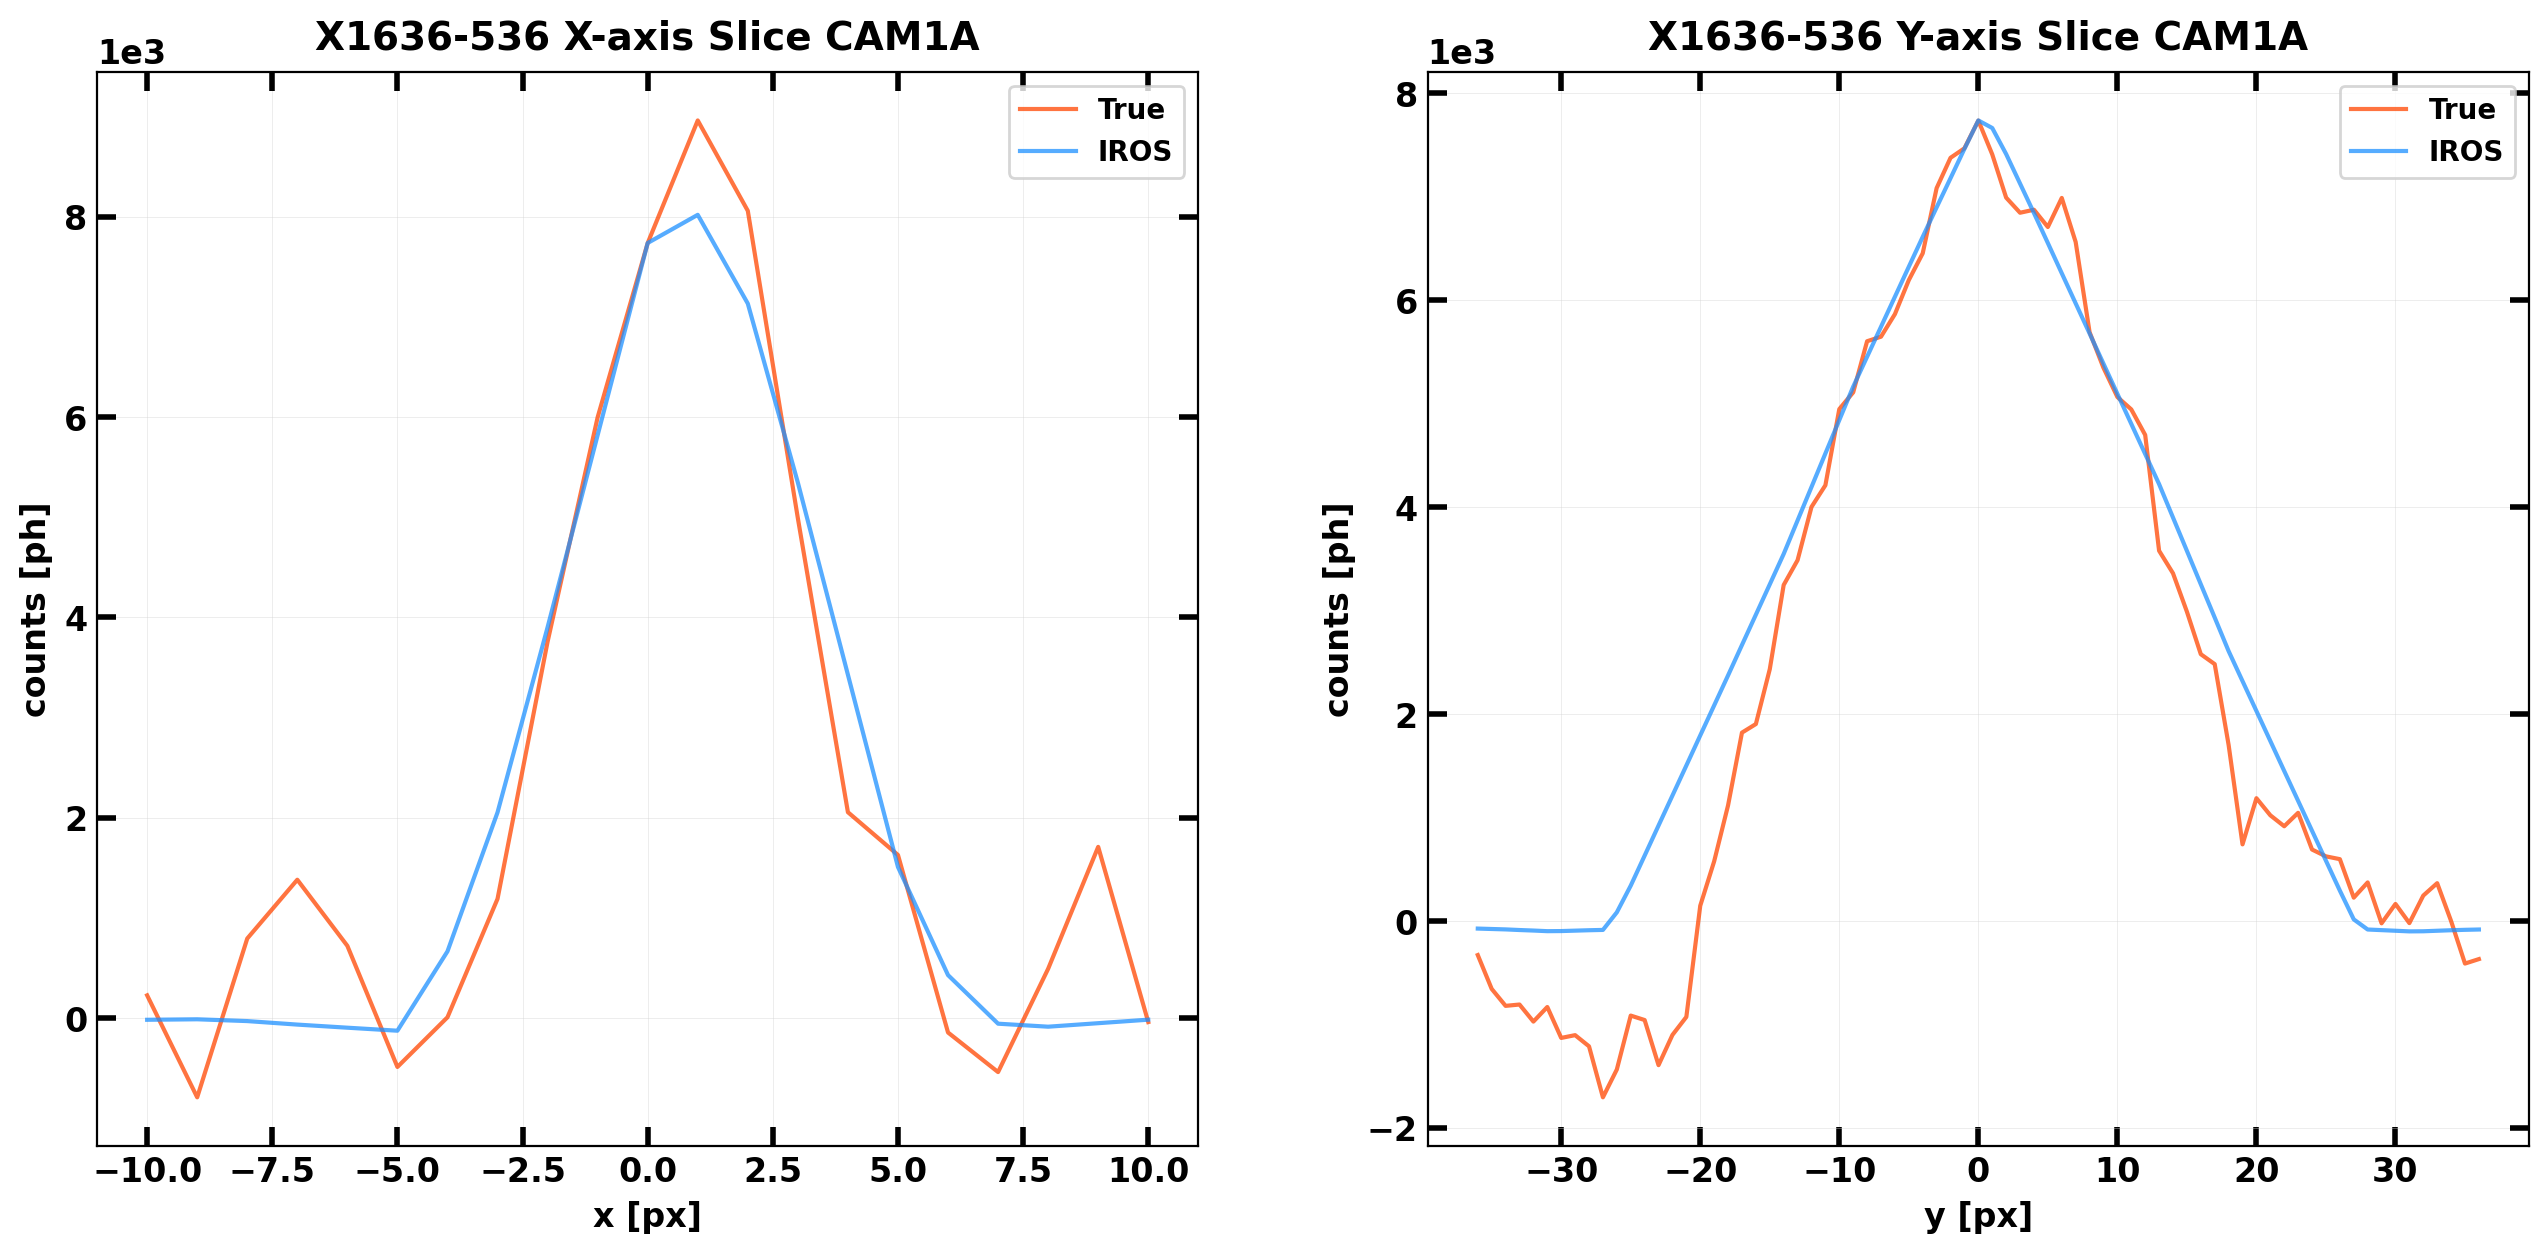

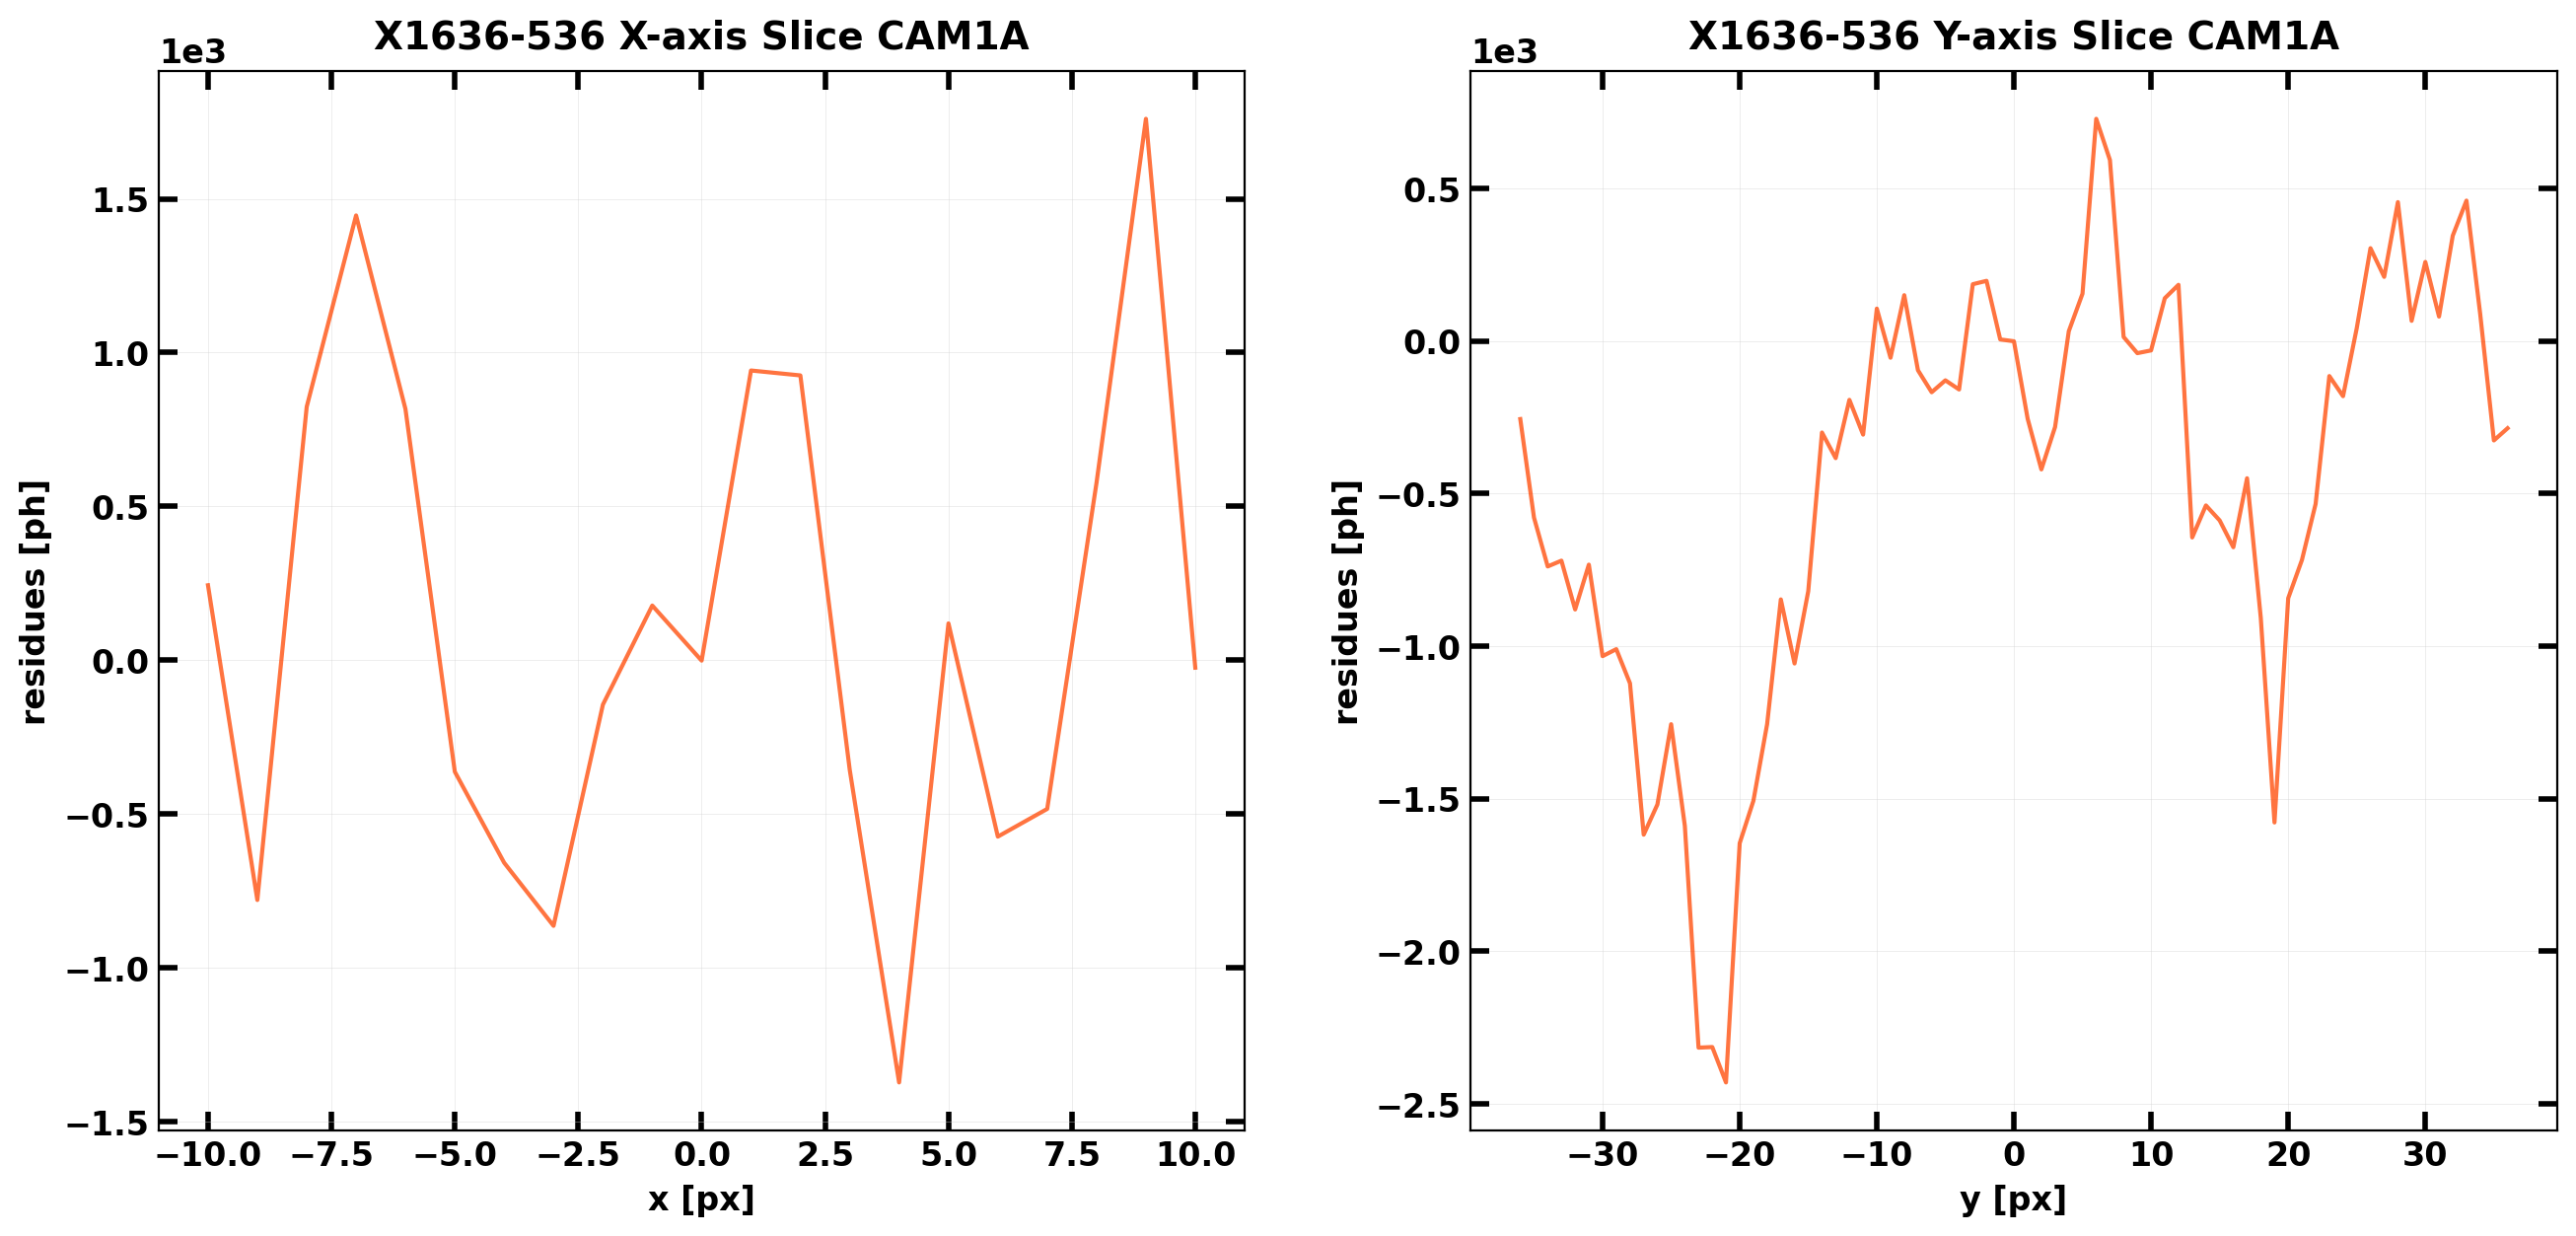

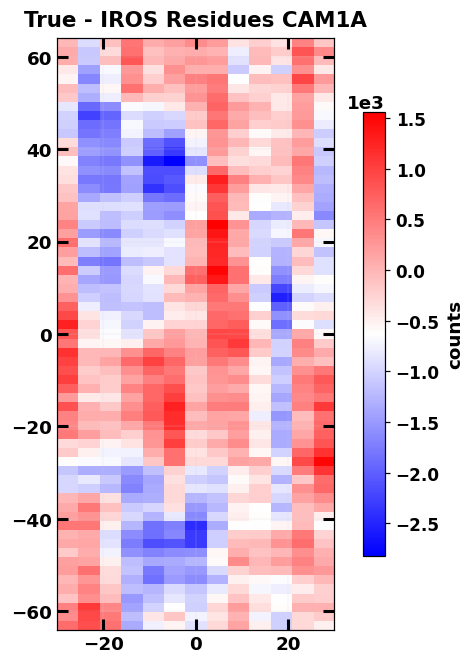

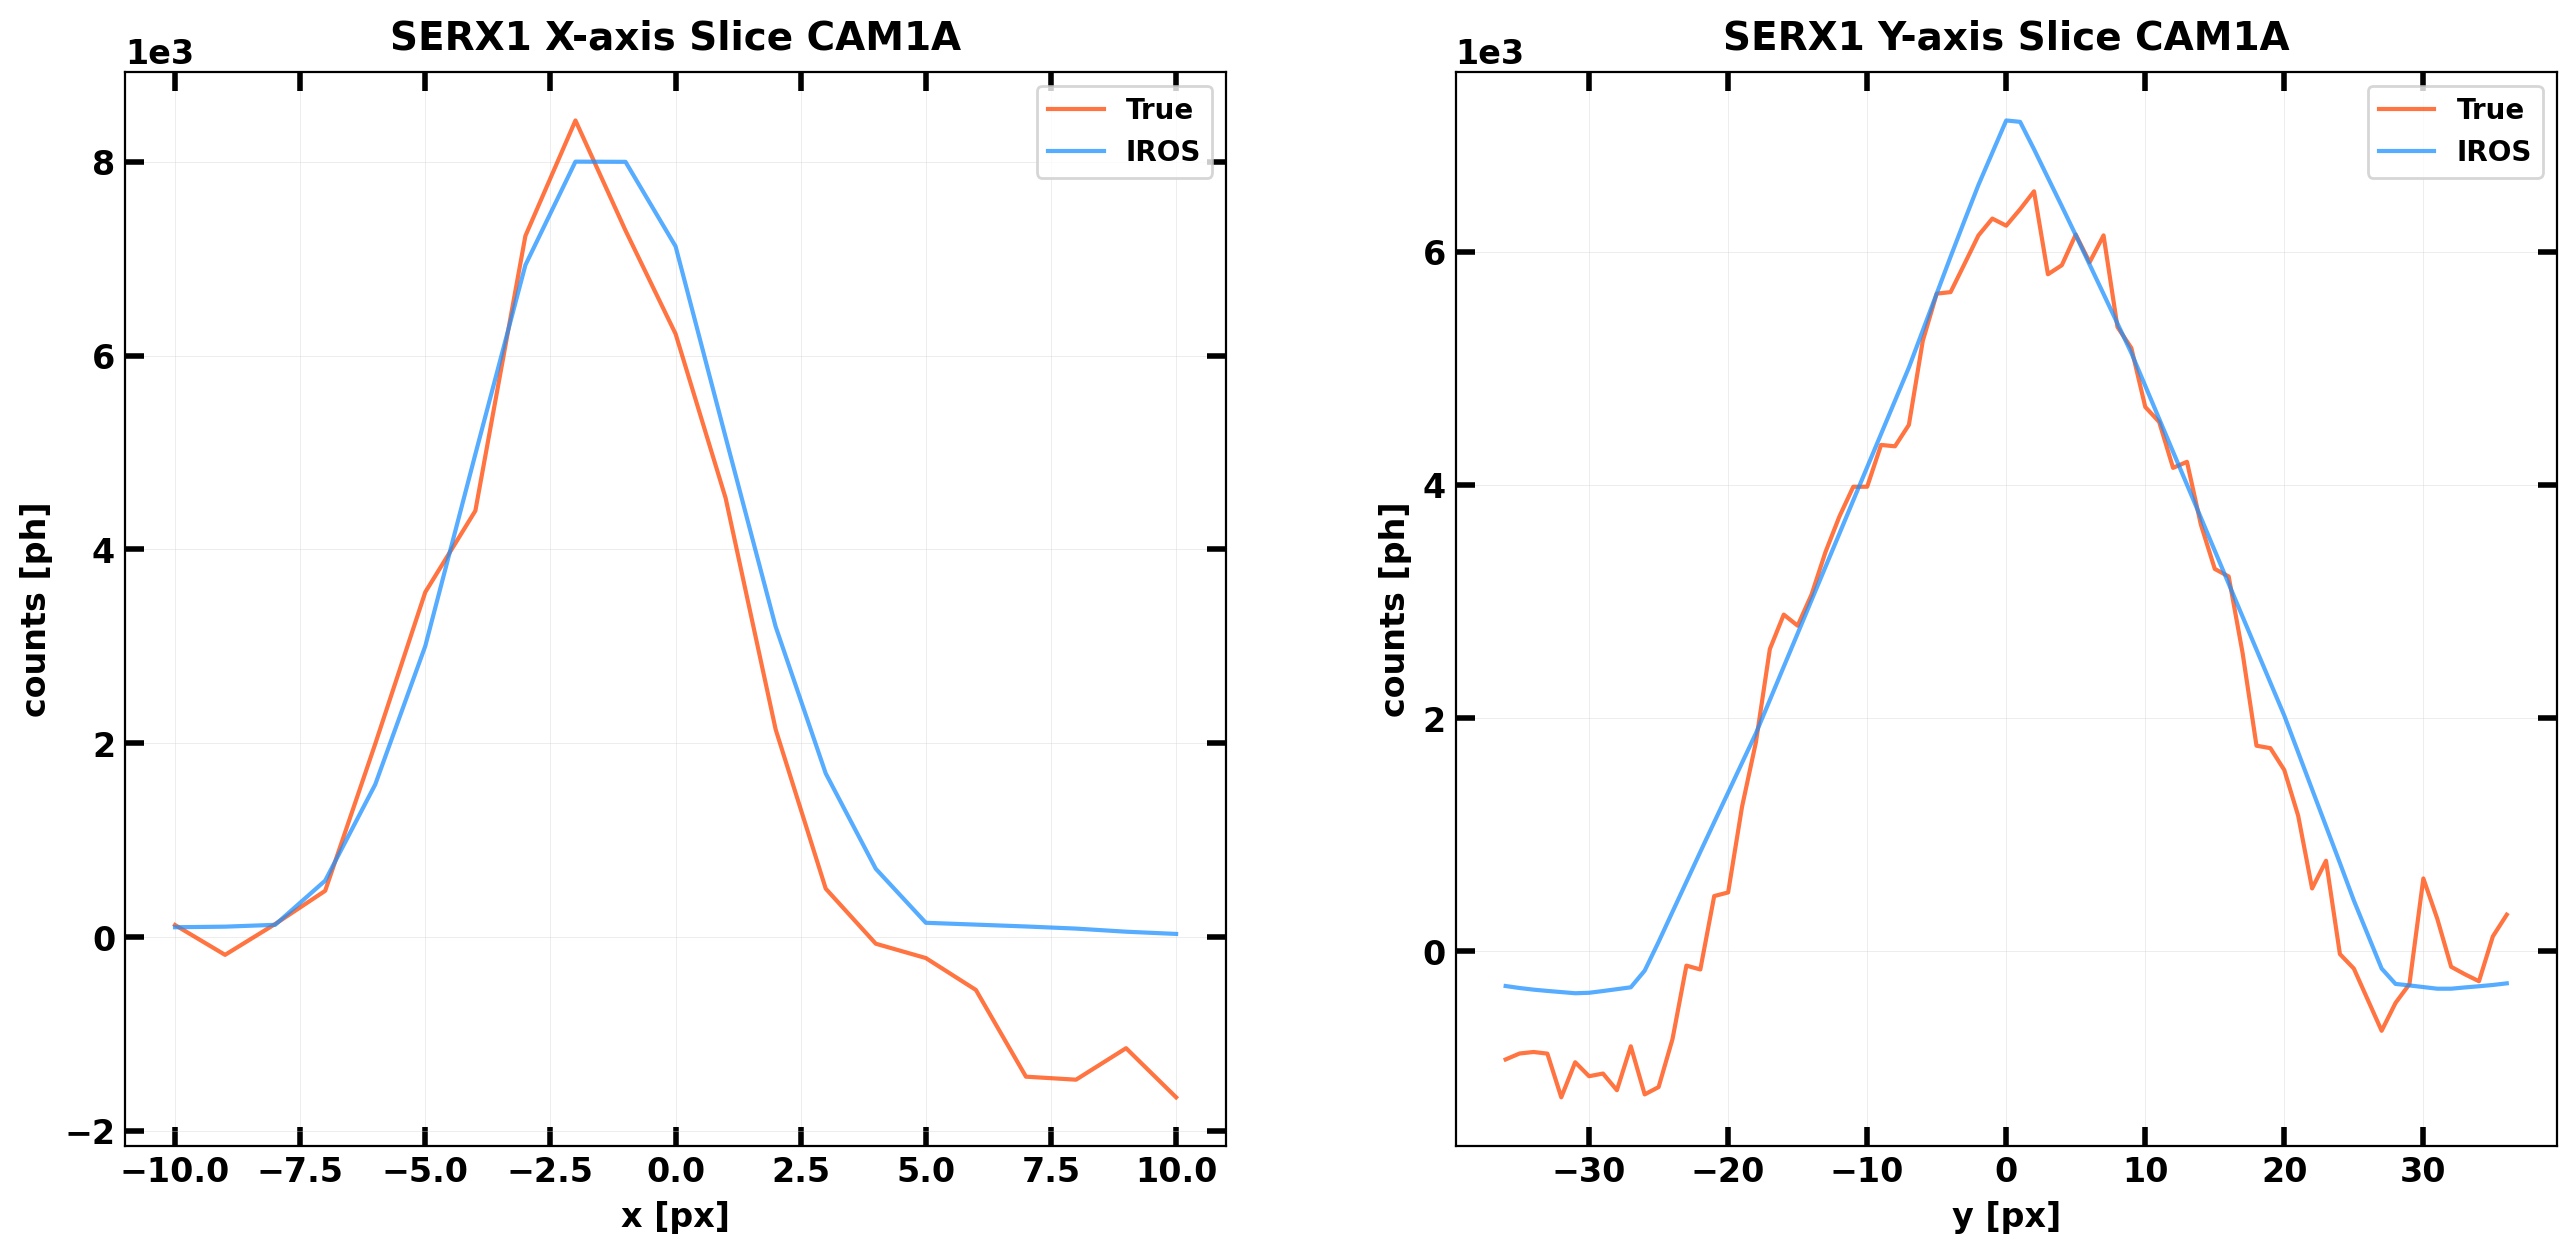

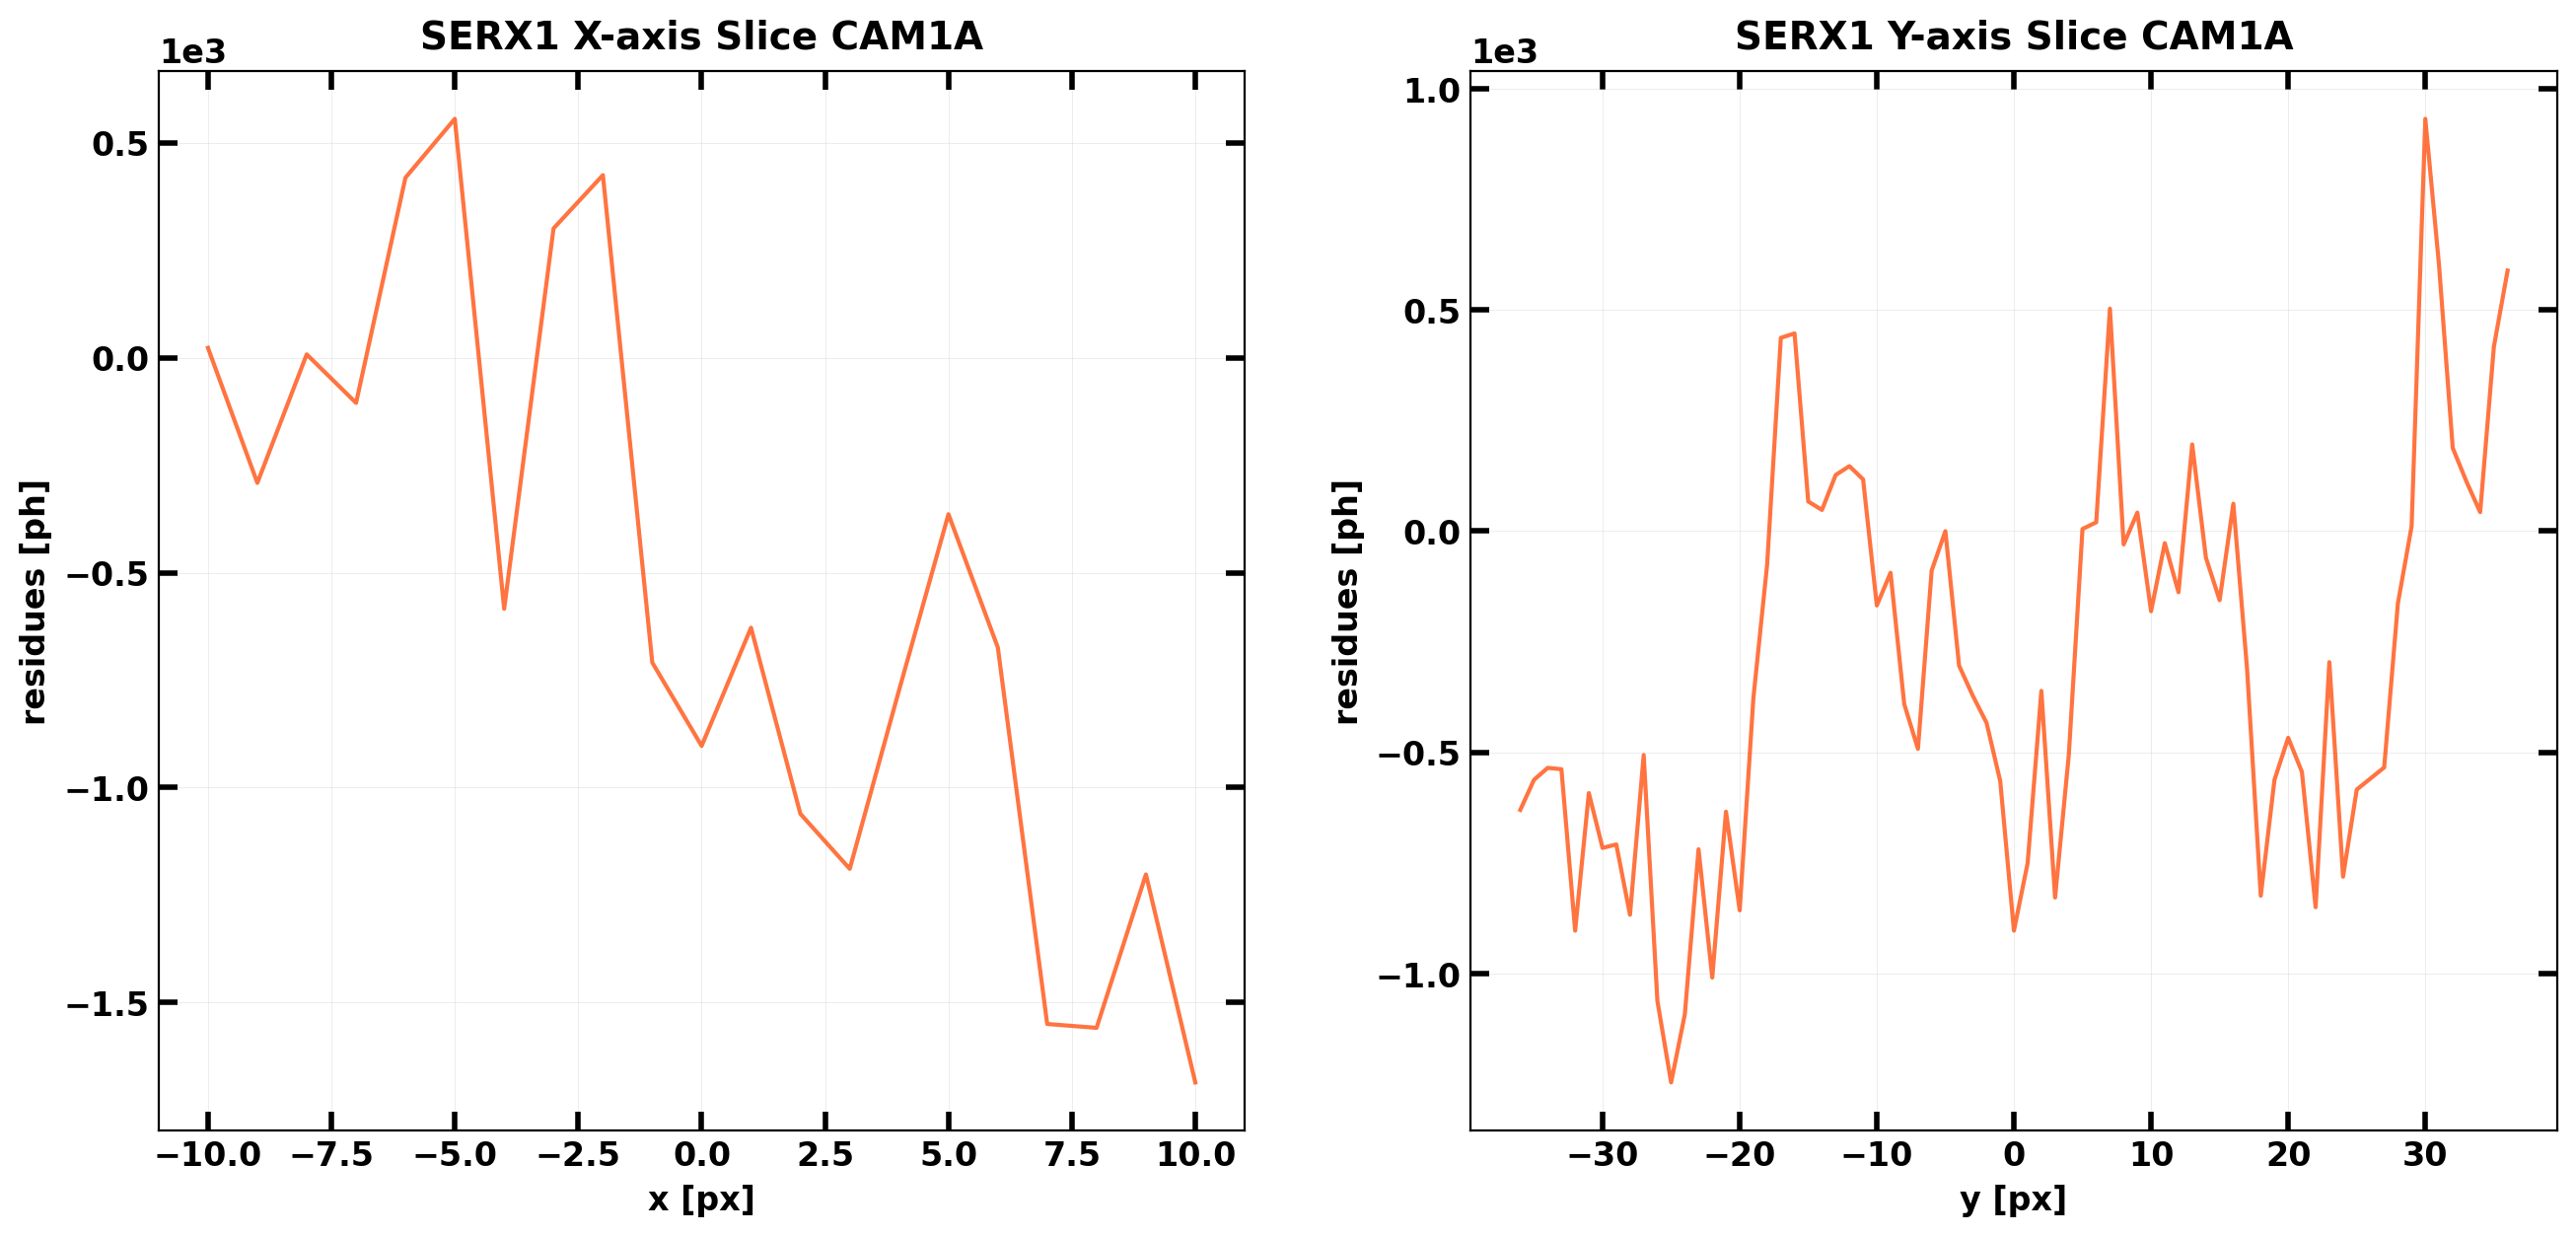

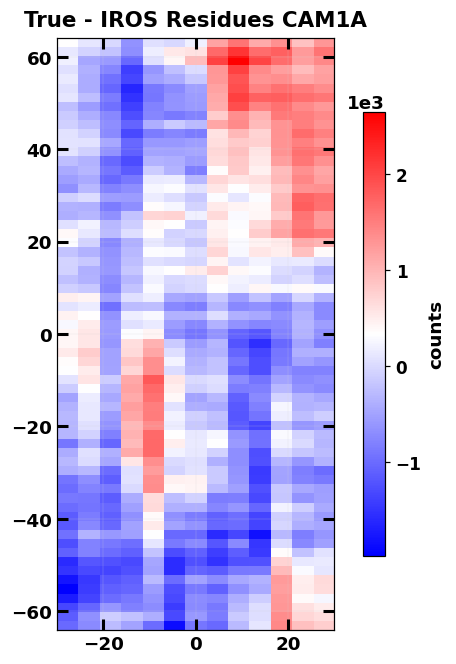

In [7]:
cropx, cropy = (
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
)
ds.reconstruction_plot(
    true_sky=simul_sky_camA,
    log=log_camA,
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
    savepath=is_img,
)